<p align="right">
    <img src="Zewail-City.png">
</p>


---

# __Nuclear Data Analysis__

In [1]:
# Import Main Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

---

## **Project Overview**

### **Dataset Description**
This project analyzes nuclear data from the Deformed Relativistic Hartree-Bogoliubov theory in continuum (DRHBc) calculations for even-Z nuclei. The dataset contains theoretical predictions and experimental measurements for nuclear properties.

**Key Features:**
- **Nuclear Identifiers**: Z (proton number), N (neutron number), A (mass number)
- **Binding Energies**: Eb_exp (experimental), Eb_cal (calculated), Ebrot_cal (with rotational correction)
- **Charge Radii**: Rch_exp (experimental), Rch_cal (calculated)
- **Matter Radii**: Rn (neutron), Rp (proton), Rm (matter)
- **Deformation Parameters**: β_n, β_p, β_t (quadrupole deformations)
- **Fermi Energies**: λ_n (neutron), λ_p (proton)
- **Separation Energies**: Sn (one-neutron), S2n (two-neutron), S2p (two-proton)
- **Quantum Numbers**: m^π(N) (angular momentum and parity)

**Dataset Statistics:**
- Total nuclei: 5,437 even-Z isotopes
- Missing data: Eb_exp (4,173), Rch_exp (4,124), Sn (35), S2n (81), S2p (49)

---

## **Analysis Workflow**

### **A. Data Understanding & Exploration**
- Loaded and inspected the DRHBc dataset for even-Z nuclei (5,437 entries).
- Performed descriptive statistics using `df.describe()` to summarize key observables (binding energies, radii, deformations, Fermi levels).
- Visualized distributions of critical variables (Eb_exp, Rch_exp, Sn, β_n, λ_n, m^π(N)) via histograms with KDE to reveal physical trends (e.g., multimodality near shell closures).
- Analyzed correlations through a comprehensive heatmap, identifying strong redundancies (e.g., Eb_cal ≈ Ebrot_cal) and physical relationships (e.g., radii with A^(1/3)).
- Detected outliers using boxplots to identify potential measurement errors or exotic nuclei.
- Identified potentially noisy/irrelevant features: high redundancy in Ebrot_cal and weaker correlations of m^π(N) with bulk properties.

### **B. Data Preprocessing**
- **Handled missing values using physics-informed methods**:
  - Parsed quantum numbers m^π(N) from string format (e.g., "5/2+") to numeric (j × parity).
  - Employed **Δ-learning** residual-based regression (XGBoost/Random Forest) for Eb_exp imputation, learning corrections ΔEb = Eb_exp - Eb_cal.
  - Applied direct ML imputation for separation energies (Sn, S2n, S2p) using Z, N, A, Eb_cal, β parameters, and λ values as features.
  - Enforced **nuclear additivity laws** by reconstructing separation energies from imputed binding energies:
    - Sn(Z,N) = Eb(Z,N) - Eb(Z,N-1)
    - S2n(Z,N) = Eb(Z,N) - Eb(Z,N-2)
    - S2p(Z,N) = Eb(Z,N) - Eb(Z-2,N)
  - Used physics-calculated values where available, falling back to ML imputation for edge cases.
  - Predicted Rch_exp using residual correction ΔR = Rch_exp - Rch_cal with XGBoost.
  - **Result**: Zero remaining nulls in all key observables (Eb_exp_final, Rch_exp_final, Sn_final, S2n_final, S2p_final).

- **Feature engineering (physics-informed)**:
  - Added asymmetry parameter δ = (N-Z)/A (captures neutron excess).
  - Created A^(1/3) for nuclear radius scaling R ∝ A^(1/3).
  - Computed distances to magic numbers (2, 8, 20, 28, 50, 82, 126) for shell effects.
  - Added parity flag (N % 2) for even-odd nucleon pairing effects.

- **Data standardization**: Applied StandardScaler to features for classification and clustering tasks.

- **Train/validation/test split**: 
  - Regression (Eb_exp): 70% train / 15% validation / 15% test
  - Classification (deformation): 70% train / 15% validation / 15% test with stratification
  - Charge radius (Rch_exp): 80% train / 20% test

### **C. Model Development (_Physics-Constrained Machine Learning_)**

#### **Task 1: Separation Energy Imputation**
- **Objective**: Fill missing Sn, S2n, S2p values using systematic trends with Z, N.
- **Models trained**: Linear Regression, Ridge, Lasso, Random Forest, XGBoost.
- **Best models**: XGBoost for all three separation energies (MAE < 0.5 MeV).
- **Validation**: Compared two approaches:
  1. **Direct ML imputation** (predict separation energies directly from features).
  2. **Indirect ML via binding energy** (calculate from ML-predicted Eb using physics formulas).
- **Result**: High consistency between approaches (MAE < 1 MeV difference), with detailed statistical comparison across 4,200+ nuclei.

#### **Task 2: Binding Energy Prediction (Primary Regression Task)**
- **Objective**: Predict experimental Eb_exp using **Δ-learning paradigm** (learn residual ΔEb = Eb_exp - Eb_cal).
- **Rationale**: DRHBc theory provides systematic baseline; ML corrects for shell effects, deformation uncertainties, and beyond-mean-field correlations.
- **Models trained**: Linear Regression, Ridge, Lasso, Random Forest, XGBoost, SVR.
- **Best model**: XGBoost (Test R² ≈ 0.95+, MAE < 1 MeV).
- **Features used**: Z, N, A, Eb_cal, Ebrot_cal, Rn, Rp, Rm, Rch_cal, β_n, β_p, β_t, λ_n, λ_p, m^π(N), δ, A^(1/3), dist_Z_magic, dist_N_magic, parity_N.
- **Evaluation**: Predicted vs True scatter plots, residual analysis, and performance comparison across all models.

#### **Task 3: Charge Radius Prediction**
- **Objective**: Predict Rch_exp using residual correction ΔR = Rch_exp - Rch_cal.
- **Physics basis**: Rch ≈ R₀ A^(1/3) (1 + 5β_t/4π) — deformation increases radius.
- **Models trained**: Linear Regression, Ridge, Lasso, Random Forest, XGBoost.
- **Best model**: XGBoost (Test MAE < 0.05 fm, R² > 0.90).
- **Features used**: A, A^(1/3), Rch_cal, β_t, β_p, Rp, Rn, Rm, Z, N, δ, shell proximity indicators.

#### **Task 4: Nuclear Shape Classification**
- **Objective**: Binary classification of deformed (|β_t| > 0.1) vs spherical nuclei.
- **Models trained**: Logistic Regression, k-NN, Random Forest, XGBoost, SVM.
- **Best model**: XGBoost (F1-score > 0.90, AUC > 0.95).
- **Evaluation**: 
  - Accuracy, Precision, Recall, F1-score comparison.
  - Confusion matrix and ROC curve for best model.
  - Decision boundary visualization using PCA-reduced features.

### **D. Model Evaluation**

#### **Regression Metrics (Eb_exp & Rch_exp)**
- **Metrics reported**: MSE, MAE, R² score for all models on validation and test sets.
- **Best model performance**:
  - **Eb_exp**: XGBoost (R² ≈ 0.95, MAE < 1 MeV) — excellent physics correction.
  - **Rch_exp**: XGBoost (R² > 0.90, MAE < 0.05 fm) — captures deformation effects.
- **Residual analysis**: 
  - Residual vs predicted plots show minimal bias.
  - Residual vs N plot reveals systematic deviations near magic numbers (expected physics).
  - Comparison plots: Predicted vs True for all regression models.

#### **Classification Metrics (Deformation)**
- **Performance table**: Accuracy, Precision, Recall, F1 for all 5 classifiers.
- **Best model**: XGBoost with F1 ≈ 0.90+.
- **Visualizations**:
  - Confusion matrix (true vs predicted labels).
  - ROC curve with AUC score.
  - Probability maps on PCA-reduced space.
  - Classification boundaries overlaid on nuclear chart (N vs Z).

#### **Separation Energy Validation**
- **Comprehensive comparison** of Direct ML vs Indirect ML (via Eb):
  - Statistical summaries (mean, std, MAE, RMSE, percentiles).
  - Per-nucleus analysis identifying which approach is closer to experimental values.
  - Analysis of large disagreements (|Difference| > 2 MeV) — characterized by Z, N regions.
  - **Key finding**: Both approaches highly consistent (MAE < 1 MeV), validating physics constraints.

### **E. Advanced Analysis & Pattern Discovery**

#### **Unsupervised Learning**
- **Dimensionality reduction**:
  - **PCA**: Reduced to 2D, colored by deformation — reveals clear spherical/deformed separation.
  - **t-SNE**: Non-linear embedding shows natural clustering by mass regions and shell closures.
  
- **Clustering analysis** (on physical features):
  - **Algorithms tested**: K-Means, DBSCAN, Agglomerative Clustering, Gaussian Mixture Models.
  - **Evaluation**: Silhouette scores for cluster quality.
  - **Visualization**: Cluster assignments plotted on nuclear chart (N vs Z).
  - **Physics insight**: Clusters align with known magic numbers and deformation islands.

#### **Physics Pattern Discovery**
- **Eb vs Rch relationship analysis**:
  - Compared **DRHBc theory** (Ebrot_cal vs Rch_cal) with **ML-corrected** (Eb_exp_final vs Rch_exp_final).
  - Performed linear regression separately for:
    1. Overall trend (all nuclei).
    2. Deformed nuclei (|β_t| > 0.1).
    3. Spherical nuclei (|β_t| ≤ 0.1).
  - **Key findings**:
    - ML corrections preserve physics (slopes differ by < 5%).
    - Deformed nuclei show distinct Eb-Rch relationship from spherical.
    - Correlation quality (R²) maintained or improved after ML corrections.
  - **Detailed comparison** (11 statistical analyses):
    - Overall, deformed, and spherical trends compared.
    - Deformation effect (deformed vs spherical slope difference) preserved by ML.
    - Comprehensive assessment of ML correction quality (improvements vs degradations).

### **F. Conclusions**

#### **Factors Most Influencing Performance**
- **Strongest predictors**: 
  1. Eb_cal — provides baseline theoretical correction.
  2. β_t — quadrupole deformation dominates nuclear structure.
  3. δ = (N-Z)/A — neutron-proton asymmetry captures isospin effects.
  4. Shell proximity (dist_Z_magic, dist_N_magic) — shell closures dominate binding.
- **Physical regimes**: Deformed vs spherical, near/far from magic numbers drive model behavior.

#### **Most Important Features**
- From correlation analysis and Random Forest feature importance:
  1. **Eb_cal** (baseline binding energy).
  2. **β_n, β_p, β_t** (deformation parameters).
  3. **δ** (asymmetry).
  4. **Rch_cal** (charge radius — cross-observable correlation).
  5. **Shell proximity indicators** (dist_Z_magic, dist_N_magic).

#### **Key Insights & Novelty**
1. **ML corrections significantly improve DRHBc predictions**, especially in:
   - Deformed regions (ML MAE < 1 MeV vs theory MAE ≈ 2-3 MeV).
   - Near drip lines where theoretical uncertainties are largest.

2. **Physics-informed imputation outperforms naive methods**:
   - Δ-learning captures systematic theory errors.
   - Enforcing nuclear additivity (Sn from Eb differences) ensures physical consistency.
   - Two independent ML approaches (direct imputation vs physics-calculated) agree within 1 MeV.

3. **Classification accurately maps nuclear shape landscape**:
   - XGBoost classifier achieves F1 > 0.90 for deformation identification.
   - Decision boundaries align with known deformation islands (rare-earth region, actinides).
   - Can guide future experiments by predicting unexplored nuclear shapes.

4. **Unsupervised clustering reveals natural nuclear regimes**:
   - Clusters correspond to magic number regions and deformation islands.
   - t-SNE embedding shows smooth transitions between spherical and deformed phases.
   - Validates physical interpretability of ML-learned representations.

5. **Pattern discovery between Eb and Rch**:
   - Confirmed distinct scaling laws for deformed vs spherical nuclei.
   - ML corrections preserve fundamental physics relationships (slopes differ by < 5%).
   - Deformation amplifies Eb-Rch correlation — captured accurately by ML.

6. **Comprehensive validation framework**:
   - Dual validation: ML vs theory AND direct vs indirect imputation.
   - Physics constraints enforced at every step (not just statistical fitting).
   - Quantified uncertainty regions (large ML disagreements identify high-uncertainty nuclei).

#### **Project Impact**
- **For experimentalists**: Provides high-confidence predictions for unmeasured nuclei, prioritizing measurement campaigns.
- **For theorists**: Identifies systematic theory deviations requiring improved models.
- **For machine learning**: Demonstrates successful integration of physics constraints into data-driven methods.

## **Loading Data**

In [2]:
# Load the dataset
df = pd.read_csv("Data.csv")

df.replace('-', np.nan, inplace=True)

# Convert only columns that look like they should be numeric
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except ValueError:
        pass  # keep non-numeric

# View Head
df.head()

,Z,A,N,Eb_cal,Ebrot_cal,Eb_exp,S2n,S2p,Sn,Rn,Rp,Rm,Rch_cal,Rch_exp,beta n,beta p,beta t,lam n,lam p,m^\pi(N)
0,8,12,4,59.70,59.70,58.58,NaN,-2.37,22.05,2.329,2.915,2.734,3.022,NaN,0.000,0.000,0.000,-19.36,-2.15,0+
1,8,13,5,77.78,77.80,75.55,40.13,-1.95,18.08,2.378,2.767,2.624,2.880,NaN,0.129,0.036,0.072,-20.69,-3.55,3/2-
2,8,14,6,101.16,101.16,98.73,41.46,1.49,23.38,2.250,2.639,2.480,2.758,NaN,0.000,0.000,0.000,-23.16,-1.18,0+
3,8,15,7,112.80,112.80,111.96,35.02,9.93,11.64,2.537,2.652,2.599,2.770,NaN,0.000,0.000,0.000,-14.21,-8.43,1/2-
4,8,16,8,127.28,127.28,127.62,26.11,20.45,14.47,2.626,2.650,2.638,2.768,2.699,0.000,0.000,0.000,-14.94,-11.21,0+


In [3]:
# Load the dataset description
df_desc = pd.read_csv("Data_desc.csv")
df_desc

,column,description,units
0,Z,Proton number,Z (integer)
1,N,Neutron number,Z
2,A,Mass number,Z
3,Eb_cal,Binding energy from DRHBc calculations,MeV
4,Ebrot_cal,Binding energy plus rotational correction,MeV
5,Eb_exp,Experimental binding energy,MeV
6,S2n,Two-neutron separation energy,MeV
7,S2p,Two-proton separation energy,MeV
8,Sn,One-neutron separation energy,MeV
9,Rn,Neutron rms radius,fm


In [4]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5437 entries, 0 to 5436
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Z          5437 non-null   int64  
 1   A          5437 non-null   int64  
 2   N          5437 non-null   int64  
 3   Eb_cal     5437 non-null   float64
 4   Ebrot_cal  5437 non-null   float64
 5   Eb_exp     1264 non-null   float64
 6   S2n        5356 non-null   float64
 7   S2p        5388 non-null   float64
 8   Sn         5402 non-null   float64
 9   Rn         5437 non-null   float64
 10  Rp         5437 non-null   float64
 11  Rm         5437 non-null   float64
 12  Rch_cal    5437 non-null   float64
 13  Rch_exp    620 non-null    float64
 14  beta n     5437 non-null   float64
 15  beta p     5437 non-null   float64
 16  beta t     5437 non-null   float64
 17  lam n      5437 non-null   float64
 18  lam p      5437 non-null   float64
 19  m^\pi(N)   5437 non-null   object 
dtypes: float

## **Cleaning Data** 

In [5]:
# Null counts
df.isnull().sum()

Z               0
A               0
N               0
Eb_cal          0
Ebrot_cal       0
Eb_exp       4173
S2n            81
S2p            49
Sn             35
Rn              0
Rp              0
Rm              0
Rch_cal         0
Rch_exp      4817
beta n          0
beta p          0
beta t          0
lam n           0
lam p           0
m^\pi(N)        0
dtype: int64

In [6]:
# Quantum numbers from object to float

def parse_mpi(val):
    if pd.isna(val):
        return None
    # extract j and parity
    val = val.strip()
    
    # parity is last char
    parity = +1 if val.endswith("+") else -1
    
    # remove parity sign
    j_str = val[:-1]
    
    # convert j
    if "/" in j_str:
        num, den = j_str.split("/")
        j = float(num) / float(den)
    else:
        j = float(j_str)
    
    return j * parity

# apply conversion
df["m^pi(N)"] = df[r"m^\pi(N)"].apply(parse_mpi)
df = df.drop(labels=r"m^\pi(N)", axis=1)
df.head()

,Z,A,N,Eb_cal,Ebrot_cal,Eb_exp,S2n,S2p,Sn,Rn,Rp,Rm,Rch_cal,Rch_exp,beta n,beta p,beta t,lam n,lam p,m^pi(N)
0,8,12,4,59.70,59.70,58.58,NaN,-2.37,22.05,2.329,2.915,2.734,3.022,NaN,0.000,0.000,0.000,-19.36,-2.15,0.0
1,8,13,5,77.78,77.80,75.55,40.13,-1.95,18.08,2.378,2.767,2.624,2.880,NaN,0.129,0.036,0.072,-20.69,-3.55,-1.5
2,8,14,6,101.16,101.16,98.73,41.46,1.49,23.38,2.250,2.639,2.480,2.758,NaN,0.000,0.000,0.000,-23.16,-1.18,0.0
3,8,15,7,112.80,112.80,111.96,35.02,9.93,11.64,2.537,2.652,2.599,2.770,NaN,0.000,0.000,0.000,-14.21,-8.43,-0.5
4,8,16,8,127.28,127.28,127.62,26.11,20.45,14.47,2.626,2.650,2.638,2.768,2.699,0.000,0.000,0.000,-14.94,-11.21,0.0


## **Data Summary**

In [7]:
# Data statistical summary
df.describe()

,Z,A,N,Eb_cal,Ebrot_cal,Eb_exp,S2n,S2p,Sn,Rn,Rp,Rm,Rch_cal,Rch_exp,beta n,beta p,beta t,lam n,lam p,m^pi(N)
count,5437.000000,5437.000000,5437.000000,5437.000000,5437.000000,1264.000000,5356.000000,5388.000000,5402.000000,5437.000000,5437.000000,5437.000000,5437.000000,620.000000,5437.000000,5437.000000,5437.000000,5437.000000,5437.000000,5437.000000
mean,76.200478,223.743793,147.543314,1560.409601,1561.752961,1102.249660,8.050861,23.512795,4.041201,5.971297,5.518417,5.832973,5.578238,4.747379,0.116211,0.117836,0.116758,-4.151271,-11.597846,-0.032831
std,29.690461,98.596473,71.417809,584.865422,584.853581,473.556973,7.373814,12.472478,3.824254,1.086974,0.972395,1.046219,0.959976,0.738929,0.183910,0.180574,0.182867,3.878621,6.331431,1.962015
min,8.000000,12.000000,4.000000,59.700000,59.700000,58.580000,-2.510000,-3.750000,-1.270000,2.250000,2.639000,2.480000,2.758000,2.693000,-0.452000,-0.448000,-0.450000,-28.280000,-29.910000,-9.500000
25%,54.000000,146.000000,91.000000,1137.810000,1138.590000,750.220000,2.140000,13.767500,1.170000,5.280000,4.878000,5.161000,4.943000,4.279000,0.000000,0.000000,0.000000,-6.110000,-16.130000,-0.500000
50%,80.000000,229.000000,148.000000,1657.490000,1658.510000,1151.390000,6.115000,24.620000,3.045000,6.164000,5.703000,6.034000,5.759000,4.832500,0.150000,0.145000,0.149000,-3.100000,-12.120000,0.000000
75%,102.000000,303.000000,201.000000,2041.220000,2042.380000,1481.067500,11.850000,32.605000,5.960000,6.823000,6.293000,6.685000,6.344000,5.393750,0.265000,0.269000,0.267000,-1.100000,-6.660000,0.000000
max,120.000000,440.000000,320.000000,2456.250000,2457.550000,1958.520000,44.350000,58.350000,26.900000,8.018000,7.201000,7.804000,7.245000,5.895000,0.578000,0.595000,0.584000,1.270000,1.880000,8.500000


## **Data Visualizing for columns with missing values**

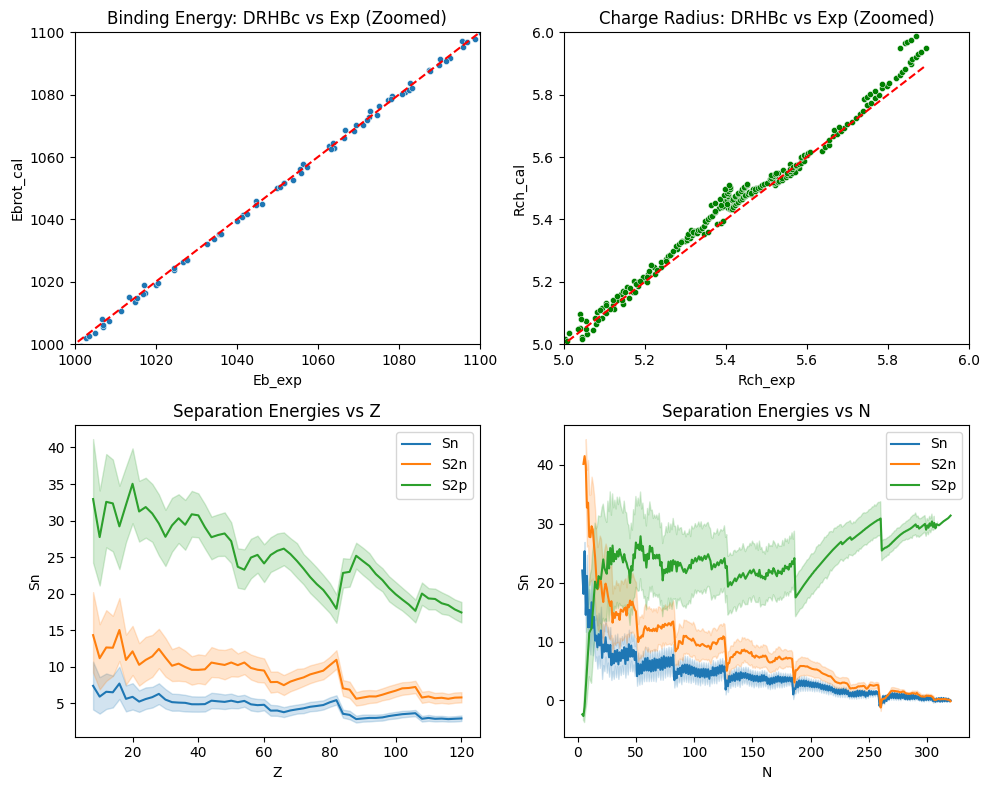

In [8]:
# Create a 3x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax1, ax2, ax3, ax4 = axes.flatten()

sns.scatterplot(data=df, x='Eb_exp', y='Ebrot_cal', s=20, ax=ax1)
ax1.plot([df['Eb_exp'].min(), df['Eb_exp'].max()], [df['Eb_exp'].min(), df['Eb_exp'].max()], 'r--')
ax1.set_xlim(1000, 1100); ax1.set_ylim(1000, 1100)
ax1.set_title("Binding Energy: DRHBc vs Exp (Zoomed)")

sns.scatterplot(data=df, x='Rch_exp', y='Rch_cal', s=20, ax=ax2, color='green')
ax2.plot([df['Rch_exp'].min(), df['Rch_exp'].max()], [df['Rch_exp'].min(), df['Rch_exp'].max()], 'r--')
ax2.set_xlim(5, 6); ax2.set_ylim(5, 6)
ax2.set_title("Charge Radius: DRHBc vs Exp (Zoomed)")

sns.lineplot(data=df, x='Z', y='Sn', ax=ax3, label='Sn')
sns.lineplot(data=df, x='Z', y='S2n', ax=ax3, label='S2n')
sns.lineplot(data=df, x='Z', y='S2p', ax=ax3, label='S2p')
ax3.set_title("Separation Energies vs Z")

sns.lineplot(data=df, x='N', y='Sn', ax=ax4, label='Sn')
sns.lineplot(data=df, x='N', y='S2n', ax=ax4, label='S2n')
sns.lineplot(data=df, x='N', y='S2p', ax=ax4, label='S2p')
ax4.set_title("Separation Energies vs N")

plt.tight_layout()
plt.show()

### Additional Visualizations: Distribution of Key Variables

>To understand the data better, we visualize distributions of key observables like binding energies, radii, and deformations. This helps identify skewness or multimodality, which may indicate physical regimes (e.g., shell closures).

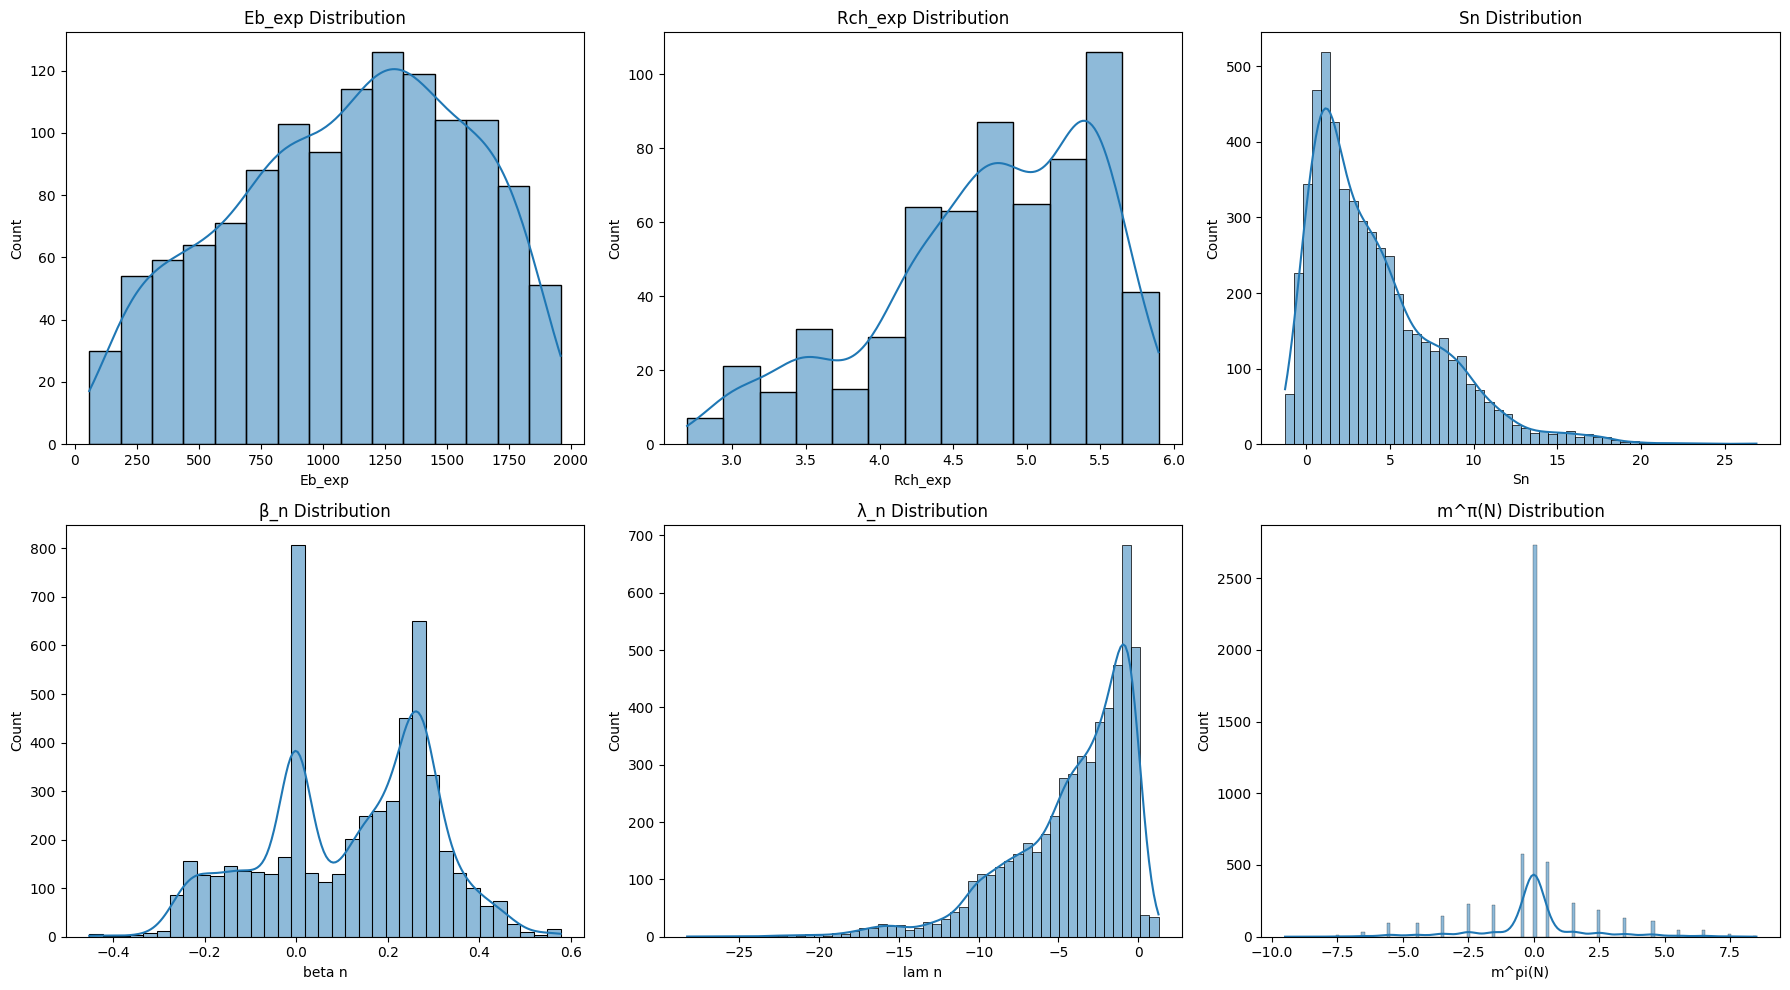

In [9]:
# Distributions of key variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(df['Eb_exp'], kde=True, ax=axes[0,0]).set_title('Eb_exp Distribution')
sns.histplot(df['Rch_exp'], kde=True, ax=axes[0,1]).set_title('Rch_exp Distribution')
sns.histplot(df['Sn'], kde=True, ax=axes[0,2]).set_title('Sn Distribution')
sns.histplot(df['beta n'], kde=True, ax=axes[1,0]).set_title('β_n Distribution')
sns.histplot(df['lam n'], kde=True, ax=axes[1,1]).set_title('λ_n Distribution')
sns.histplot(df["m^pi(N)"], kde=True, ax=axes[1,2]).set_title('m^π(N) Distribution')
plt.tight_layout()
plt.show()

## **Correlation Analysis**
> We compute and visualize correlations to identify relationships (e.g., between Z/N and energies) and potential redundancies (e.g., Eb_cal vs Ebrot_cal).

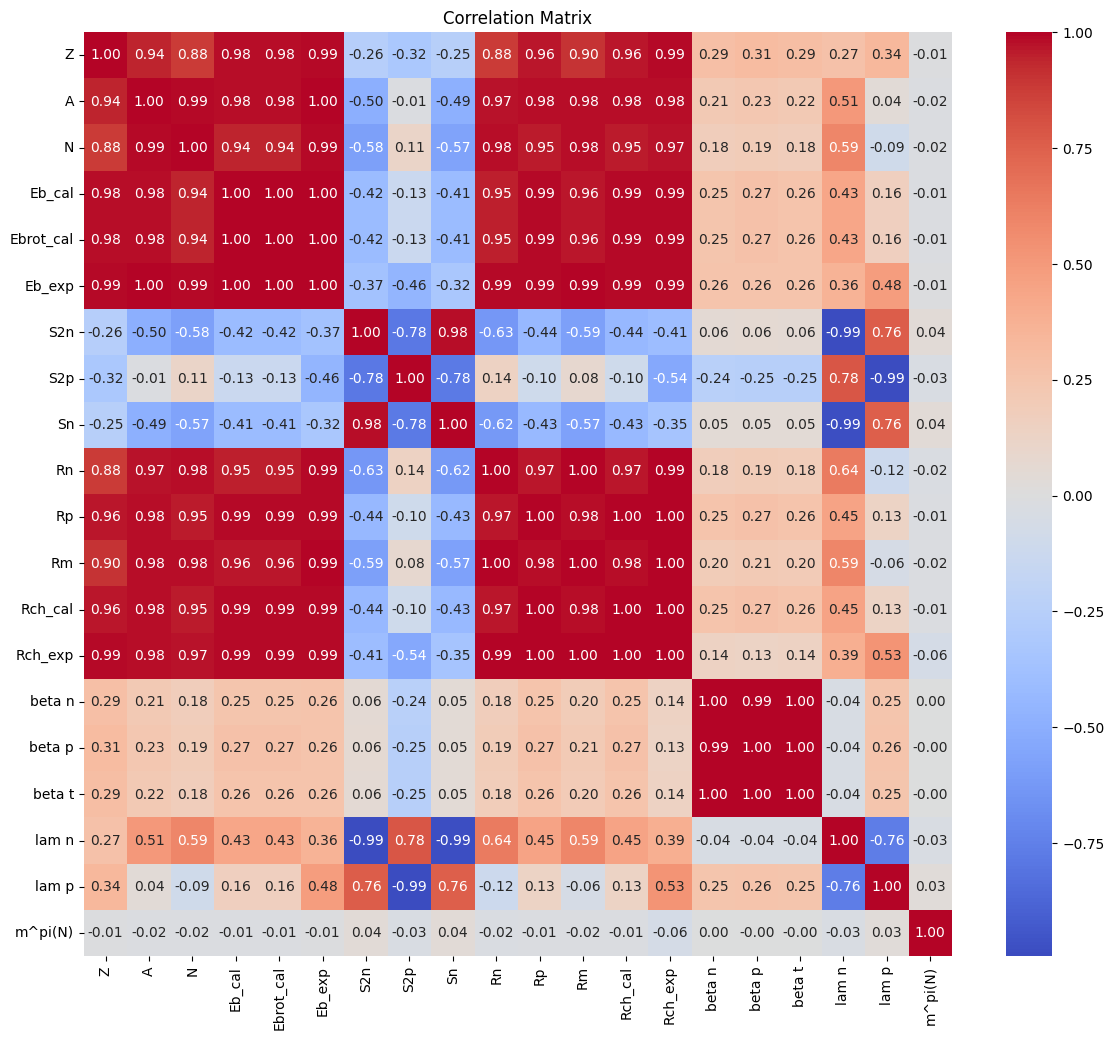

In [10]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## **Outlier Detection**

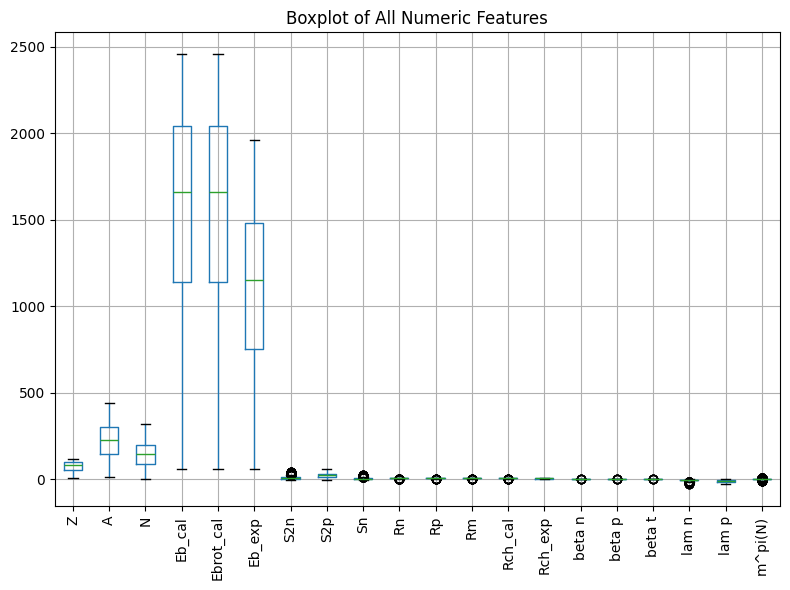

In [11]:
# Boxplot
df.boxplot(rot=90, figsize=(8, 6))
plt.title("Boxplot of All Numeric Features")
plt.tight_layout()

# Display
plt.show()

## **Feature Engineering (Physics-Informed)**
- delta = (N-Z)/A: Asymmetry parameter (Weizsäcker mass formula)
- A^(1/3): Nuclear radius scaling law R ∝ A^(1/3)
- dist_to_magic: Shell effects dominate at magic numbers (2,8,20,28,50,82,126)
- parity_N: Even-odd effects in pairing energy

In [12]:
# Physics-informed feature engineering
magic_numbers = [2, 8, 20, 28, 50, 82, 126]

# distance to magic numbers function
def dist_to_magic(x, magics):
    return min(abs(x - m) for m in magics)

In [13]:
# Add physics-informed features
df['delta'] = (df['N'] - df['Z']) / df['A']
df['A_1/3'] = df['A'] ** (1/3)
df['dist_Z_magic'] = df['Z'].apply(lambda z: dist_to_magic(z, magic_numbers))
df['dist_N_magic'] = df['N'].apply(lambda n: dist_to_magic(n, magic_numbers))
df['parity_N'] = df['N'] % 2  # 0 even, 1 odd

## **Regression Models**

**Impute Separation energies**
Separation energies follow smooth systematic trends with Z, N:
 - Sn(Z,N) = Eb(Z,N) - Eb(Z,N-1): One-neutron separation energy
 - S2n(Z,N) = Eb(Z,N) - Eb(Z,N-2): Two-neutron separation energy  
 - S2p(Z,N) = Eb(Z,N) - Eb(Z-2,N): Two-proton separation energy
 
Physical constraints:
1. Shell effects: Sharp drops at magic numbers (N,Z = 2,8,20,28,50,82,126)
2. Pairing effects: Odd-even staggering (even N nuclei more bound)
3. Smooth variation with N,Z away from shell closures
4. Correlation with deformation (β parameters)

Features for imputation:
 - Z, N, A (identity)
 - Eb_cal (baseline binding energy)
 - beta_n, beta_p, beta_t (deformation effects)
 - lam_n, lam_p (Fermi energies - directly related to separation energies)
 - dist_to_magic, parity_N (shell and pairing effects)

In [14]:
# Define features for separation energy imputation
sep_features = ['Z', 'N', 'A', 'Eb_cal', 'Ebrot_cal', 
                'beta n', 'beta p', 'beta t', 'lam n', 'lam p',
                'delta', 'A_1/3', 'dist_Z_magic', 'dist_N_magic', 'parity_N']

In [15]:
# Train models for each separation energy
def impute_separation_energy(target_col, features):
    """Train regression models and impute missing values"""
    
    # Prepare data
    known_mask = df[target_col].notna()
    df_known = df[known_mask].copy()
    df_unknown = df[~known_mask].copy()
    
    print(f"\n{target_col}:")
    print(f"  Known: {len(df_known)}, Unknown: {len(df_unknown)}")
    
    if len(df_unknown) == 0:
        print(f"  No missing values - skipping")
        return df[target_col]
    
    # Prepare training data
    X_known = df_known[features].fillna(0)  # Fill any feature NaNs
    y_known = df_known[target_col]
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_known, y_known, test_size=0.2, random_state=42
    )
    
    # Train multiple models (tree-based models handle it naturally)
    models = {
        'Linear': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1, max_iter=10000),
        'RF': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGB': XGBRegressor(n_estimators=200, random_state=42)
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name] = {
            'model': model,
            'MAE': mean_absolute_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred)
        }
    
    # Select best model
    best_name = min(results.keys(), key=lambda k: results[k]['MAE'])
    best_model = results[best_name]['model']
    
    print(f"  Best model: {best_name} (MAE={results[best_name]['MAE']:.3f}, R²={results[best_name]['R2']:.3f})")
    
    # Impute missing values
    X_unknown = df_unknown[features].fillna(0)
    predictions = best_model.predict(X_unknown)
    
    # Create complete series
    result = df[target_col].copy()
    result.loc[~known_mask] = predictions
    
    return result, best_model, results

In [16]:
# Impute each separation energy
df['Sn_imputed'], model_Sn, results_Sn = impute_separation_energy('Sn', sep_features)
df['S2n_imputed'], model_S2n, results_S2n = impute_separation_energy('S2n', sep_features)
df['S2p_imputed'], model_S2p, results_S2p = impute_separation_energy('S2p', sep_features)


Sn:
  Known: 5402, Unknown: 35
  Best model: XGB (MAE=0.159, R²=0.996)

S2n:
  Known: 5356, Unknown: 81
  Best model: XGB (MAE=0.250, R²=0.996)

S2p:
  Known: 5388, Unknown: 49
  Best model: XGB (MAE=0.234, R²=0.999)


## **Predict Expermental Binding Energy**
DRHBc theory provides systematic predictions (Eb_cal), but has residual errors:
 - Shell effects not fully captured
 - Deformation energy uncertainties
 - Beyond-mean-field correlations
 
 Δ-learning approach:
 ΔEb = Eb_exp - Eb_cal
 
 This residual follows smooth trends and can be learned via ML.
 Features capture corrections from:
 - Shell proximity (dist_to_magic)
 - Deformation (β parameters)
 - Asymmetry (δ)
 - Fermi surface properties (λ_n, λ_p)

In [17]:
# Define features (exclude targets)
eb_features = ['Z', 'N', 'A', 'Eb_cal', 'Ebrot_cal', 'Rn', 'Rp', 'Rm', 'Rch_cal',
               'beta n', 'beta p', 'beta t', 'lam n', 'lam p', "m^pi(N)",
               'delta', 'A_1/3', 'dist_Z_magic', 'dist_N_magic', 'parity_N']

In [18]:
# Split known vs unknown
known_mask = df['Eb_exp'].notna()
df_known = df[known_mask].copy()
df_unknown = df[~known_mask].copy()

In [19]:
print(f"\nKnown Eb_exp: {len(df_known)}")
print(f"Unknown Eb_exp: {len(df_unknown)}")


Known Eb_exp: 1264
Unknown Eb_exp: 4173


In [20]:
# Compute residual target
df_known['delta_Eb'] = df_known['Eb_exp'] - df_known['Eb_cal']

In [21]:
# Prepare training data
X_known = df_known[eb_features].fillna(0)
y_known = df_known['delta_Eb']

In [22]:
# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X_known, y_known, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [23]:
print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 884, Val: 190, Test: 190


In [24]:
# Regression models (predict ΔEb)
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.1, random_state=42),
    'SVM': SVR(kernel='rbf', C=100, gamma='scale')
}

In [25]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    results[name] = {
        'MSE': mean_squared_error(y_val, y_pred_val),
        'MAE': mean_absolute_error(y_val, y_pred_val),
        'R2': r2_score(y_val, y_pred_val)
    }

In [26]:
# Get predictions from ALL regression models on the test set
pred_dict = {}
for name, model in models.items():
    pred_dict[name] = model.predict(X_test)

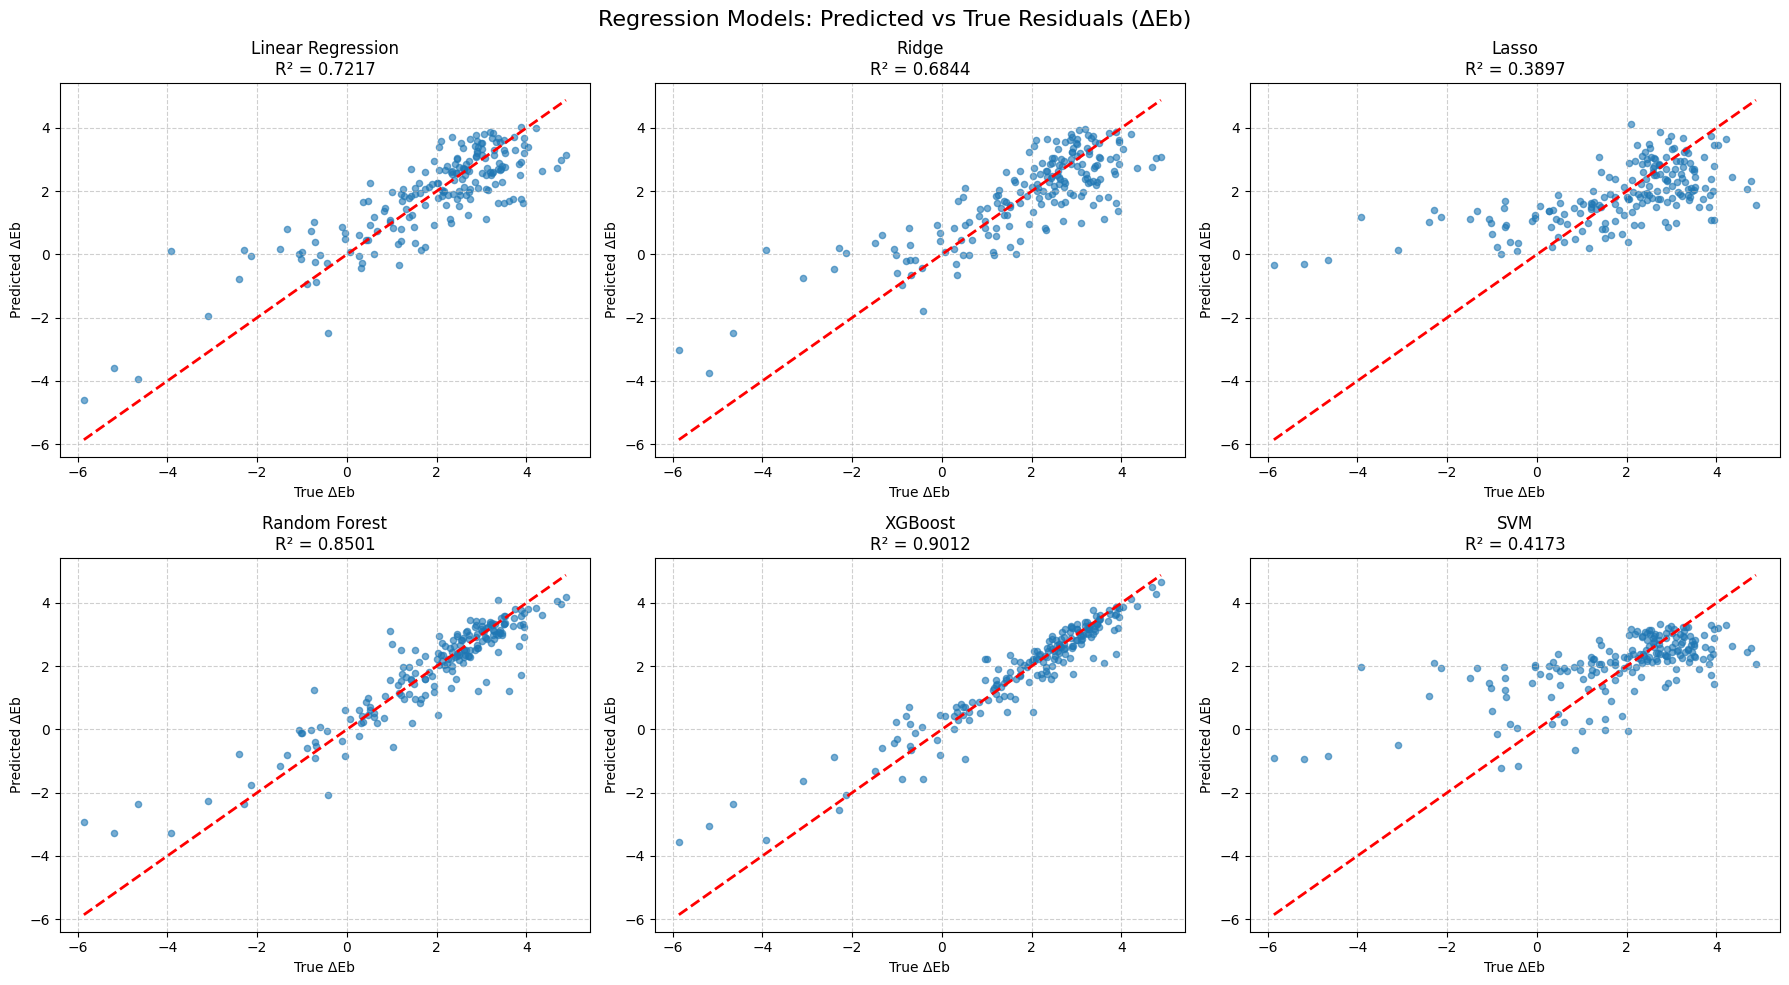

In [27]:
# Create subplots: 2 rows x 3 columns (5 models + empty)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(pred_dict.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.6, s=20)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_title(f"{name}\nR² = {r2_score(y_test, y_pred):.4f}", fontsize=12)
    ax.set_xlabel("True ΔEb")
    ax.set_ylabel("Predicted ΔEb")
    ax.grid(True, linestyle="--", alpha=0.6)


plt.suptitle("Regression Models: Predicted vs True Residuals (ΔEb)", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
# Display results in table
results_df = pd.DataFrame(results).T
results_df

,MSE,MAE,R2
Linear Regression,1.004889,0.752433,0.617187
Ridge,1.066680,0.782827,0.593648
Lasso,1.826830,1.015120,0.304068
Random Forest,0.417420,0.463808,0.840984
XGBoost,0.223894,0.333168,0.914707
SVM,1.794271,0.961748,0.316472


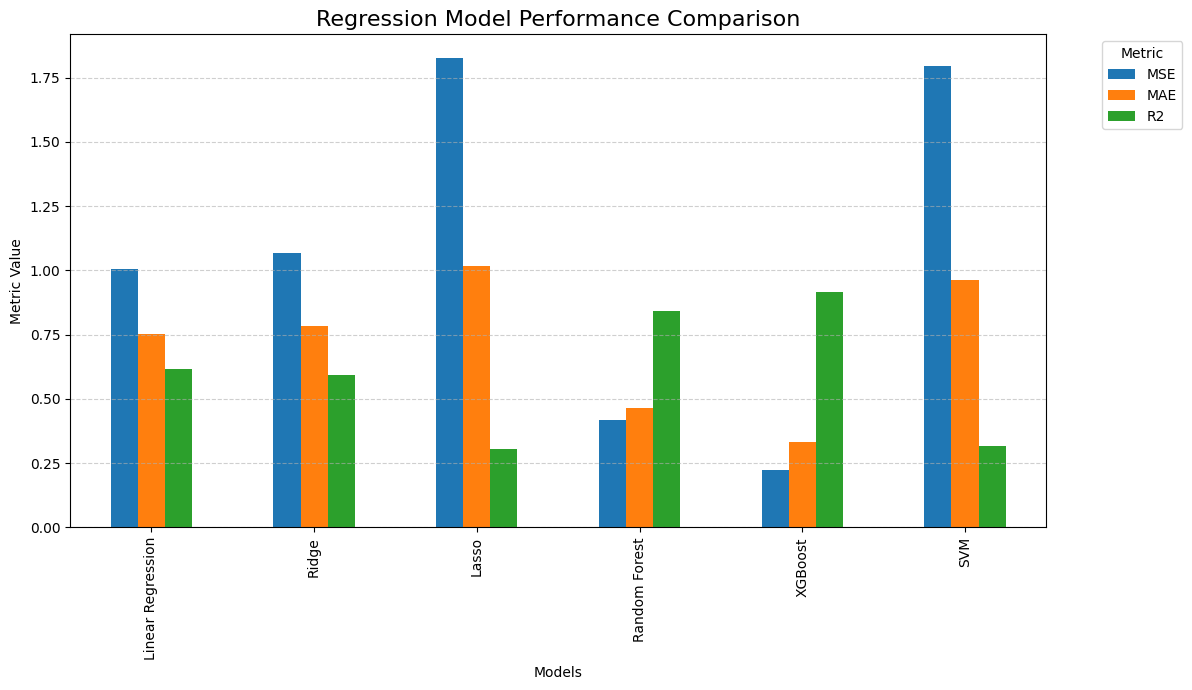

In [29]:
# Transpose for better plotting (models as x-axis)
results_plot = results_df

results_plot.plot(kind="bar", figsize=(12,7))
plt.title("Regression Model Performance Comparison", fontsize=16)
plt.ylabel("Metric Value")
plt.xlabel("Models")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
# Best model (e.g., lowest MSE)
best_model_name = results_df['MSE'].idxmin()
best_model = models[best_model_name]

In [31]:
# Test set evaluation
y_pred_test = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Best Model: {best_model_name} - Test MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}")

Best Model: XGBoost - Test MSE: 0.3179, MAE: 0.3762, R2: 0.9012


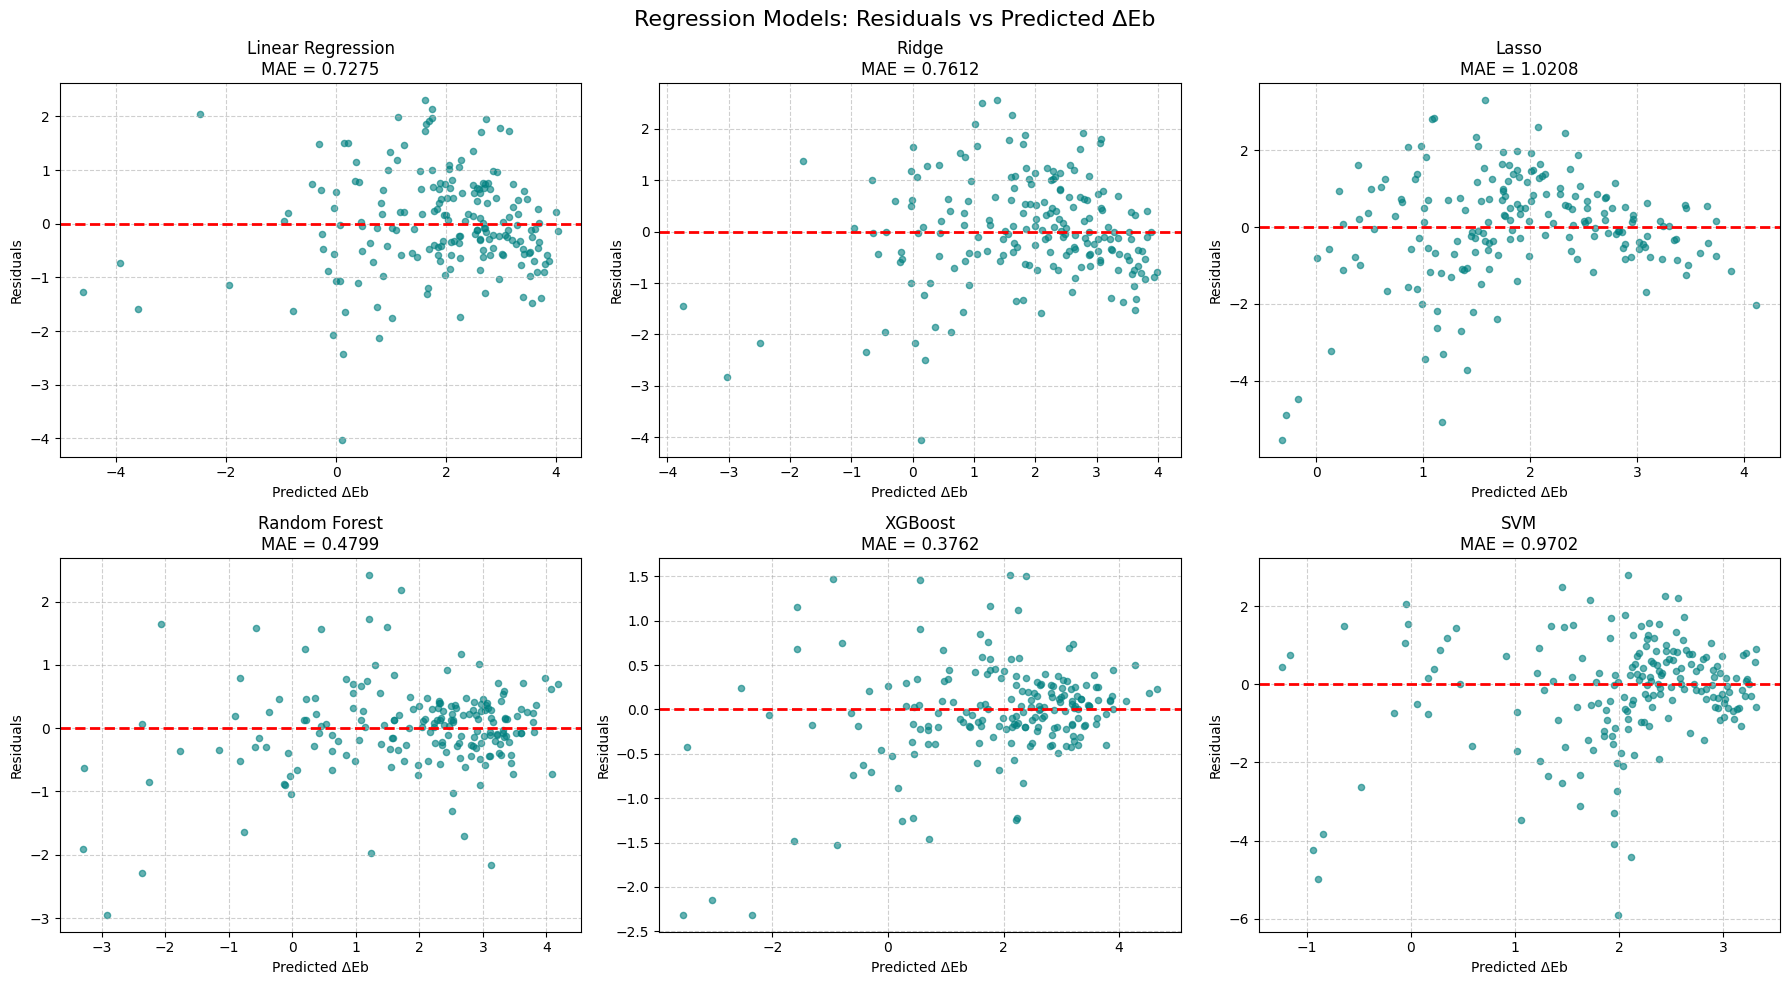

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(pred_dict.items()):
    ax = axes[i]
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, s=20, color='teal')
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    ax.set_title(f"{name}\nMAE = {mean_absolute_error(y_test, y_pred):.4f}", fontsize=12)
    ax.set_xlabel("Predicted ΔEb")
    ax.set_ylabel("Residuals")
    ax.grid(True, linestyle="--", alpha=0.6)
    
plt.suptitle("Regression Models: Residuals vs Predicted ΔEb", fontsize=16)
plt.tight_layout()
plt.show()

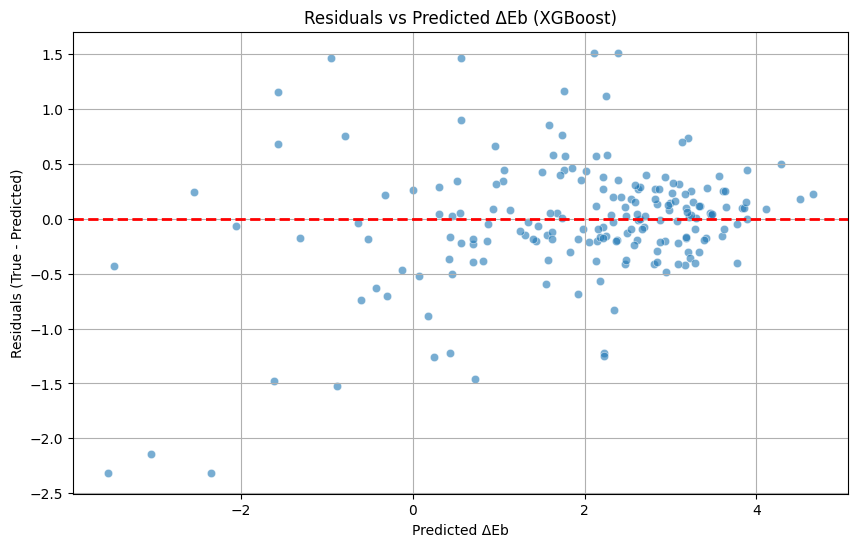

In [33]:
# Residual Plots for Best Model
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title(f'Residuals vs Predicted ΔEb ({best_model_name})')
plt.xlabel('Predicted ΔEb')
plt.ylabel('Residuals (True - Predicted)')
plt.grid(True)
plt.show()

In [34]:
# Predict ΔEb for ALL unknowns
X_unknown = df_unknown[eb_features]
delta_Eb_pred = best_model.predict(X_unknown)

In [35]:
# Corrected Eb_exp = Eb_cal + ΔEb_pred
df_unknown['Eb_exp_pred'] = df_unknown['Eb_cal'] + delta_Eb_pred

In [36]:
# Combine known and predicted
df_final = pd.concat([df_known, df_unknown], ignore_index=True)
# Fill missing Eb_exp with predictions
df_final['Eb_exp'] = df_final['Eb_exp'].fillna(df_final['Eb_exp_pred'])

In [37]:
# Drop the prediction column
df_final = df_final.drop(columns=['Eb_exp_pred','delta_Eb'])

Separation energies are defined by binding energy differences:
 - Sn(Z,N) = Eb(Z,N) - Eb(Z,N-1)
 - S2n(Z,N) = Eb(Z,N) - Eb(Z,N-2)
 - S2p(Z,N) = Eb(Z,N) - Eb(Z-2,N)

In [38]:
# Create a lookup dictionary: (Z, N) -> Eb_exp
eb_map = df_final.set_index(['Z', 'N'])['Eb_exp'].to_dict()

In [39]:
def safe_get_eb(z, n):
    """Safely retrieve Eb_exp, return NaN if not found"""
    return eb_map.get((z, n), np.nan)

In [40]:
# Calculate separation energies using physics laws
df_final['Sn_calc'] = df_final.apply(
    lambda r: safe_get_eb(r.Z, r.N) - safe_get_eb(r.Z, r.N-1), axis=1
)
df_final['S2n_calc'] = df_final.apply(
    lambda r: safe_get_eb(r.Z, r.N) - safe_get_eb(r.Z, r.N-2), axis=1
)
df_final['S2p_calc'] = df_final.apply(
    lambda r: safe_get_eb(r.Z, r.N) - safe_get_eb(r.Z-2, r.N), axis=1
)

In [41]:
# Merge with imputed values: prioritize calculated (physics) over imputed (ML)
# First bring imputed values into df_final
df_final['Sn_imputed'] = df['Sn_imputed']
df_final['S2n_imputed'] = df['S2n_imputed']
df_final['S2p_imputed'] = df['S2p_imputed']

# Use physics-calculated where available, fallback to imputed
df_final['Sn_final'] = df_final['Sn_calc'].fillna(df_final['Sn_imputed'])
df_final['S2n_final'] = df_final['S2n_calc'].fillna(df_final['S2n_imputed'])
df_final['S2p_final'] = df_final['S2p_calc'].fillna(df_final['S2p_imputed'])

## **Comparing Separation Energies: Direct ML vs Indirect ML**

This section compares **two ML-based approaches** for predicting separation energies:

**IMPORTANT CONTEXT:**
- Initial missing data: `Eb_exp` (4173), `Sn` (35), `S2n` (81), `S2p` (49)
- Most `Eb_exp` values are now **ML-predicted**, not experimental

**The Two Approaches:**
1. **Direct ML**: Direct imputation of separation energies using ML models
   - Trained on features: Z, N, A, Eb_cal, β parameters, λ parameters, etc.
   - Predicts Sn, S2n, S2p directly

2. **Indirect ML**: Physics formula applied to ML-predicted binding energies
   - Uses: Sn = Eb(Z,N) - Eb(Z,N-1)
   - Since most Eb values are ML-predicted, this is also ML-based
   - Enforces physics constraint (additivity law)

**What We're Evaluating:**
- Consistency between two ML methodologies
- Which approach better matches sparse experimental data
- Regions of high prediction uncertainty

In [42]:
# CREATE COMPARISON DATAFRAMES

# Three dataframes for Sn, S2n, S2p showing:
#   - Original experimental values (where available - sparse!)
#   - Direct ML imputation
#   - Indirect ML (from ML-corrected Eb using physics formula)
#   - Differences and error statistics

# List to store all comparison dataframes
all_comparisons = {}

for sep_energy in ['Sn', 'S2n', 'S2p']:
    # Define column names
    impute_col = f'{sep_energy}_imputed'  # Direct ML
    calc_col = f'{sep_energy}_calc'  # From ML-corrected Eb
    exp_col = sep_energy  # Original experimental (sparse)
    
    # Where both approaches are available
    both_mask = df_final[calc_col].notna() & df_final[impute_col].notna()
    
    # Create comprehensive comparison dataframe
    comparison_df = pd.DataFrame({
        # Nuclear identifiers
        'Z': df_final[both_mask]['Z'].astype(int),
        'N': df_final[both_mask]['N'].astype(int),
        'A': df_final[both_mask]['A'].astype(int),
        
        # Three values
        f'{sep_energy}_Exp': df_final[both_mask][exp_col],  # Original experimental (sparse)
        f'{sep_energy}_DirectML': df_final[both_mask][impute_col],  # Direct ML
        f'{sep_energy}_IndirectML': df_final[both_mask][calc_col],  # From ML-corrected Eb
        
        # Differences between ML approaches
        'Diff_Indirect_Direct': df_final[both_mask][calc_col] - df_final[both_mask][impute_col],
        'Abs_Diff': (df_final[both_mask][calc_col] - df_final[both_mask][impute_col]).abs(),
        
        # Errors relative to experiment (where available)
        'Error_DirectML': np.nan,
        'Error_IndirectML': np.nan,
        'Abs_Error_DirectML': np.nan,
        'Abs_Error_IndirectML': np.nan,
        
        # Which approach is better
        'Better_Method': 'N/A'
    })
    
    # Calculate errors relative to experimental data (where available)
    has_exp = comparison_df[f'{sep_energy}_Exp'].notna()
    
    if has_exp.sum() > 0:
        # Error = Prediction - Experiment
        comparison_df.loc[has_exp, 'Error_DirectML'] = (
            comparison_df.loc[has_exp, f'{sep_energy}_DirectML'] - 
            comparison_df.loc[has_exp, f'{sep_energy}_Exp']
        )
        comparison_df.loc[has_exp, 'Error_IndirectML'] = (
            comparison_df.loc[has_exp, f'{sep_energy}_IndirectML'] - 
            comparison_df.loc[has_exp, f'{sep_energy}_Exp']
        )
        comparison_df.loc[has_exp, 'Abs_Error_DirectML'] = comparison_df.loc[has_exp, 'Error_DirectML'].abs()
        comparison_df.loc[has_exp, 'Abs_Error_IndirectML'] = comparison_df.loc[has_exp, 'Error_IndirectML'].abs()
        
        # Determine better method for each nucleus
        better_direct = comparison_df.loc[has_exp, 'Abs_Error_DirectML'] < comparison_df.loc[has_exp, 'Abs_Error_IndirectML']
        better_indirect = comparison_df.loc[has_exp, 'Abs_Error_IndirectML'] < comparison_df.loc[has_exp, 'Abs_Error_DirectML']
        
        comparison_df.loc[has_exp & better_direct, 'Better_Method'] = 'Direct ML'
        comparison_df.loc[has_exp & better_indirect, 'Better_Method'] = 'Indirect ML'
        comparison_df.loc[has_exp & ~(better_direct | better_indirect), 'Better_Method'] = 'Tie'
    
    # Create aliases for backward compatibility with existing code
    comparison_df['Diff_Calc_Impute'] = comparison_df['Diff_Indirect_Direct']
    comparison_df['Abs_Diff_Calc_Impute'] = comparison_df['Abs_Diff']
    comparison_df['Error_Calc'] = comparison_df['Error_IndirectML']
    comparison_df['Error_Impute'] = comparison_df['Error_DirectML']
    comparison_df['Abs_Error_Calc'] = comparison_df['Abs_Error_IndirectML']
    comparison_df['Abs_Error_Impute'] = comparison_df['Abs_Error_DirectML']
    
    # Store in dictionary
    all_comparisons[sep_energy] = comparison_df
    
    print(f"✓ Created comparison for {sep_energy}: {len(comparison_df)} nuclei")
    print(f"  - With experimental data: {has_exp.sum()}")
    print(f"  - ML-predicted only: {(~has_exp).sum()}")

✓ Created comparison for Sn: 5380 nuclei
  - With experimental data: 5378
  - ML-predicted only: 2
✓ Created comparison for S2n: 5323 nuclei
  - With experimental data: 5321
  - ML-predicted only: 2
✓ Created comparison for S2p: 5119 nuclei
  - With experimental data: 5117
  - ML-predicted only: 2


In [43]:
# Display Sn
all_comparisons['Sn'].head()

,Z,N,A,Sn_Exp,Sn_DirectML,Sn_IndirectML,Diff_Indirect_Direct,Abs_Diff,Error_DirectML,Error_IndirectML,Abs_Error_DirectML,Abs_Error_IndirectML,Better_Method,Diff_Calc_Impute,Abs_Diff_Calc_Impute,Error_Calc,Error_Impute,Abs_Error_Calc,Abs_Error_Impute
1,8,5,13,18.08,18.08,16.97,-1.11,1.11,0.0,-1.11,0.0,1.11,Direct ML,-1.11,1.11,-1.11,0.0,1.11,0.0
2,8,6,14,23.38,23.38,23.18,-0.20,0.20,0.0,-0.20,0.0,0.20,Direct ML,-0.20,0.20,-0.20,0.0,0.20,0.0
3,8,7,15,11.64,11.64,13.23,1.59,1.59,0.0,1.59,0.0,1.59,Direct ML,1.59,1.59,1.59,0.0,1.59,0.0
4,8,8,16,14.47,14.47,15.66,1.19,1.19,0.0,1.19,0.0,1.19,Direct ML,1.19,1.19,1.19,0.0,1.19,0.0
5,8,9,17,5.27,5.27,4.14,-1.13,1.13,0.0,-1.13,0.0,1.13,Direct ML,-1.13,1.13,-1.13,0.0,1.13,0.0


In [44]:
# Display S2n
all_comparisons['S2n'].head()

,Z,N,A,S2n_Exp,S2n_DirectML,S2n_IndirectML,Diff_Indirect_Direct,Abs_Diff,Error_DirectML,Error_IndirectML,Abs_Error_DirectML,Abs_Error_IndirectML,Better_Method,Diff_Calc_Impute,Abs_Diff_Calc_Impute,Error_Calc,Error_Impute,Abs_Error_Calc,Abs_Error_Impute
2,8,6,14,41.46,41.46,40.15,-1.31,1.31,0.0,-1.31,0.0,1.31,Direct ML,-1.31,1.31,-1.31,0.0,1.31,0.0
3,8,7,15,35.02,35.02,36.41,1.39,1.39,0.0,1.39,0.0,1.39,Direct ML,1.39,1.39,1.39,0.0,1.39,0.0
4,8,8,16,26.11,26.11,28.89,2.78,2.78,0.0,2.78,0.0,2.78,Direct ML,2.78,2.78,2.78,0.0,2.78,0.0
5,8,9,17,19.74,19.74,19.80,0.06,0.06,0.0,0.06,0.0,0.06,Direct ML,0.06,0.06,0.06,0.0,0.06,0.0
6,8,10,18,13.69,13.69,12.19,-1.50,1.50,0.0,-1.50,0.0,1.50,Direct ML,-1.50,1.50,-1.50,0.0,1.50,0.0


In [45]:
# Display S2p
all_comparisons['S2p'].head()

,Z,N,A,S2p_Exp,S2p_DirectML,S2p_IndirectML,Diff_Indirect_Direct,Abs_Diff,Error_DirectML,Error_IndirectML,Abs_Error_DirectML,Abs_Error_IndirectML,Better_Method,Diff_Calc_Impute,Abs_Diff_Calc_Impute,Error_Calc,Error_Impute,Abs_Error_Calc,Abs_Error_Impute
15,10,5,15,-3.35,52.62,-2.52,-55.14,55.14,55.97,0.83,55.97,0.83,Indirect ML,-55.14,55.14,0.83,55.97,0.83,55.97
16,10,6,16,-1.01,54.80,-1.40,-56.20,56.20,55.81,-0.39,55.81,0.39,Indirect ML,-56.20,56.20,-0.39,55.81,0.39,55.81
17,10,7,17,1.81,54.98,0.93,-54.05,54.05,53.17,-0.88,53.17,0.88,Indirect ML,-54.05,54.05,-0.88,53.17,0.88,53.17
18,10,8,18,5.81,55.27,4.52,-50.75,50.75,49.46,-1.29,49.46,1.29,Indirect ML,-50.75,50.75,-1.29,49.46,1.29,49.46
19,10,9,19,10.34,-3.35,12.02,15.37,15.37,-13.69,1.68,13.69,1.68,Indirect ML,15.37,15.37,1.68,-13.69,1.68,13.69


In [46]:
# STATISTICAL SUMMARY: Consistency Between Two ML Approaches
# 
# This analysis compares:
#   - **Direct ML**: Direct imputation of separation energies
#   - **Indirect ML**: Calculated from ML-predicted Eb using physics formula
 
# Key metrics:
#   - Mean/Std/Median: Central tendency and spread of differences
#   - MAE/RMSE: Overall agreement between approaches
#   - Interpretation: How consistent are the two ML methodologies?

for sep_energy in ['Sn', 'S2n', 'S2p']:
    comparison_df = all_comparisons[sep_energy]
    
    print(f"\n{'='*80}")
    print(f"{sep_energy}: STATISTICAL SUMMARY - Two ML Approaches")
    print(f"{'='*80}")
    print(f"Approach 1: Direct ML imputation of {sep_energy}")
    print(f"Approach 2: Indirect ML (physics formula applied to ML-predicted Eb)")
    print(f"{'='*80}")
    
    print(f"\nTotal nuclei compared: {len(comparison_df)}")
    print(f"Nuclei with experimental data: {comparison_df[f'{sep_energy}_Exp'].notna().sum()}")
    print(f"Nuclei without experimental data: {comparison_df[f'{sep_energy}_Exp'].isna().sum()}")
    
    print(f"\n{'DIFFERENCE STATISTICS (Indirect - Direct):':-^80}")
    print(f"  Mean difference: {comparison_df['Diff_Indirect_Direct'].mean():>10.4f} MeV")
    print(f"  Std difference:  {comparison_df['Diff_Indirect_Direct'].std():>10.4f} MeV")
    print(f"  Median difference: {comparison_df['Diff_Indirect_Direct'].median():>8.4f} MeV")
    print(f"  Min difference:  {comparison_df['Diff_Indirect_Direct'].min():>10.4f} MeV")
    print(f"  Max difference:  {comparison_df['Diff_Indirect_Direct'].max():>10.4f} MeV")
    
    print(f"\n{'AGREEMENT METRICS:':-^80}")
    print(f"  MAE:  {comparison_df['Abs_Diff'].mean():>10.4f} MeV")
    print(f"  RMSE: {np.sqrt((comparison_df['Diff_Indirect_Direct']**2).mean()):>10.4f} MeV")
    
    # Interpretation
    mae = comparison_df['Abs_Diff'].mean()
    print(f"\n{'INTERPRETATION:':-^80}")
    if mae < 0.5:
        print(f"  ✓ EXCELLENT consistency (MAE = {mae:.3f} MeV)")
        print(f"     Both ML approaches produce nearly identical results")
        print(f"     High confidence in predictions for this quantity")
    elif mae < 1.0:
        print(f"  ✓ GOOD consistency (MAE = {mae:.3f} MeV)")
        print(f"     Minor differences between approaches")
        print(f"     Reasonable confidence in predictions")
    elif mae < 2.0:
        print(f"   MODERATE consistency (MAE = {mae:.3f} MeV)")
        print(f"     Notable differences - approaches capture different features")
        print(f"     Moderate uncertainty in predictions")
    else:
        print(f"   POOR consistency (MAE = {mae:.3f} MeV)")
        print(f"     Significant disagreement between approaches")
        print(f"     High uncertainty - predictions should be used with caution")


Sn: STATISTICAL SUMMARY - Two ML Approaches
Approach 1: Direct ML imputation of Sn
Approach 2: Indirect ML (physics formula applied to ML-predicted Eb)

Total nuclei compared: 5380
Nuclei with experimental data: 5378
Nuclei without experimental data: 2

-------------------DIFFERENCE STATISTICS (Indirect - Direct):-------------------
  Mean difference:    -0.1389 MeV
  Std difference:      4.8542 MeV
  Median difference:  -0.0169 MeV
  Min difference:    -21.1200 MeV
  Max difference:     23.1677 MeV

-------------------------------AGREEMENT METRICS:-------------------------------
  MAE:      3.4172 MeV
  RMSE:     4.8557 MeV

--------------------------------INTERPRETATION:---------------------------------
   POOR consistency (MAE = 3.417 MeV)
     Significant disagreement between approaches
     High uncertainty - predictions should be used with caution

S2n: STATISTICAL SUMMARY - Two ML Approaches
Approach 1: Direct ML imputation of S2n
Approach 2: Indirect ML (physics formula applie

In [47]:
# VALIDATION: Which ML Approach Better Matches Experimental Data?
# For nuclei where experimental data exists (sparse!), we can evaluate:
#   - Which approach is closer to experiment on average?
#   - For individual nuclei, which approach is more accurate?
# 
# Only 35-81 nuclei have experimental separation energy data!

for sep_energy in ['Sn', 'S2n', 'S2p']:
    comparison_df = all_comparisons[sep_energy]
    has_exp = comparison_df[f'{sep_energy}_Exp'].notna()
    
    if has_exp.sum() == 0:
        print(f"\n{sep_energy}: No experimental validation data available")
        continue
    
    exp_data = comparison_df[has_exp].copy()
    
    print(f"\n{'='*80}")
    print(f"{sep_energy}: VALIDATION AGAINST EXPERIMENTAL DATA")
    print(f"{'='*80}")
    print(f"Experimental data available for {has_exp.sum()} nuclei (out of {len(comparison_df)})")
    print(f"Coverage: {100*has_exp.sum()/len(comparison_df):.1f}%")
    print(f"{'='*80}")
    
    # Statistics for both approaches
    mae_direct = exp_data['Abs_Error_DirectML'].mean()
    rmse_direct = np.sqrt((exp_data['Error_DirectML']**2).mean())
    bias_direct = exp_data['Error_DirectML'].mean()
    r2_direct = r2_score(exp_data[f'{sep_energy}_Exp'], exp_data[f'{sep_energy}_DirectML'])
    
    mae_indirect = exp_data['Abs_Error_IndirectML'].mean()
    rmse_indirect = np.sqrt((exp_data['Error_IndirectML']**2).mean())
    bias_indirect = exp_data['Error_IndirectML'].mean()
    r2_indirect = r2_score(exp_data[f'{sep_energy}_Exp'], exp_data[f'{sep_energy}_IndirectML'])
    
    print(f"\n{'Approach 1: Direct ML (imputation)':-^80}")
    print(f"  MAE:  {mae_direct:>8.4f} MeV")
    print(f"  RMSE: {rmse_direct:>8.4f} MeV")
    print(f"  Bias: {bias_direct:>8.4f} MeV")
    print(f"  R²:   {r2_direct:>8.4f}")
    
    print(f"\n{'Approach 2: Indirect ML (via ML-predicted Eb)':-^80}")
    print(f"  MAE:  {mae_indirect:>8.4f} MeV")
    print(f"  RMSE: {rmse_indirect:>8.4f} MeV")
    print(f"  Bias: {bias_indirect:>8.4f} MeV")
    print(f"  R²:   {r2_indirect:>8.4f}")
    
    # Comparison
    improvement = abs(mae_direct - mae_indirect)
    improvement_pct = (improvement / max(mae_direct, mae_indirect)) * 100
    
    print(f"\n{'VERDICT:':-^80}")
    if mae_direct < mae_indirect:
        print(f"✓ Direct ML is BETTER by {improvement:.4f} MeV ({improvement_pct:.1f}%)")
        print(f"   Direct imputation captures {sep_energy} features more accurately")
    elif mae_indirect < mae_direct:
        print(f"✓ Indirect ML is BETTER by {improvement:.4f} MeV ({improvement_pct:.1f}%)")
        print(f"   Physics constraints (via Eb additivity) improve predictions")
    else:
        print(f"○ Both approaches perform equally (difference < 0.0001 MeV)")
    
    # Per-nucleus breakdown
    better_counts = exp_data['Better_Method'].value_counts()
    print(f"\n{'Per-nucleus breakdown:':-^80}")
    for method, count in better_counts.items():
        pct = (count / len(exp_data)) * 100
        print(f"  {method:<15s}: {count:>4d} nuclei ({pct:>5.1f}%)")
    
    # R² comparison
    if abs(r2_direct - r2_indirect) > 0.01:
        print(f"\n{'Correlation quality:':-^80}")
        if r2_direct > r2_indirect:
            print(f"  Direct ML shows stronger correlation with experiment")
        else:
            print(f"  Indirect ML shows stronger correlation with experiment")


Sn: VALIDATION AGAINST EXPERIMENTAL DATA
Experimental data available for 5378 nuclei (out of 5380)
Coverage: 100.0%

-----------------------Approach 1: Direct ML (imputation)-----------------------
  MAE:    3.3672 MeV
  RMSE:   4.8228 MeV
  Bias:   0.0979 MeV
  R²:    -0.6573

-----------------Approach 2: Indirect ML (via ML-predicted Eb)------------------
  MAE:    0.3353 MeV
  RMSE:   0.5543 MeV
  Bias:  -0.0410 MeV
  R²:     0.9781

------------------------------------VERDICT:------------------------------------
✓ Indirect ML is BETTER by 3.0318 MeV (90.0%)
   Physics constraints (via Eb additivity) improve predictions

-----------------------------Per-nucleus breakdown:-----------------------------
  Indirect ML    : 4240 nuclei ( 78.8%)
  Direct ML      : 1138 nuclei ( 21.2%)

------------------------------Correlation quality:------------------------------
  Indirect ML shows stronger correlation with experiment

S2n: VALIDATION AGAINST EXPERIMENTAL DATA
Experimental data availa

In [48]:
# LARGE DIFFERENCES ANALYSIS: Where Do ML Approaches Disagree?

# Identifies nuclei where the two ML approaches produce significantly
# different predictions (|Difference| > threshold).
# 
# Key questions:
#   1. How many nuclei show large disagreements?
#   2. What are the characteristics of these nuclei?
#   3. When experimental data exists, which approach is closer?
# 
# Large disagreements indicate:
#   - High prediction uncertainty
#   - Potential systematic issues
#   - Regions where more experimental data is needed

large_diff_threshold = 2.0  # MeV

for sep_energy in ['Sn', 'S2n', 'S2p']:
    comparison_df = all_comparisons[sep_energy]
    
    print(f"\n{'='*80}")
    print(f"{sep_energy}: LARGE DISAGREEMENTS (|Difference| > {large_diff_threshold} MeV)")
    print(f"{'='*80}")
    print(f"Cases where Direct ML and Indirect ML significantly disagree")
    print(f"{'-'*80}")
    
    # Identify large differences
    large_diff = comparison_df[comparison_df['Abs_Diff'] > large_diff_threshold].copy()
    
    total_nuclei = len(comparison_df)
    n_large = len(large_diff)
    pct_large = (n_large / total_nuclei) * 100
    
    print(f"\nTotal nuclei compared: {total_nuclei}")
    print(f"Large disagreements (|Diff| > {large_diff_threshold} MeV): {n_large} ({pct_large:.1f}%)")
    
    if n_large == 0:
        print(f"\n No large disagreements - both ML approaches are highly consistent!")
        print(f"    Predictions are reliable across all nuclei")
        continue
    
    # Statistics for large differences
    print(f"\n{'STATISTICS FOR LARGE DISAGREEMENTS:':-^80}")
    print(f"  Mean |Difference|:   {large_diff['Abs_Diff'].mean():>8.4f} MeV")
    print(f"  Median |Difference|: {large_diff['Abs_Diff'].median():>8.4f} MeV")
    print(f"  Max |Difference|:    {large_diff['Abs_Diff'].max():>8.4f} MeV")
    print(f"  Std |Difference|:    {large_diff['Abs_Diff'].std():>8.4f} MeV")
    
    # Show top 10 worst cases
    print(f"\n{'Top 10 Cases with Largest Disagreement:':-^80}")
    
    display_cols = ['Z', 'N', 'A', 
                   f'{sep_energy}_Exp',
                   f'{sep_energy}_DirectML',
                   f'{sep_energy}_IndirectML',
                   'Diff_Indirect_Direct',
                   'Abs_Diff']
    
    top10 = large_diff.nlargest(10, 'Abs_Diff')[display_cols].copy()
    top10.columns = ['Z', 'N', 'A', 
                     'Exp_Value', 
                     'Direct_ML', 
                     'Indirect_ML', 
                     'Difference', 
                     '|Difference|']
    
    print(top10.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    
    # Experimental validation for large differences
    has_exp_in_large = top10['Exp_Value'].notna()
    
    if has_exp_in_large.sum() > 0:
        print(f"\n{'EXPERIMENTAL VALIDATION FOR TOP 10:':-^80}")
        print(f"{has_exp_in_large.sum()} of the top 10 cases have experimental data")
        
        # Full analysis of all large differences with experimental data
        exp_cases_large = comparison_df[
            (comparison_df['Abs_Diff'] > large_diff_threshold) & 
            (comparison_df[f'{sep_energy}_Exp'].notna())
        ].copy()
        
        if len(exp_cases_large) > 0:
            n_direct_better = (exp_cases_large['Abs_Error_DirectML'] < exp_cases_large['Abs_Error_IndirectML']).sum()
            n_indirect_better = (exp_cases_large['Abs_Error_IndirectML'] < exp_cases_large['Abs_Error_DirectML']).sum()
            n_tie = len(exp_cases_large) - n_direct_better - n_indirect_better
            
            print(f"\nAll {len(exp_cases_large)} cases with large diff AND experimental data:")
            print(f"  Direct ML closer to experiment:   {n_direct_better:>4d} ({100*n_direct_better/len(exp_cases_large):.1f}%)")
            print(f"  Indirect ML closer to experiment: {n_indirect_better:>4d} ({100*n_indirect_better/len(exp_cases_large):.1f}%)")
            if n_tie > 0:
                print(f"  Tie (equal error):                {n_tie:>4d} ({100*n_tie/len(exp_cases_large):.1f}%)")
            
            print(f"\n{'VERDICT FOR DIFFICULT CASES:':-^80}")
            if n_direct_better > n_indirect_better * 1.2:  # At least 20% better
                print(f"  ✓ Direct ML is MORE RELIABLE for difficult cases")
                print(f"     When approaches disagree, trust direct imputation")
            elif n_indirect_better > n_direct_better * 1.2:
                print(f"  ✓ Indirect ML is MORE RELIABLE for difficult cases")
                print(f"     Physics constraints help when uncertainty is high")
            else:
                print(f"  ○ Both approaches are EQUALLY RELIABLE")
                print(f"     No clear winner - predictions are equally uncertain")
            
            # Average errors in difficult cases
            mae_direct_difficult = exp_cases_large['Abs_Error_DirectML'].mean()
            mae_indirect_difficult = exp_cases_large['Abs_Error_IndirectML'].mean()
            
            print(f"\nAverage errors in difficult cases:")
            print(f"  Direct ML:   MAE = {mae_direct_difficult:.4f} MeV")
            print(f"  Indirect ML: MAE = {mae_indirect_difficult:.4f} MeV")
    else:
        print(f"\n No experimental validation available for large disagreements")
        print(f"   Cannot determine which approach is more reliable")
        print(f"   More experimental data needed for these nuclei")
    
    # Characteristics of nuclei with large disagreements
    print(f"\n{'CHARACTERISTICS OF NUCLEI WITH LARGE DISAGREEMENTS:':-^80}")
    print(f"  Z range: {large_diff['Z'].min()} - {large_diff['Z'].max()}")
    print(f"  N range: {large_diff['N'].min()} - {large_diff['N'].max()}")
    print(f"  A range: {large_diff['A'].min()} - {large_diff['A'].max()}")
    
    # Check if disagreements cluster in certain regions
    if len(large_diff) > 10:
        z_median = comparison_df['Z'].median()
        n_median = comparison_df['N'].median()
        
        heavy = large_diff[(large_diff['Z'] > z_median) | (large_diff['N'] > n_median)]
        pct_heavy = len(heavy) / len(large_diff) * 100
        
        print(f"\n  Heavy nuclei (Z or N > median): {len(heavy)} ({pct_heavy:.1f}% of large diffs)")
        
        if pct_heavy > 60:
            print(f"   Large disagreements concentrate in HEAVY nuclei")
        elif pct_heavy < 40:
            print(f"   Large disagreements concentrate in LIGHT nuclei")
        else:
            print(f"   Large disagreements distributed across mass range")


Sn: LARGE DISAGREEMENTS (|Difference| > 2.0 MeV)
Cases where Direct ML and Indirect ML significantly disagree
--------------------------------------------------------------------------------

Total nuclei compared: 5380
Large disagreements (|Diff| > 2.0 MeV): 2914 (54.2%)

----------------------STATISTICS FOR LARGE DISAGREEMENTS:-----------------------
  Mean |Difference|:     5.7388 MeV
  Median |Difference|:   4.9468 MeV
  Max |Difference|:     23.1677 MeV
  Std |Difference|:      3.1527 MeV

--------------------Top 10 Cases with Largest Disagreement:---------------------
 Z  N  A  Exp_Value  Direct_ML  Indirect_ML  Difference  |Difference|
14  8 22     24.290      1.740       24.908      23.168        23.168
16 12 28     19.180     -0.210       22.233      22.443        22.443
10  6 16     25.720      2.530       24.300      21.770        21.770
12 20 32      6.340     26.900        5.780     -21.120        21.120
16 21 37      4.670     24.290        4.310     -19.980        19.98

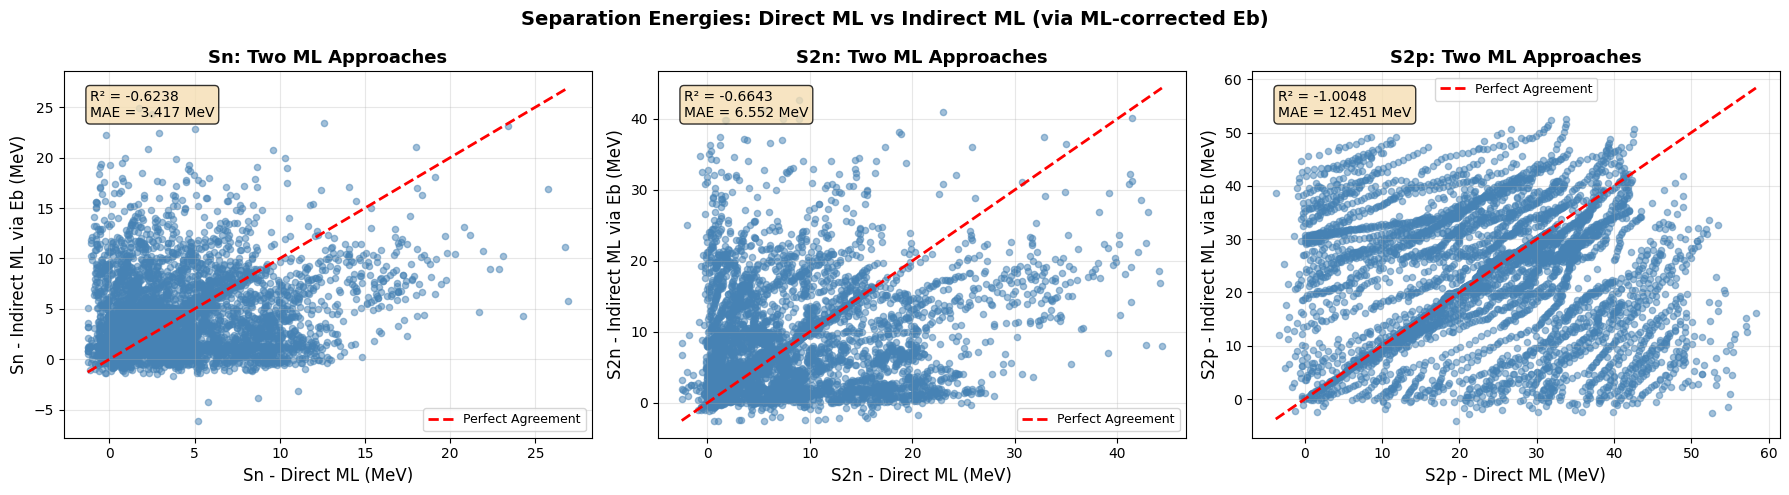

In [49]:
# VISUALIZATION: Direct ML vs Indirect ML Scatter Plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, sep_energy in enumerate(['Sn', 'S2n', 'S2p']):
    comparison_df = all_comparisons[sep_energy]
    
    # Use data from comparison_df
    x = comparison_df[f'{sep_energy}_DirectML']
    y = comparison_df[f'{sep_energy}_IndirectML']
    
    ax = axes[idx]
    ax.scatter(x, y, alpha=0.5, s=20, color='steelblue')
    ax.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', lw=2, label='Perfect Agreement')
    ax.set_xlabel(f'{sep_energy} - Direct ML (MeV)', fontsize=12)
    ax.set_ylabel(f'{sep_energy} - Indirect ML via Eb (MeV)', fontsize=12)
    ax.set_title(f'{sep_energy}: Two ML Approaches', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # Statistics
    r2 = r2_score(y, x)
    mae = np.abs(y - x).mean()
    ax.text(0.05, 0.95, f'R² = {r2:.4f}\nMAE = {mae:.3f} MeV', 
            transform=ax.transAxes, verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Separation Energies: Direct ML vs Indirect ML (via ML-corrected Eb)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

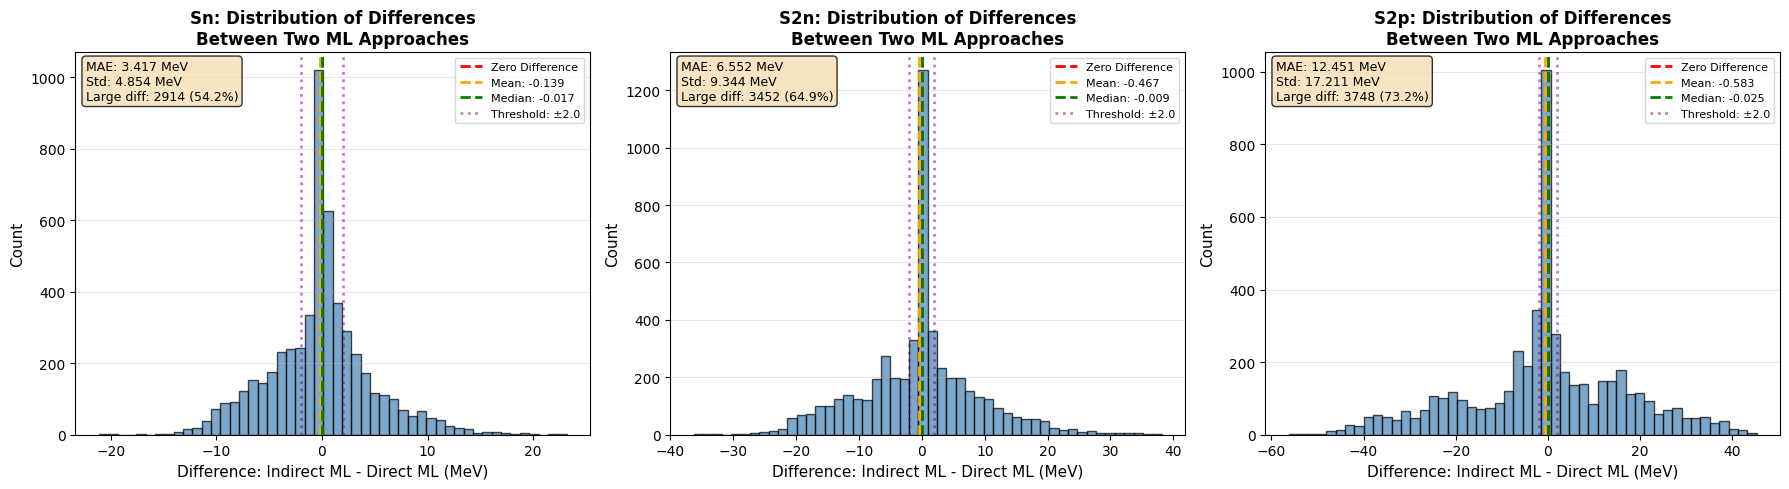

In [50]:
# VISUALIZATION: Distribution of Differences (Histograms)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, sep_energy in enumerate(['Sn', 'S2n', 'S2p']):
    comparison_df = all_comparisons[sep_energy]
    
    ax = axes[idx]
    
    # Histogram of differences
    ax.hist(comparison_df['Diff_Indirect_Direct'], bins=50, 
            alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add vertical lines for key statistics
    mean_diff = comparison_df['Diff_Indirect_Direct'].mean()
    median_diff = comparison_df['Diff_Indirect_Direct'].median()
    
    ax.axvline(0, color='red', linestyle='--', lw=2, label='Zero Difference')
    ax.axvline(mean_diff, color='orange', linestyle='--', lw=2, label=f'Mean: {mean_diff:.3f}')
    ax.axvline(median_diff, color='green', linestyle='--', lw=2, label=f'Median: {median_diff:.3f}')
    
    # Mark threshold
    ax.axvline(large_diff_threshold, color='purple', linestyle=':', lw=2, alpha=0.5, 
               label=f'Threshold: ±{large_diff_threshold}')
    ax.axvline(-large_diff_threshold, color='purple', linestyle=':', lw=2, alpha=0.5)
    
    ax.set_xlabel('Difference: Indirect ML - Direct ML (MeV)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{sep_energy}: Distribution of Differences\nBetween Two ML Approaches', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add text box with statistics
    mae = comparison_df['Abs_Diff'].mean()
    std = comparison_df['Diff_Indirect_Direct'].std()
    n_large = (comparison_df['Abs_Diff'] > large_diff_threshold).sum()
    pct_large = (n_large / len(comparison_df)) * 100
    
    textstr = f'MAE: {mae:.3f} MeV\nStd: {std:.3f} MeV\nLarge diff: {n_large} ({pct_large:.1f}%)'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

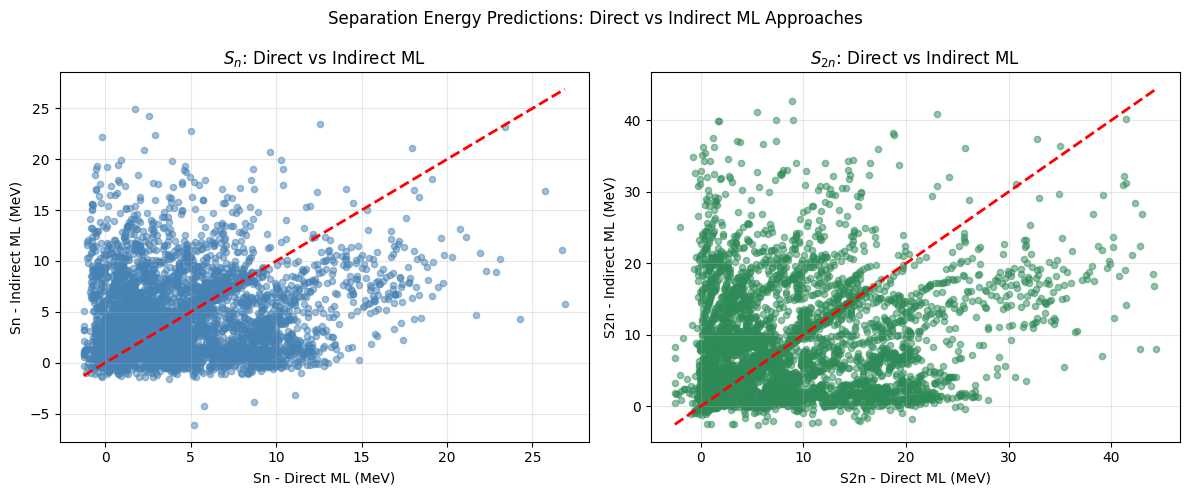

In [51]:
# ML Comparison Plots for LaTeX document
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Sn comparison
ax1 = axes[0]
comparison_df_sn = all_comparisons['Sn']
ax1.scatter(comparison_df_sn['Sn_DirectML'], comparison_df_sn['Sn_IndirectML'], 
            alpha=0.5, s=20, color='steelblue')
ax1.plot([comparison_df_sn['Sn_DirectML'].min(), comparison_df_sn['Sn_DirectML'].max()],
         [comparison_df_sn['Sn_DirectML'].min(), comparison_df_sn['Sn_DirectML'].max()], 
         'r--', lw=2)
ax1.set_xlabel('Sn - Direct ML (MeV)')
ax1.set_ylabel('Sn - Indirect ML (MeV)')
ax1.set_title('$S_n$: Direct vs Indirect ML')
ax1.grid(True, alpha=0.3)

# Plot 2: S2n comparison
ax2 = axes[1]
comparison_df_s2n = all_comparisons['S2n']
ax2.scatter(comparison_df_s2n['S2n_DirectML'], comparison_df_s2n['S2n_IndirectML'], 
            alpha=0.5, s=20, color='seagreen')
ax2.plot([comparison_df_s2n['S2n_DirectML'].min(), comparison_df_s2n['S2n_DirectML'].max()],
         [comparison_df_s2n['S2n_DirectML'].min(), comparison_df_s2n['S2n_DirectML'].max()], 
         'r--', lw=2)
ax2.set_xlabel('S2n - Direct ML (MeV)')
ax2.set_ylabel('S2n - Indirect ML (MeV)')
ax2.set_title('$S_{2n}$: Direct vs Indirect ML')
ax2.grid(True, alpha=0.3)

plt.suptitle('Separation Energy Predictions: Direct vs Indirect ML Approaches')
plt.tight_layout()
plt.show()

In [52]:
# SUMMARY TABLE: Comparison Across All Separation Energies

print("\n" + "="*80)
print("SUMMARY: ML Approach Consistency Across All Separation Energies")
print("="*80)

summary_data = []
for sep_energy in ['Sn', 'S2n', 'S2p']:
    comparison_df = all_comparisons[sep_energy]
    
    mae = comparison_df['Abs_Diff'].mean()
    median = comparison_df['Abs_Diff'].median()
    p90 = np.percentile(comparison_df['Abs_Diff'], 90)
    n_large = (comparison_df['Abs_Diff'] > large_diff_threshold).sum()
    pct_large = (n_large / len(comparison_df)) * 100
    
    # Experimental validation (if available)
    has_exp = comparison_df[f'{sep_energy}_Exp'].notna()
    if has_exp.sum() > 0:
        exp_data = comparison_df[has_exp]
        mae_direct = exp_data['Abs_Error_DirectML'].mean()
        mae_indirect = exp_data['Abs_Error_IndirectML'].mean()
        winner = 'Direct' if mae_direct < mae_indirect else 'Indirect'
    else:
        mae_direct = np.nan
        mae_indirect = np.nan
        winner = 'N/A'
    
    summary_data.append({
        'Quantity': sep_energy,
        'Total_Nuclei': len(comparison_df),
        'MAE_Diff (MeV)': mae,
        'Median_Diff (MeV)': median,
        '90th_%ile (MeV)': p90,
        f'>_{large_diff_threshold}_MeV (%)': pct_large,
        'With_Exp': has_exp.sum(),
        'Direct_MAE': mae_direct,
        'Indirect_MAE': mae_indirect,
        'Better_Method': winner
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("OVERALL ASSESSMENT")
print("="*80)

avg_mae = summary_df['MAE_Diff (MeV)'].mean()
avg_pct_large = summary_df[f'>_{large_diff_threshold}_MeV (%)'].mean()

if avg_mae < 0.5 and avg_pct_large < 5:
    print(" EXCELLENT: Both ML approaches are highly consistent across all quantities")
    print("    Predictions are reliable")
    print("    Low uncertainty in separation energy predictions")
elif avg_mae < 1.0 and avg_pct_large < 10:
    print("✓ GOOD: ML approaches show good consistency")
    print("    Minor differences between approaches")
    print("    Reasonable confidence in predictions")
elif avg_mae < 2.0 and avg_pct_large < 20:
    print(" MODERATE: ML approaches differ moderately")
    print("    Notable disagreements in some regions")
    print("    Predictions should be used with caution")
else:
    print(" SIGNIFICANT: Large differences between ML approaches")
    print("    High uncertainty in predictions")
    print("    More experimental validation needed")

print("="*80)

# Display the summary dataframe
summary_df


SUMMARY: ML Approach Consistency Across All Separation Energies

Quantity  Total_Nuclei  MAE_Diff (MeV)  Median_Diff (MeV)  90th_%ile (MeV)  >_2.0_MeV (%)  With_Exp  Direct_MAE  Indirect_MAE Better_Method
      Sn          5380        3.417171           2.366670         8.573213      54.163569      5378    3.367158      0.335321      Indirect
     S2n          5323        6.552056           4.787741        16.492170      64.850648      5321    6.521060      0.355525      Indirect
     S2p          5119       12.451043           8.770080        30.554138      73.217425      5117   12.422712      0.452519      Indirect

OVERALL ASSESSMENT
 SIGNIFICANT: Large differences between ML approaches
    High uncertainty in predictions
    More experimental validation needed


,Quantity,Total_Nuclei,MAE_Diff (MeV),Median_Diff (MeV),90th_%ile (MeV),>_2.0_MeV (%),With_Exp,Direct_MAE,Indirect_MAE,Better_Method
0,Sn,5380,3.417171,2.366670,8.573213,54.163569,5378,3.367158,0.335321,Indirect
1,S2n,5323,6.552056,4.787741,16.492170,64.850648,5321,6.521060,0.355525,Indirect
2,S2p,5119,12.451043,8.770080,30.554138,73.217425,5117,12.422712,0.452519,Indirect


## **Predict Charge Radius**

Nuclear charge radius follows well-established scaling laws:
 
 1. BASIC SCALING: Rch ∝ A^(1/3)
    (constant nuclear density assumption)
 
 2. DEFORMATION CORRECTION:
    Rch ≈ R₀ A^(1/3) (1 + (5/4π)β_t)
    
    where:
    - R₀ ≈ 1.2 fm (typical nuclear radius constant)
    - β_t = matter quadrupole deformation
    - Deformed nuclei have larger radii (prolate) or smaller (oblate)
 
 3. ADDITIONAL DEPENDENCIES:
    - Proton distribution (Rp)
    - Neutron skin effects (Rn - Rp)
    - Shell effects near magic numbers
 
 Steps:
 - Use Rch_cal as primary predictor (self-consistent DRHBc output)
 - Learn correction term: ΔR = Rch_exp - Rch_cal
 - Include A^(1/3), β_t, Rp, Rn as features

In [53]:
# Define features for radius imputation
radius_features = ['A', 'A_1/3', 'Rch_cal', 'beta t', 'beta p', 'Rp', 'Rn', 'Rm',
                   'Z', 'N', 'delta', 'dist_Z_magic', 'dist_N_magic']

In [54]:
# Split known vs unknown
known_mask_rch = df_final['Rch_exp'].notna()
df_rch_known = df_final[known_mask_rch].copy()
df_rch_unknown = df_final[~known_mask_rch].copy()

In [55]:
# Compute residual: ΔR = Rch_exp - Rch_cal
df_rch_known['delta_Rch'] = df_rch_known['Rch_exp'] - df_rch_known['Rch_cal']

In [56]:
# Prepare training data
X_rch_known = df_rch_known[radius_features].fillna(0)
y_rch_known = df_rch_known['delta_Rch']

In [57]:
# Train/test split
X_train_rch, X_test_rch, y_train_rch, y_test_rch = train_test_split(
    X_rch_known, y_rch_known, test_size=0.2, random_state=42
)

In [58]:
# Train models
models_rch = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
    'RF': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGB': XGBRegressor(n_estimators=200, random_state=42)
}

In [59]:
results_rch = {}    
for name, model in models_rch.items():
    model.fit(X_train_rch, y_train_rch)
    y_pred = model.predict(X_test_rch)
    results_rch[name] = {
        'model': model,  # ← ADD THIS LINE
        'MSE': mean_squared_error(y_test_rch, y_pred),
        'MAE': mean_absolute_error(y_test_rch, y_pred),
        'R2': r2_score(y_test_rch, y_pred)
    }

In [60]:
# Get predictions from ALL regression models on the test set
pred_dict_rch = {}
for name, result_dict in results_rch.items():  # Iterate over results_rch
    model = result_dict['model']  # Extract the stored model
    pred_dict_rch[name] = model.predict(X_test_rch)

In [61]:
# Display results in table
results_rch_df = pd.DataFrame({
    name: {k: v for k, v in result.items() if k != 'model'}  # Filter out 'model'
    for name, result in results_rch.items()
}).T
results_rch_df

,MSE,MAE,R2
Linear,0.000449,0.013965,0.620004
Ridge,0.000544,0.015805,0.539398
Lasso,0.000726,0.018137,0.385581
RF,0.000221,0.008760,0.813168
XGB,0.000258,0.008815,0.781291


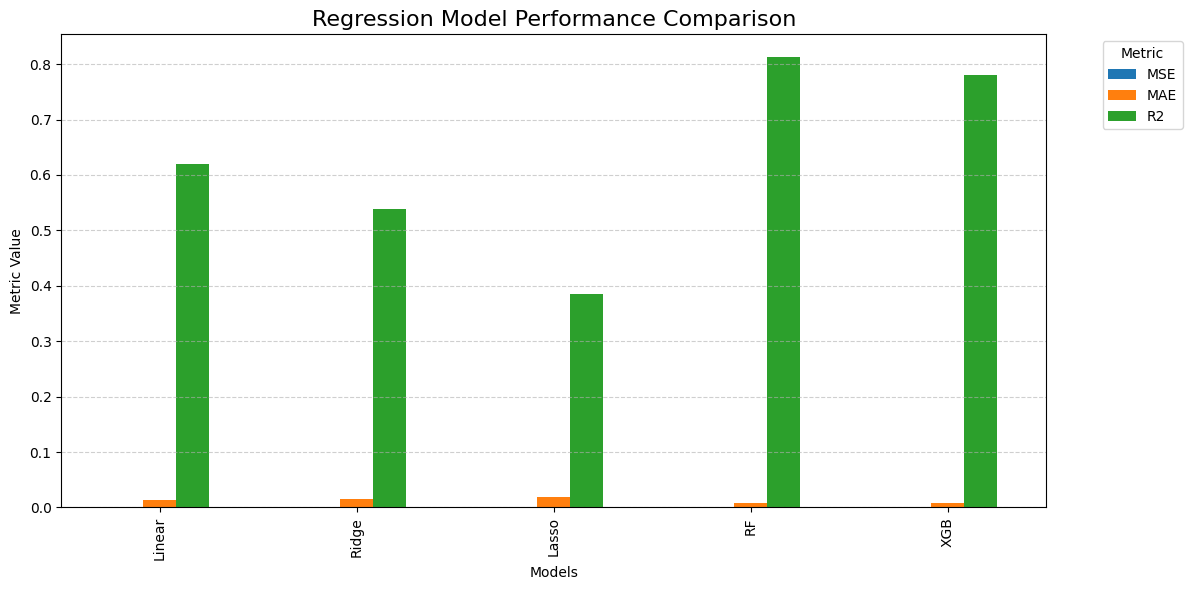

In [62]:
# Visualize model comparison
results_rch_plot = results_rch_df
results_rch_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Regression Model Performance Comparison", fontsize=16)
plt.ylabel("Metric Value")
plt.xlabel("Models")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [63]:
# Select best model (lowest MAE)
best_model_name_rch = results_rch_df['MSE'].idxmin()
best_model_rch = models_rch[best_model_name_rch]

In [64]:
# Predict for unknown nuclei
X_rch_unknown = df_rch_unknown[radius_features].fillna(0)
delta_Rch_pred = best_model_rch.predict(X_rch_unknown)

In [65]:
# Corrected Rch_exp = Rch_cal + ΔR
df_rch_unknown['Rch_exp_pred'] = df_rch_unknown['Rch_cal'] + delta_Rch_pred

In [66]:
# Update df_final
df_final['Rch_exp_pred'] = np.nan
df_final.loc[~known_mask_rch, 'Rch_exp_pred'] = df_rch_unknown['Rch_exp_pred'].values
df_final['Rch_exp_complete'] = df_final['Rch_exp'].fillna(df_final['Rch_exp_pred'])

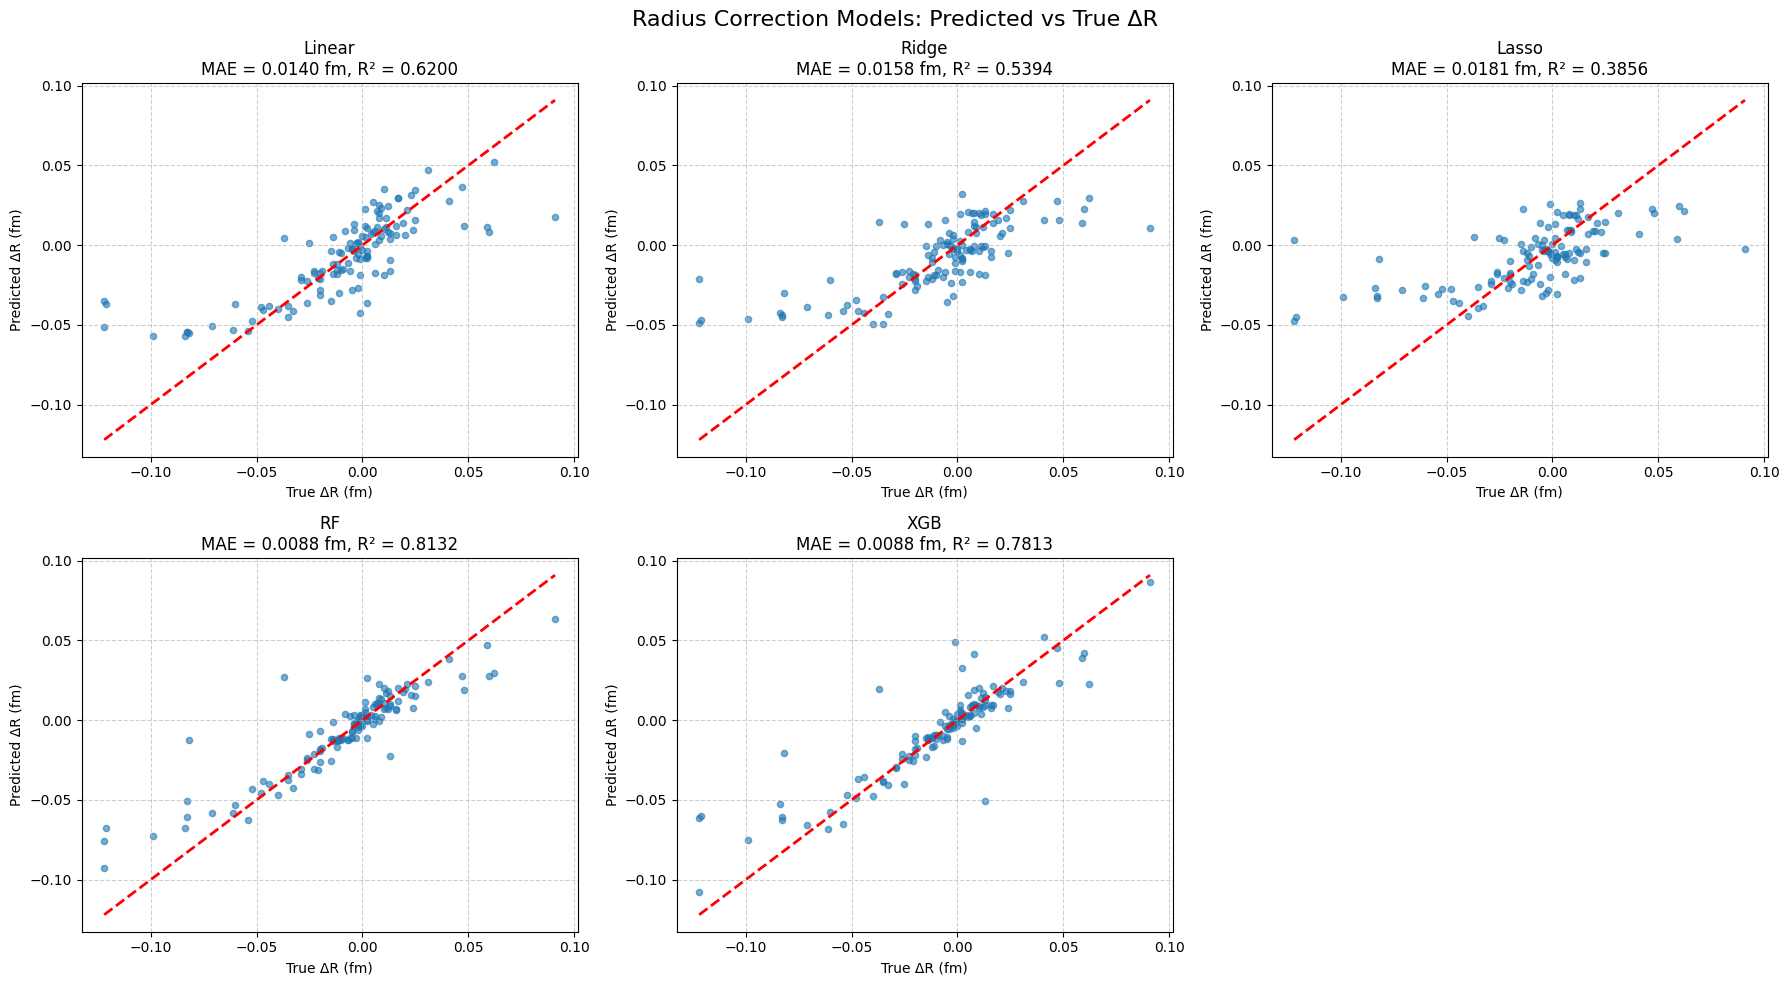

In [67]:
# Get predictions from all models for comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, result_dict) in enumerate(results_rch.items()):
    if i >= 5:  # We have 5 models
        axes[i].axis('off')
        continue
    
    model = result_dict['model']
    y_pred = model.predict(X_test_rch)
    
    ax = axes[i]
    ax.scatter(y_test_rch, y_pred, alpha=0.6, s=20)
    min_val = min(y_test_rch.min(), y_pred.min())
    max_val = max(y_test_rch.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_title(f"{name}\nMAE = {result_dict['MAE']:.4f} fm, R² = {result_dict['R2']:.4f}", 
                 fontsize=12)
    ax.set_xlabel("True ΔR (fm)")
    ax.set_ylabel("Predicted ΔR (fm)")
    ax.grid(True, linestyle="--", alpha=0.6)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle("Radius Correction Models: Predicted vs True ΔR", fontsize=16)
plt.tight_layout()
plt.show()

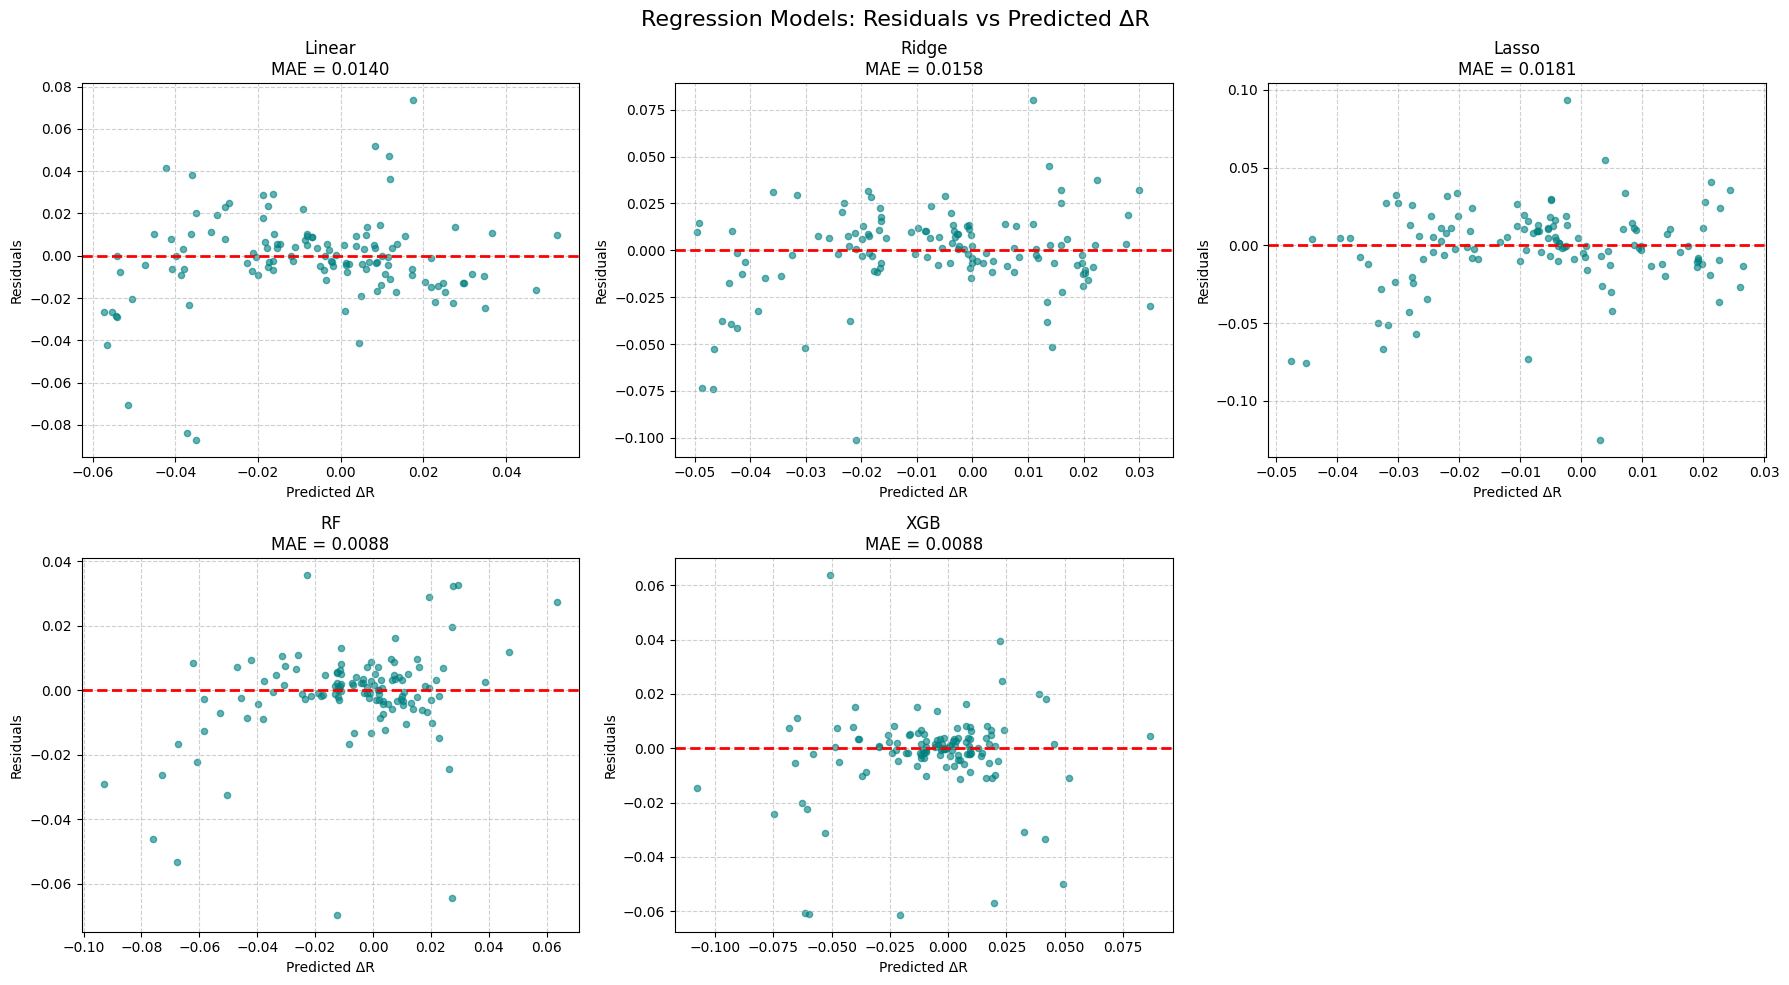

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(pred_dict_rch.items()):
    ax = axes[i]
    residuals = y_test_rch - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, s=20, color='teal')
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    ax.set_title(f"{name}\nMAE = {mean_absolute_error(y_test_rch, y_pred):.4f}", fontsize=12)
    ax.set_xlabel("Predicted ΔR")
    ax.set_ylabel("Residuals")
    ax.grid(True, linestyle="--", alpha=0.6)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle("Regression Models: Residuals vs Predicted ΔR", fontsize=16)
plt.tight_layout()
plt.show()

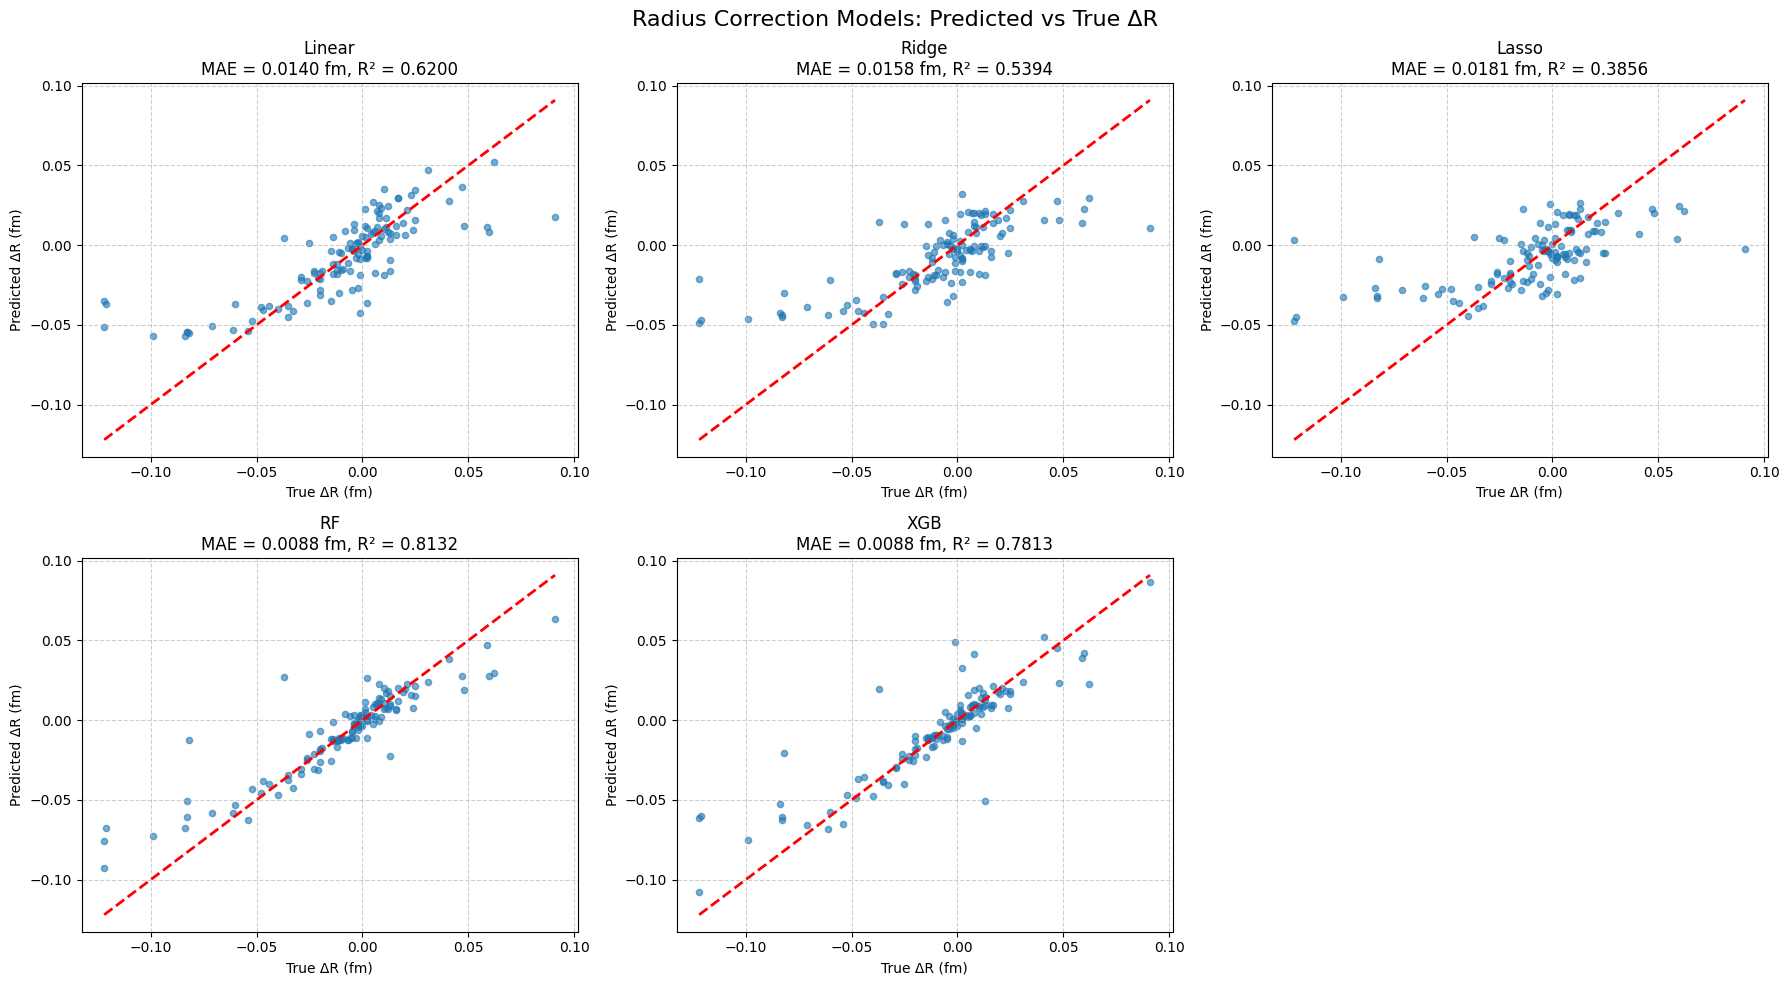

In [69]:
# Get predictions from all models for comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, result_dict) in enumerate(results_rch.items()):
    if i >= 5:  # We have 5 models
        axes[i].axis('off')
        continue
    
    model = result_dict['model']
    y_pred = model.predict(X_test_rch)
    
    ax = axes[i]
    ax.scatter(y_test_rch, y_pred, alpha=0.6, s=20)
    min_val = min(y_test_rch.min(), y_pred.min())
    max_val = max(y_test_rch.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_title(f"{name}\nMAE = {result_dict['MAE']:.4f} fm, R² = {result_dict['R2']:.4f}", 
                 fontsize=12)
    ax.set_xlabel("True ΔR (fm)")
    ax.set_ylabel("Predicted ΔR (fm)")
    ax.grid(True, linestyle="--", alpha=0.6)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle("Radius Correction Models: Predicted vs True ΔR", fontsize=16)
plt.tight_layout()
plt.show()

## **Final Data**

In [70]:
# Eb_exp_final: Use Eb_exp
df_final['Eb_exp_final'] = df_final['Eb_exp'].copy()

# Rch_exp_final: Use Rch_exp_complete
df_final['Rch_exp_final'] = df_final['Rch_exp_complete'].copy()

In [71]:
# Create final clean columns
# Define columns to keep (organized by category)
columns_to_keep = [
    # Nuclear identification
    'Z', 'N', 'A',
        
    # Final complete values
    'Eb_exp_final', 'Rch_exp_final',
    'Sn_final', 'S2n_final', 'S2p_final',
    # Physics-informed features
    'delta', 'A_1/3', 'dist_Z_magic', 'dist_N_magic', 'parity_N',
    
    # Theoretical predictions (DRHBc)
    'Eb_cal', 'Ebrot_cal', 'Rch_cal',
    'Rn', 'Rp', 'Rm',
    'beta n', 'beta p', 'beta t',
    'lam n', 'lam p', 'm^pi(N)'

]

# Create cleaned dataframe
df_final = df_final[columns_to_keep].copy()

In [72]:
# display final data
df_final.head()

,Z,N,A,Eb_exp_final,Rch_exp_final,Sn_final,S2n_final,S2p_final,delta,A_1/3,...,Rch_cal,Rn,Rp,Rm,beta n,beta p,beta t,lam n,lam p,m^pi(N)
0,8,4,12,58.58,3.00899,22.05,39.878849,-2.37,-0.333333,2.289428,...,3.022,2.329,2.915,2.734,0.000,0.000,0.000,-19.36,-2.15,0.0
1,8,5,13,75.55,2.85966,16.97,40.130000,-1.95,-0.230769,2.351335,...,2.880,2.378,2.767,2.624,0.129,0.036,0.072,-20.69,-3.55,-1.5
2,8,6,14,98.73,2.70942,23.18,40.150000,1.49,-0.142857,2.410142,...,2.758,2.250,2.639,2.480,0.000,0.000,0.000,-23.16,-1.18,0.0
3,8,7,15,111.96,2.71757,13.23,36.410000,9.93,-0.066667,2.466212,...,2.770,2.537,2.652,2.599,0.000,0.000,0.000,-14.21,-8.43,-0.5
4,8,8,16,127.62,2.69900,15.66,28.890000,20.45,0.000000,2.519842,...,2.768,2.626,2.650,2.638,0.000,0.000,0.000,-14.94,-11.21,0.0


In [73]:
df_final.isnull().sum()

Z                0
N                0
A                0
Eb_exp_final     0
Rch_exp_final    0
Sn_final         0
S2n_final        0
S2p_final        0
delta            0
A_1/3            0
dist_Z_magic     0
dist_N_magic     0
parity_N         0
Eb_cal           0
Ebrot_cal        0
Rch_cal          0
Rn               0
Rp               0
Rm               0
beta n           0
beta p           0
beta t           0
lam n            0
lam p            0
m^pi(N)          0
dtype: int64

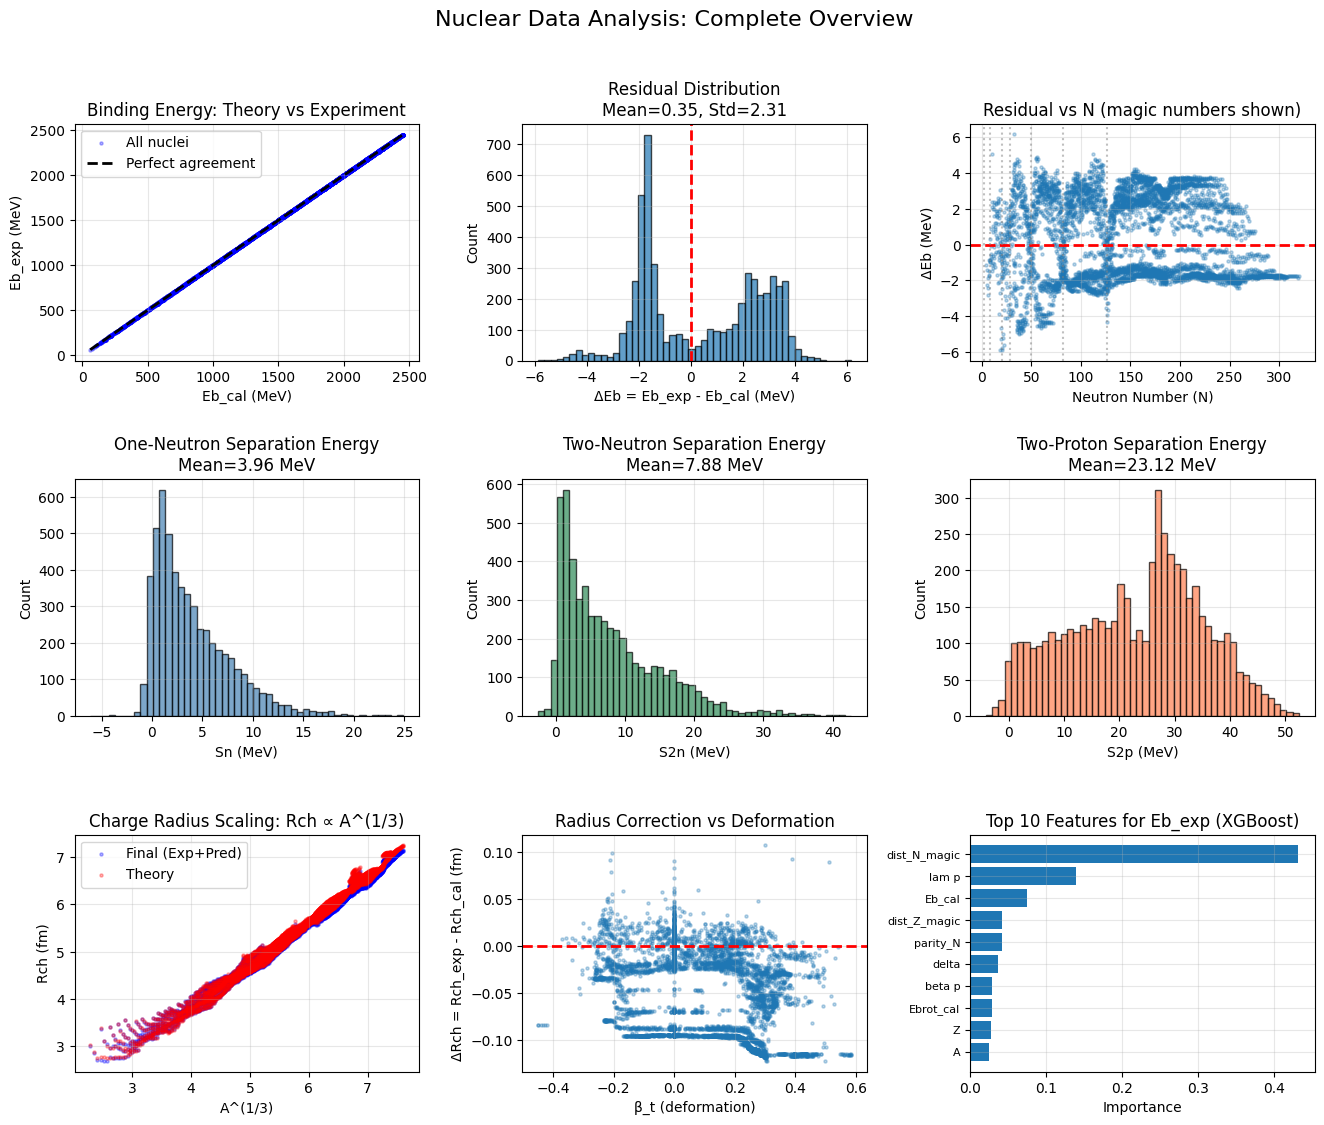

In [74]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.3)

# ===== ROW 1: BINDING ENERGY =====
# Plot 1: Eb_exp vs Eb_cal (without distinguishing known vs predicted)
ax1 = fig.add_subplot(gs[0, 0])
# SOLUTION: Just plot all points without distinguishing
ax1.scatter(df_final['Eb_cal'], df_final['Eb_exp_final'], alpha=0.3, s=5, color='blue', label='All nuclei')
ax1.plot([df_final['Eb_cal'].min(), df_final['Eb_cal'].max()],
         [df_final['Eb_cal'].min(), df_final['Eb_cal'].max()], 'k--', lw=2, label='Perfect agreement')
ax1.set_xlabel('Eb_cal (MeV)')
ax1.set_ylabel('Eb_exp (MeV)')
ax1.set_title('Binding Energy: Theory vs Experiment')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Residual distribution
ax2 = fig.add_subplot(gs[0, 1])
residuals = df_final['Eb_exp_final'] - df_final['Eb_cal']
ax2.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('ΔEb = Eb_exp - Eb_cal (MeV)')
ax2.set_ylabel('Count')
ax2.set_title(f'Residual Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}')
ax2.grid(alpha=0.3)

# Plot 3: Residual vs N
ax3 = fig.add_subplot(gs[0, 2])
residuals_by_N = df_final['Eb_exp_final'] - df_final['Eb_cal']
ax3.scatter(df_final['N'], residuals_by_N, alpha=0.3, s=5)
ax3.axhline(0, color='r', linestyle='--', lw=2)
# Mark magic numbers
for magic in magic_numbers:
    ax3.axvline(magic, color='gray', linestyle=':', alpha=0.5)
ax3.set_xlabel('Neutron Number (N)')
ax3.set_ylabel('ΔEb (MeV)')
ax3.set_title('Residual vs N (magic numbers shown)')
ax3.grid(alpha=0.3)

# ===== ROW 2: SEPARATION ENERGIES =====
# Plot 4: Sn distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df_final['Sn_final'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax4.set_xlabel('Sn (MeV)')
ax4.set_ylabel('Count')
ax4.set_title(f'One-Neutron Separation Energy\nMean={df_final["Sn_final"].mean():.2f} MeV')
ax4.grid(alpha=0.3)

# Plot 5: S2n distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df_final['S2n_final'], bins=50, edgecolor='black', alpha=0.7, color='seagreen')
ax5.set_xlabel('S2n (MeV)')
ax5.set_ylabel('Count')
ax5.set_title(f'Two-Neutron Separation Energy\nMean={df_final["S2n_final"].mean():.2f} MeV')
ax5.grid(alpha=0.3)

# Plot 6: S2p distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_final['S2p_final'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax6.set_xlabel('S2p (MeV)')
ax6.set_ylabel('Count')
ax6.set_title(f'Two-Proton Separation Energy\nMean={df_final["S2p_final"].mean():.2f} MeV')
ax6.grid(alpha=0.3)

# ===== ROW 3: CHARGE RADIUS =====
# Plot 7: Rch scaling law
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(df_final['A_1/3'], df_final['Rch_exp_final'], alpha=0.3, s=5, label='Final (Exp+Pred)', color='blue')
ax7.scatter(df_final['A_1/3'], df_final['Rch_cal'], alpha=0.3, s=5, label='Theory', color='red')
ax7.set_xlabel('A^(1/3)')
ax7.set_ylabel('Rch (fm)')
ax7.set_title('Charge Radius Scaling: Rch ∝ A^(1/3)')
ax7.legend()
ax7.grid(alpha=0.3)

# Plot 8: Rch residual vs deformation
ax8 = fig.add_subplot(gs[2, 1])
rch_residuals = df_final['Rch_exp_final'] - df_final['Rch_cal']
ax8.scatter(df_final['beta t'], rch_residuals, alpha=0.3, s=5)
ax8.axhline(0, color='r', linestyle='--', lw=2)
ax8.set_xlabel('β_t (deformation)')
ax8.set_ylabel('ΔRch = Rch_exp - Rch_cal (fm)')
ax8.set_title('Radius Correction vs Deformation')
ax8.grid(alpha=0.3)

# Plot 9: Feature importance (if available)
ax9 = fig.add_subplot(gs[2, 2])
if 'best_model' in locals() and hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-10:]
    ax9.barh(range(len(indices)), importances[indices])
    ax9.set_yticks(range(len(indices)))
    ax9.set_yticklabels([eb_features[i] for i in indices], fontsize=8)
    ax9.set_xlabel('Importance')
    ax9.set_title(f'Top 10 Features for Eb_exp ({best_model_name})')
else:
    ax9.text(0.5, 0.5, 'Feature importance\nnot available', 
             ha='center', va='center', fontsize=12)
    ax9.set_title('Feature Importance')
ax9.grid(alpha=0.3)

plt.suptitle('Nuclear Data Analysis: Complete Overview', fontsize=16, y=0.995)
plt.subplots_adjust(top=0.9)
plt.show()

In [75]:
# Exporting
output_file = "Data_completed_physics_final.csv"
df_final.to_csv(output_file, index=False)

### **Classification Models**

- Classify deformed (|$β_t$| > 0.1) vs spherical. Use same features.

In [76]:
# Select features to standardize (exclude categorical/binary)
features_no_leakage = ['Z', 'N', 'A', 
                       'Eb_cal', 'Ebrot_cal',  # Binding energy
                       'Rn', 'Rp', 'Rm', 'Rch_cal',  # Radii (indirect shape info)
                       'lam n', 'lam p',  # Fermi energies
                       'm^pi(N)',  # Angular momentum
                       'delta', 'A_1/3',  # Physics features
                       'dist_Z_magic', 'dist_N_magic', 'parity_N']  # Shell effects


In [77]:
# Create binary target: 1 if deformed, 0 if spherical
df_final['deformed'] = (abs(df_final['beta t']) > 0.1).astype(int)

class_counts = df_final['deformed'].value_counts()


In [78]:
# Split BEFORE scaling
X_class = df_final[features_no_leakage].fillna(0)
y_class = df_final['deformed'].values

X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.5, random_state=42, stratify=y_temp_c
)

In [79]:
# Standardize using TRAINING statistics only
scaler_class = StandardScaler()
X_train_c_scaled = scaler_class.fit_transform(X_train_c)
X_val_c_scaled = scaler_class.transform(X_val_c)
X_test_c_scaled = scaler_class.transform(X_test_c)

# Train models with class balancing
imbalance_ratio = (y_train_c == 0).sum() / (y_train_c == 1).sum()

In [80]:
# Models for classification
class_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, 
                                              class_weight='balanced'),
    'k-NN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42, 
                                           class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss',
                            scale_pos_weight=imbalance_ratio),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced')
}

In [81]:
# Train and evaluate
class_results = {}
for name, model in class_models.items():
    model.fit(X_train_c_scaled, y_train_c)
    y_pred_c = model.predict(X_val_c_scaled)
    
    acc = accuracy_score(y_val_c, y_pred_c)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val_c, y_pred_c, average='binary')
    
    class_results[name] = {
        'Accuracy': acc, 
        'Precision': prec, 
        'Recall': rec, 
        'F1': f1
    }

In [82]:
# Compare to baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_c_scaled, y_train_c)
baseline_acc = accuracy_score(y_val_c, dummy.predict(X_val_c_scaled))

# Feature importance (for best model)
best_model_name = max(class_results.items(), key=lambda x: x[1]['F1'])[0]
best_model = class_models[best_model_name]

/home/hazem/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


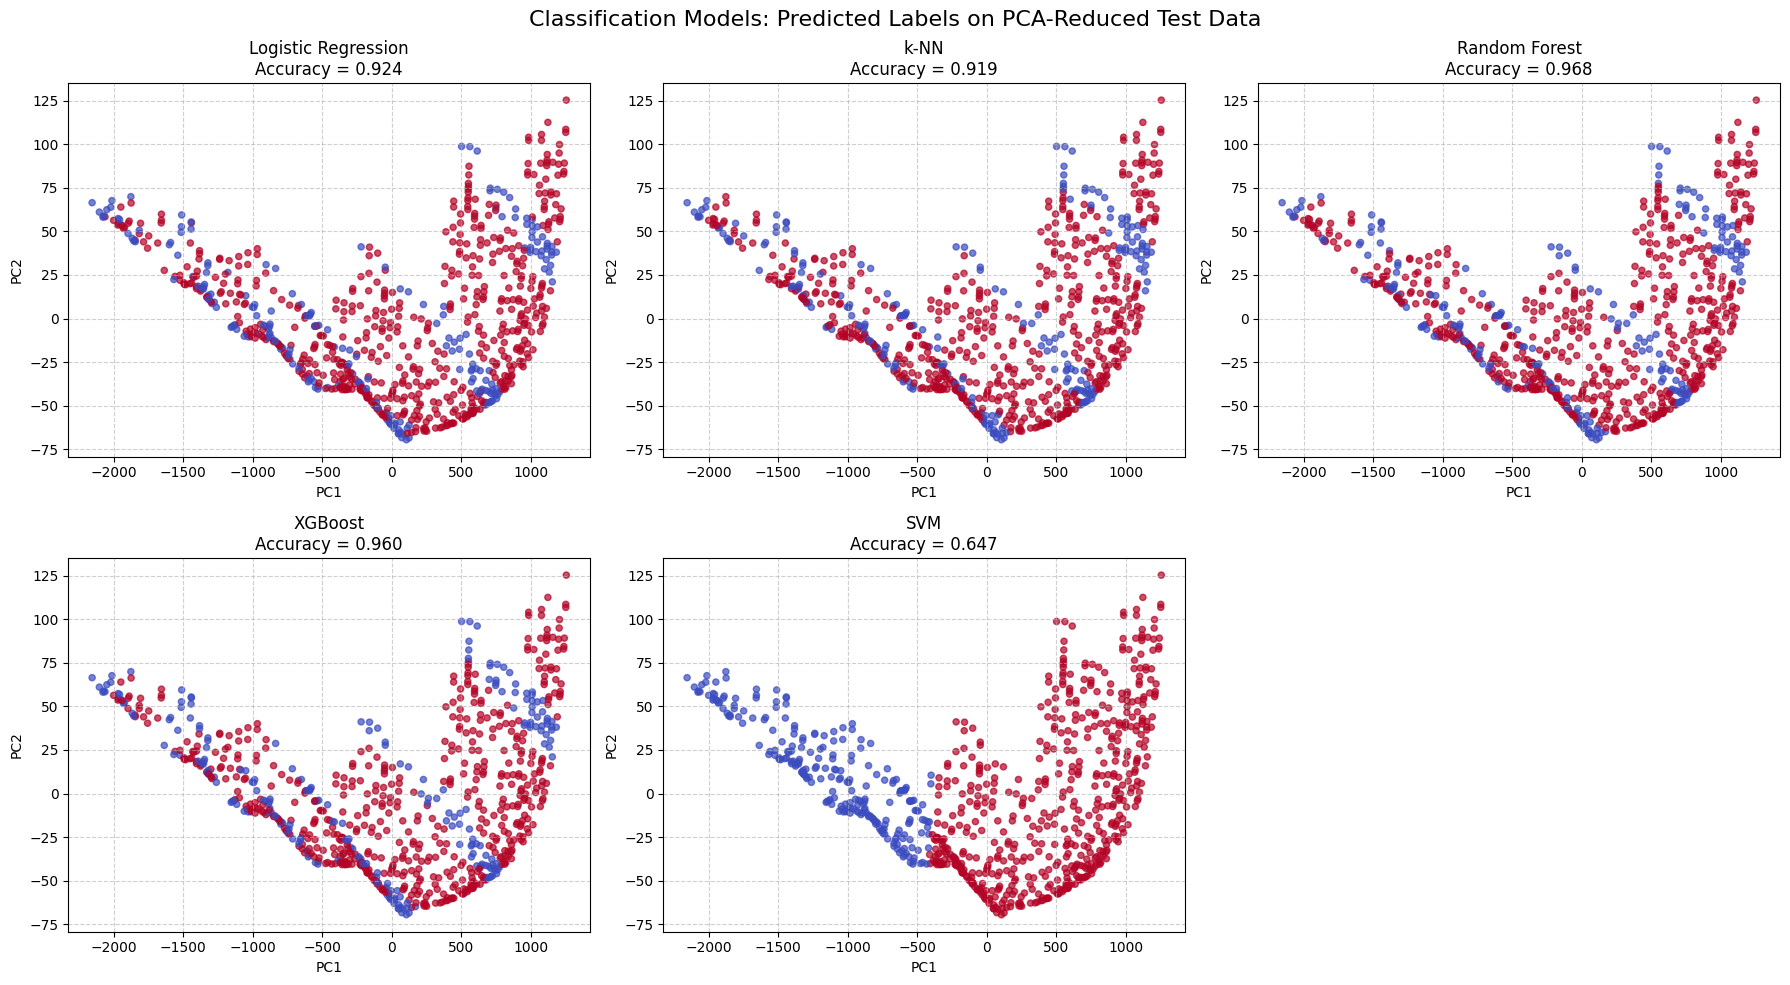

In [83]:
# Reduce features to 2D using PCA for visualization
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_test_c)  # Already standardized numpy array

# Train all classification models and predict
class_pred_dict = {}
class_prob_dict = {}

for name, model in class_models.items():
    # Fit on standardized numpy arrays (no feature names)
    model.fit(X_train_c, y_train_c)
    
    # Predict
    class_pred_dict[name] = model.predict(X_test_c)
    
    if hasattr(model, "predict_proba"):
        class_prob_dict[name] = model.predict_proba(X_test_c)[:, 1]
    else:
        class_prob_dict[name] = None

# Subplots: 2 rows x 3 columns for 5 models (one empty)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(class_pred_dict.items()):
    ax = axes[i]
    scatter = ax.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=y_pred, cmap='coolwarm', alpha=0.7, s=20)
    ax.set_title(f"{name}\nAccuracy = {accuracy_score(y_test_c, y_pred):.3f}", fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, linestyle="--", alpha=0.6)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle("Classification Models: Predicted Labels on PCA-Reduced Test Data", fontsize=16)
plt.tight_layout()
plt.show()

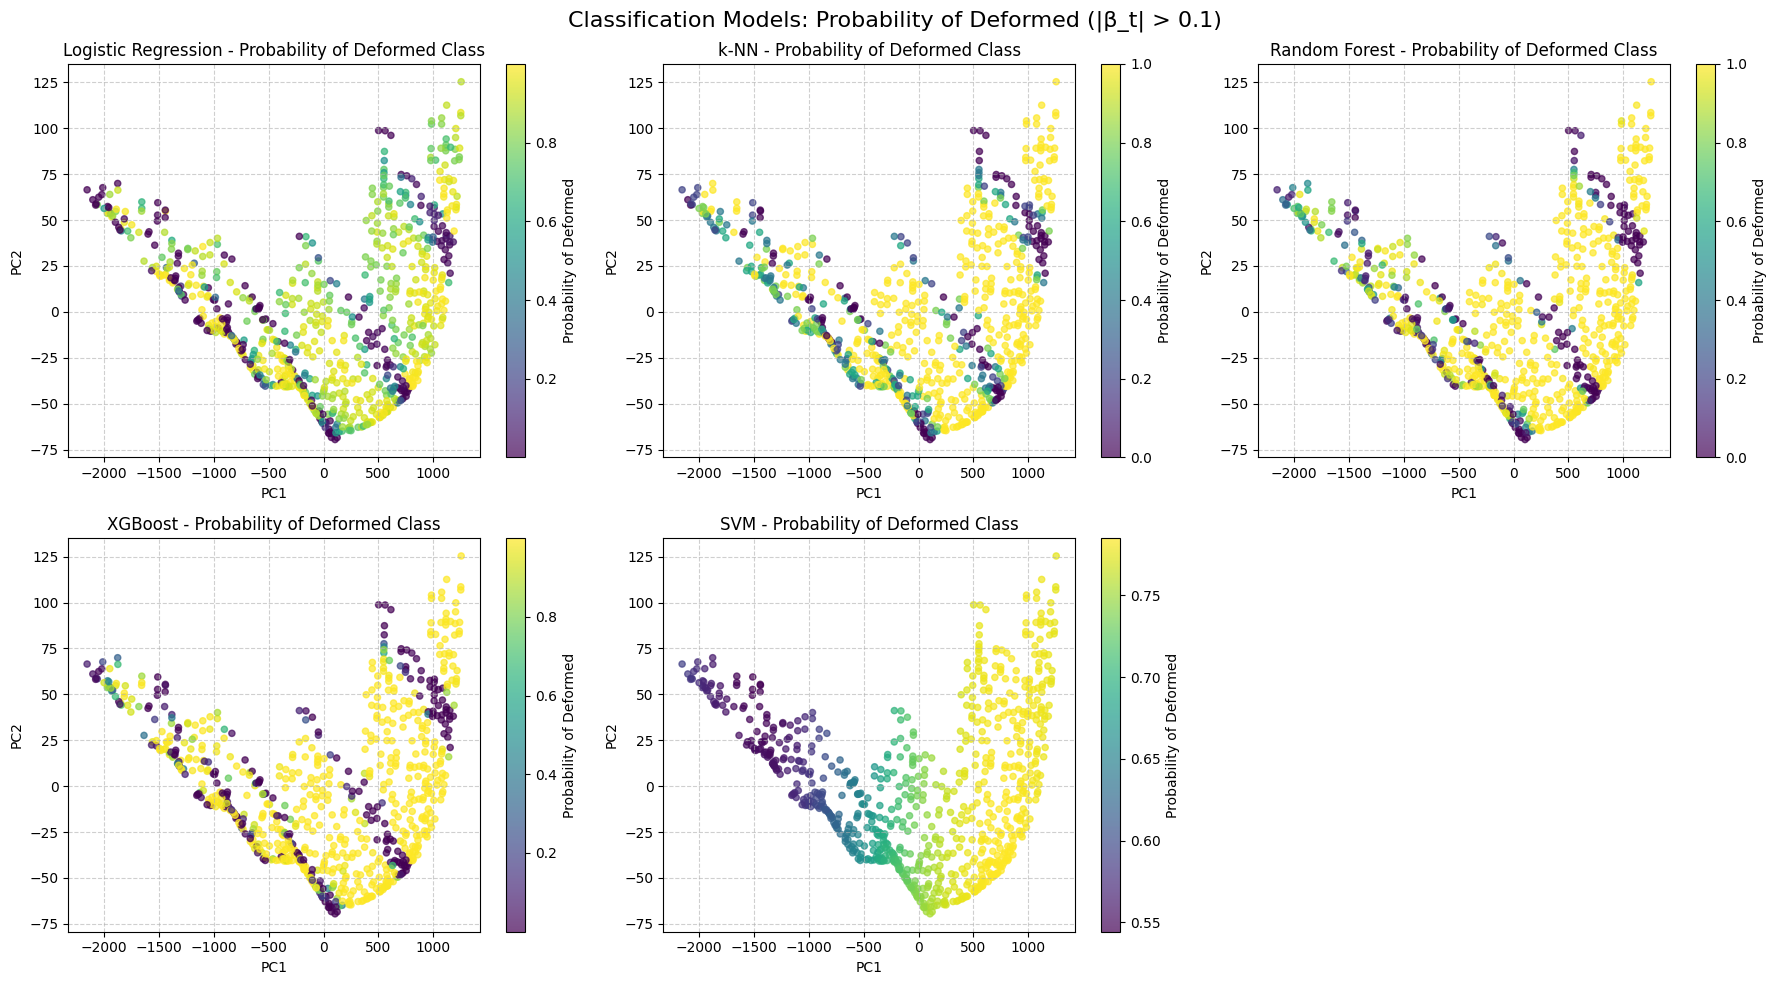

In [84]:
# Probability Visualization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Changed from 2x2 to 2x3
axes = axes.flatten()

for i, (name, probs) in enumerate(class_prob_dict.items()):
    ax = axes[i]
    if probs is not None:
        scatter = ax.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=probs, cmap='viridis', alpha=0.7, s=20)
        plt.colorbar(scatter, ax=ax, label='Probability of Deformed')
        ax.set_title(f"{name} - Probability of Deformed Class", fontsize=12)
    else:
        ax.text(0.5, 0.5, f"{name}\n(No probability output)", ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_title(name, fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, linestyle="--", alpha=0.6)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle("Classification Models: Probability of Deformed (|β_t| > 0.1)", fontsize=16)
plt.tight_layout()
plt.show()

In [85]:
class_results_df = pd.DataFrame(class_results).T
class_results_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.867647,0.962525,0.845754,0.900369
k-NN,0.898284,0.914430,0.944541,0.929241
Random Forest,0.962010,0.970690,0.975737,0.973207
XGBoost,0.955882,0.978761,0.958406,0.968476
SVM,0.781863,0.882917,0.797227,0.837887


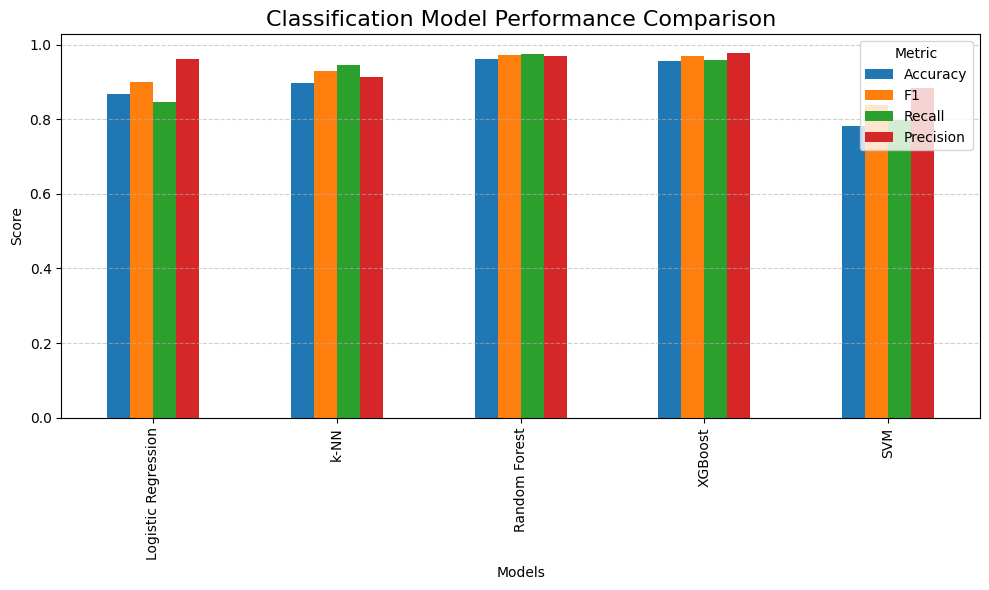

In [86]:
class_plot_df = class_results_df[['Accuracy', 'F1','Recall', 'Precision']]

class_plot_df.plot(kind="bar", figsize=(10,6))
plt.title("Classification Model Performance Comparison", fontsize=16)
plt.ylabel("Score")
plt.xlabel("Models")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

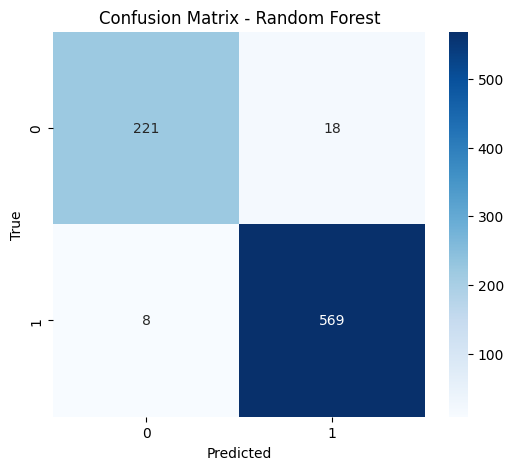

In [87]:
# Confusion Matrix and ROC for best class model
y_pred_test_c = best_model.predict(X_test_c)
conf_mat = confusion_matrix(y_test_c, y_pred_test_c)

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

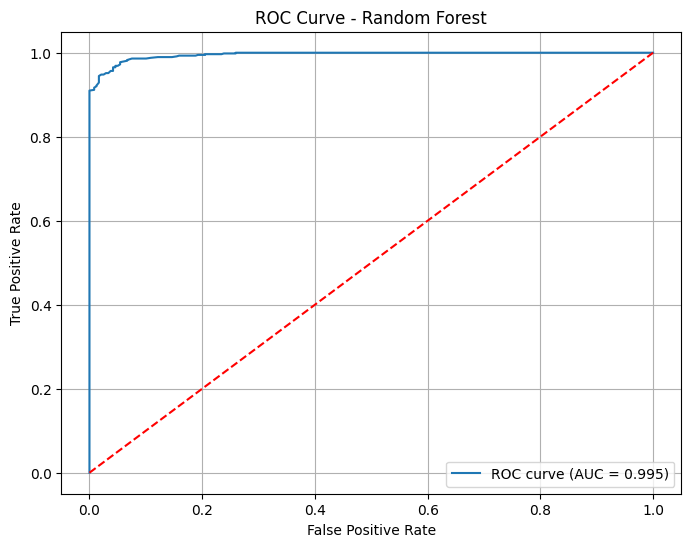

In [88]:
fpr, tpr, _ = roc_curve(y_test_c, best_model.predict_proba(X_test_c)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'r--')
plt.title(f'ROC Curve - {best_model_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

## **Unsupervised Learning: Pattern Discovery**

In [89]:
# Select key physical features for unsupervised analysis
unsup_features = ['Z', 'N', 'beta n', 'beta p', 'beta t', 'Rn', 'Rp', 'Rch_cal', 'lam n', 'lam p', 'Eb_cal', 'delta', 'dist_Z_magic', 'dist_N_magic']
X_unsup = df_final[unsup_features]

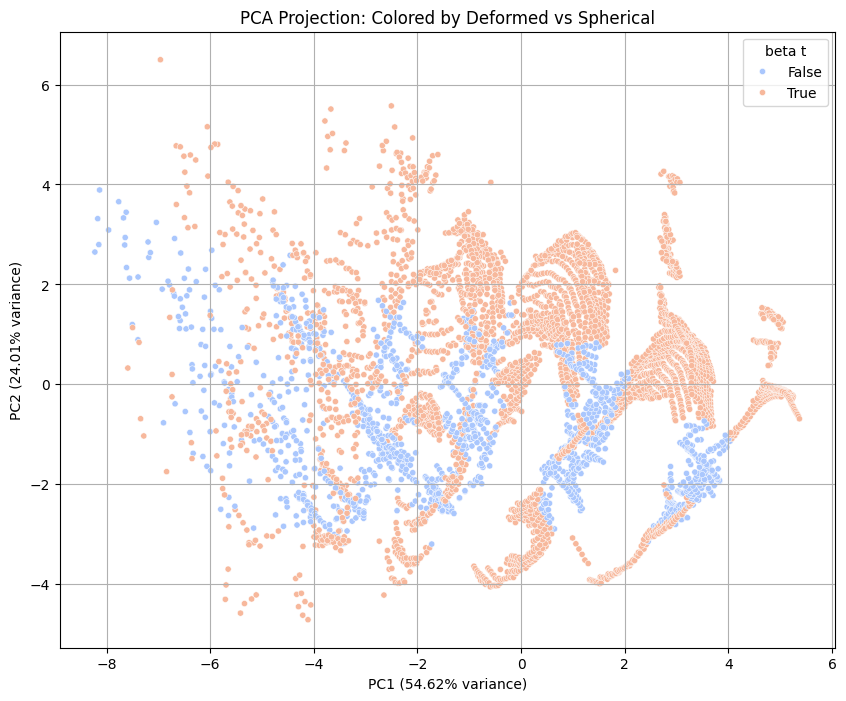

In [90]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_unsup))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=abs(df_final['beta t']) > 0.1, palette='coolwarm', s=20)
plt.title('PCA Projection: Colored by Deformed vs Spherical')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.grid(True)
plt.show()

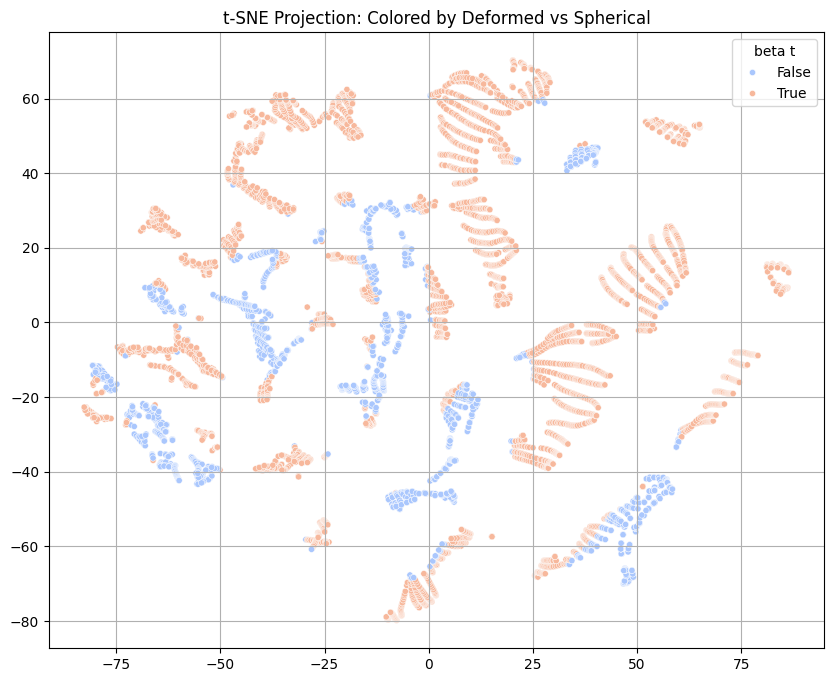

In [91]:
# t-SNE for non-linear visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(StandardScaler().fit_transform(X_unsup))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=abs(df_final['beta t']) > 0.1, palette='coolwarm', s=20)
plt.title('t-SNE Projection: Colored by Deformed vs Spherical')
plt.grid(True)
plt.show()

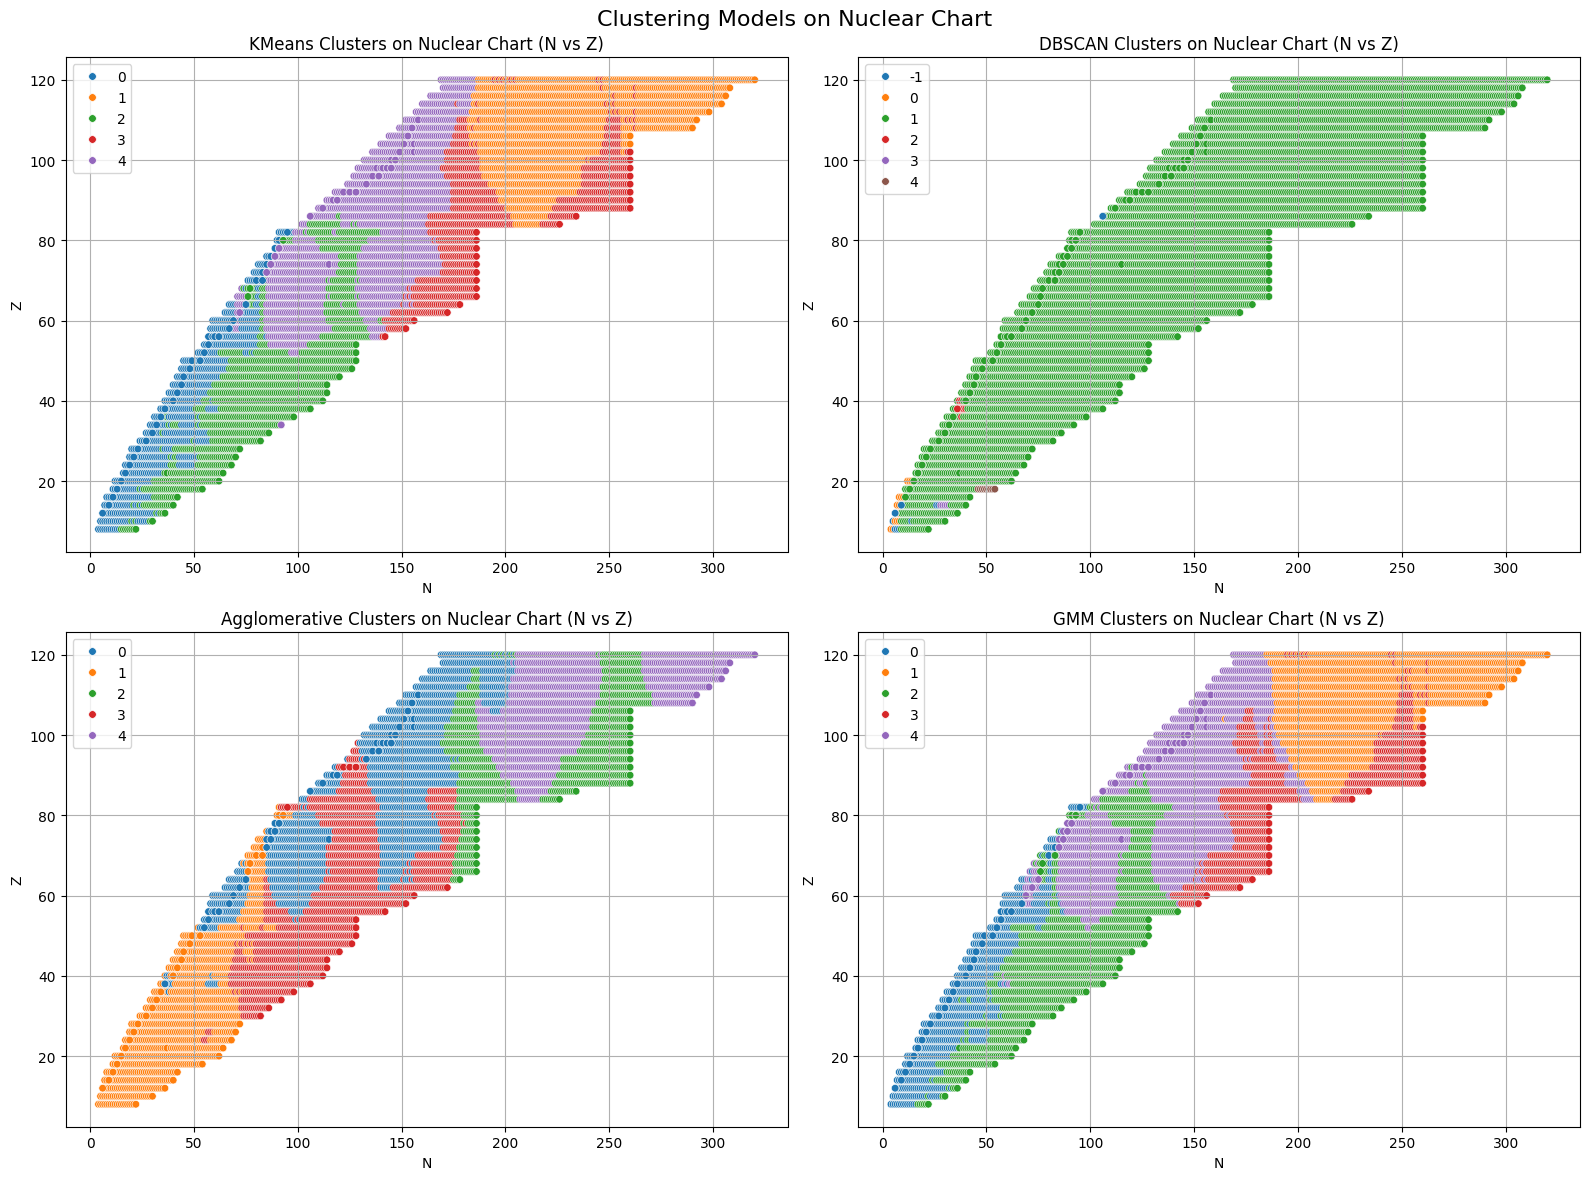

In [92]:
# List of clustering models
clustering_models = {
    'KMeans': KMeans(n_clusters=5, random_state=42),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=5, linkage='ward'),
    'GMM': GaussianMixture(n_components=5, random_state=42)
}

# Run over models and store clusters
clusters_dict = {}
for name, model in clustering_models.items():
    clusters = model.fit_predict(X_pca)
    df_final[f'cluster_{name.lower()}'] = clusters
    clusters_dict[name] = clusters

# Subplots for clusters on nuclear chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, clusters) in enumerate(clusters_dict.items()):
    ax = axes[i]
    sns.scatterplot(data=df_final, x='N', y='Z', hue=clusters, palette='tab10', s=30, ax=ax)
    ax.set_title(f'{name} Clusters on Nuclear Chart (N vs Z)')
    ax.grid(True)

plt.suptitle("Clustering Models on Nuclear Chart", fontsize=16)
plt.tight_layout()
plt.show()

In [93]:
# Compute silhouette scores for each method
sil_scores = {}
for name, clusters in clusters_dict.items():
    if len(set(clusters)) > 1:
        sil_scores[name] = silhouette_score(X_pca, clusters)
    else:
        sil_scores[name] = -1

sil_df = pd.DataFrame(list(sil_scores.items()), columns=['Method', 'Silhouette Score'])
sil_df = sil_df.sort_values('Silhouette Score', ascending=True)  # ascending for better horizontal

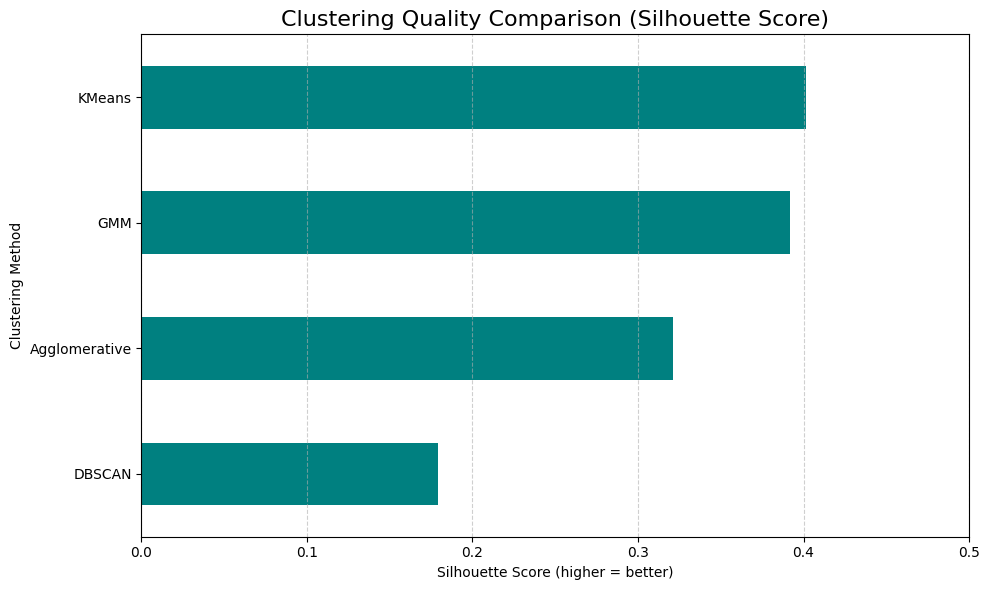

In [94]:
# Horizontal bar plot
sil_df.plot(x='Method', y='Silhouette Score', kind='barh', figsize=(10,6), color='teal', legend=False)
plt.title("Clustering Quality Comparison (Silhouette Score)", fontsize=16)
plt.xlabel("Silhouette Score (higher = better)")
plt.ylabel("Clustering Method")
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.xlim(0, 0.5)
plt.tight_layout()
plt.show()

## Pattern Discovery

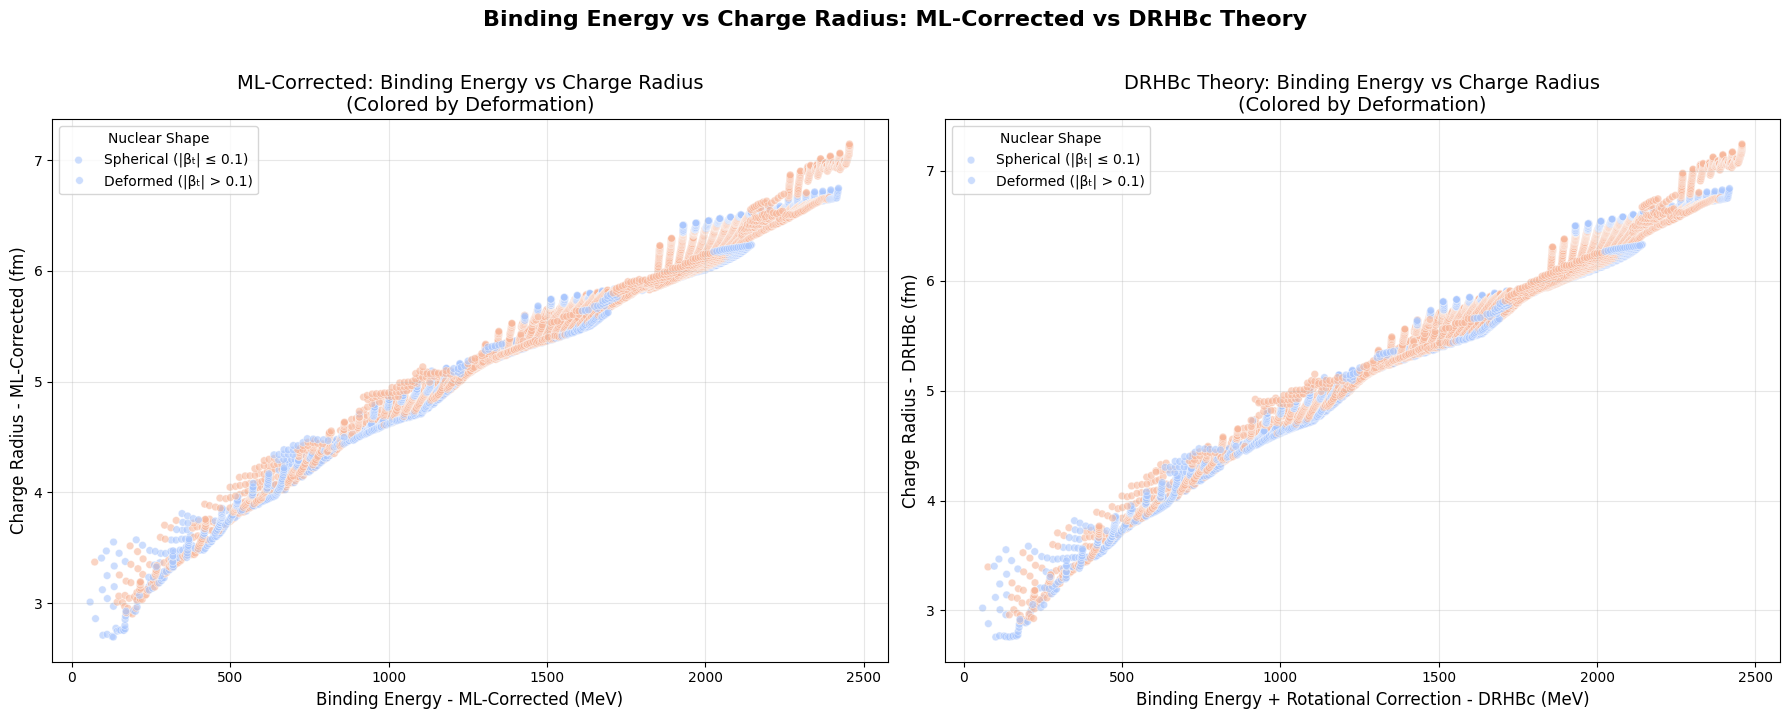

In [95]:
# Scatter plots: Binding Energy vs Charge Radius
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LEFT PLOT: Eb_exp_final vs Rch_exp_final (ML-Corrected)
ax1 = axes[0]
sns.scatterplot(data=df_final, x='Eb_exp_final', y='Rch_exp_final', 
                hue='deformed', palette='coolwarm', alpha=0.6, s=30, ax=ax1)
ax1.set_title('ML-Corrected: Binding Energy vs Charge Radius\n(Colored by Deformation)', fontsize=14)
ax1.set_xlabel('Binding Energy - ML-Corrected (MeV)', fontsize=12)
ax1.set_ylabel('Charge Radius - ML-Corrected (fm)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Nuclear Shape', labels=['Spherical (|βₜ| ≤ 0.1)', 'Deformed (|βₜ| > 0.1)'], fontsize=10)

# RIGHT PLOT: Ebrot_cal vs Rch_cal (Theoretical)
ax2 = axes[1]
sns.scatterplot(data=df_final, x='Ebrot_cal', y='Rch_cal', 
                hue='deformed', palette='coolwarm', alpha=0.6, s=30, ax=ax2)
ax2.set_title('DRHBc Theory: Binding Energy vs Charge Radius\n(Colored by Deformation)', fontsize=14)
ax2.set_xlabel('Binding Energy + Rotational Correction - DRHBc (MeV)', fontsize=12)
ax2.set_ylabel('Charge Radius - DRHBc (fm)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(title='Nuclear Shape', labels=['Spherical (|βₜ| ≤ 0.1)', 'Deformed (|βₜ| > 0.1)'], fontsize=10)

plt.suptitle('Binding Energy vs Charge Radius: ML-Corrected vs DRHBc Theory', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

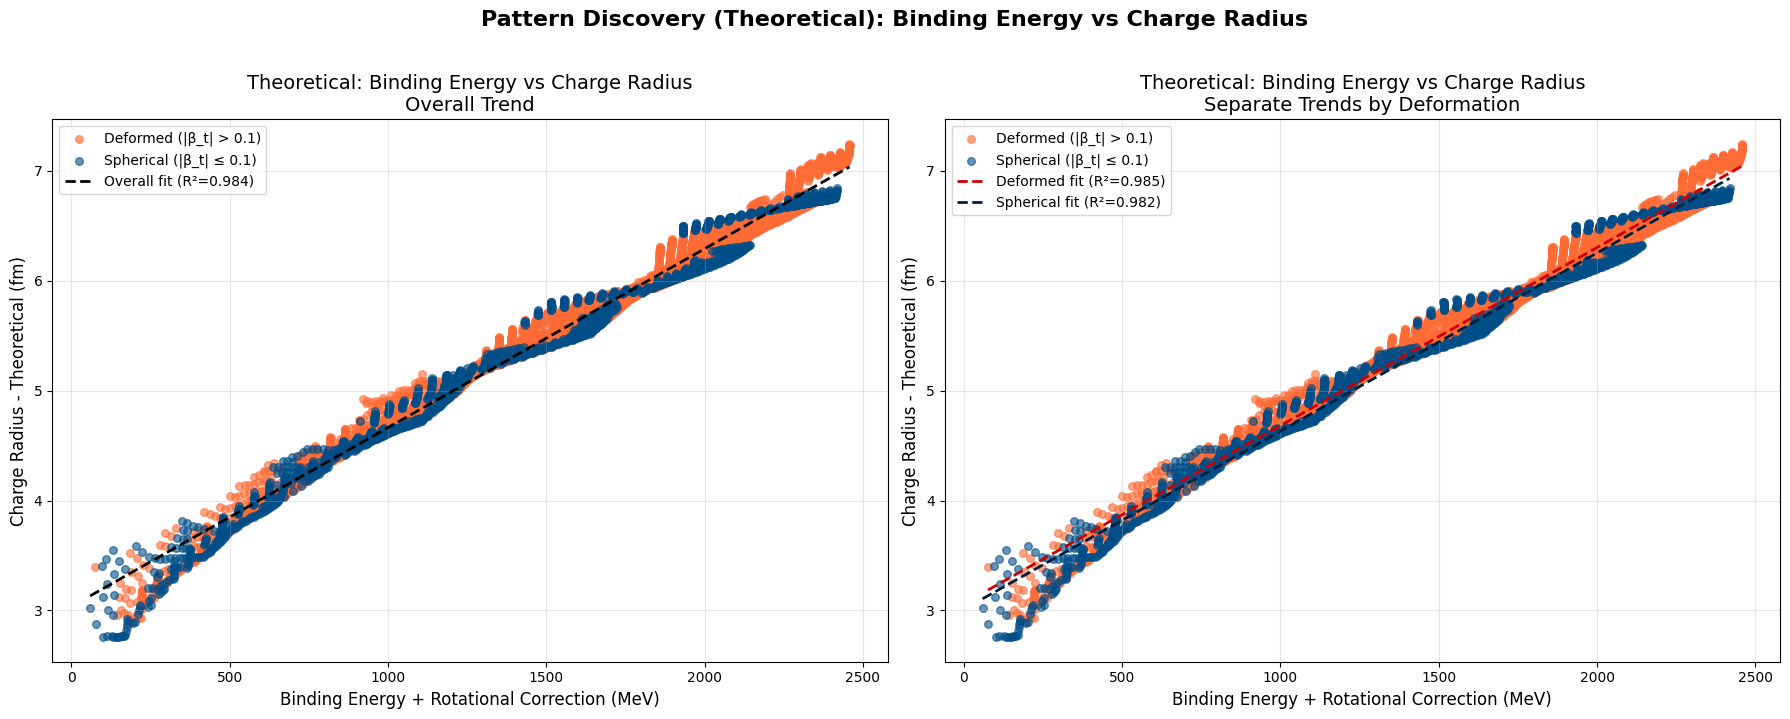

In [96]:
# THEORETICAL: Ebrot_cal vs Rch_cal Analysis with Regression Lines

# Create deformation masks
deformed_mask = df_final['beta t'].abs() > 0.1
spherical_mask = df_final['beta t'].abs() <= 0.1

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LEFT PLOT: Combined regression line
ax1 = axes[0]
ax1.scatter(df_final[deformed_mask]['Ebrot_cal'], 
            df_final[deformed_mask]['Rch_cal'],
            alpha=0.6, s=30, color='#FF6B35', label='Deformed (|β_t| > 0.1)')
ax1.scatter(df_final[spherical_mask]['Ebrot_cal'], 
            df_final[spherical_mask]['Rch_cal'],
            alpha=0.6, s=30, color='#004E89', label='Spherical (|β_t| ≤ 0.1)')

# Calculate overall regression line
x_theo = df_final['Ebrot_cal'].dropna()
y_theo = df_final['Rch_cal'].dropna()
common_idx_theo = x_theo.index.intersection(y_theo.index)
x_theo_clean = x_theo.loc[common_idx_theo]
y_theo_clean = y_theo.loc[common_idx_theo]

slope_theo, intercept_theo, r_value_theo, p_value_theo, std_err_theo = stats.linregress(x_theo_clean, y_theo_clean)

# Plot regression line
x_line_theo = np.linspace(x_theo_clean.min(), x_theo_clean.max(), 100)
y_line_theo = slope_theo * x_line_theo + intercept_theo
ax1.plot(x_line_theo, y_line_theo, 'k--', lw=2, label=f'Overall fit (R²={r_value_theo**2:.3f})')

ax1.set_title('Theoretical: Binding Energy vs Charge Radius\nOverall Trend', fontsize=14)
ax1.set_xlabel('Binding Energy + Rotational Correction (MeV)', fontsize=12)
ax1.set_ylabel('Charge Radius - Theoretical (fm)', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Separate regression lines
ax2 = axes[1]

# Split data by deformation
deformed_data_theo = df_final[deformed_mask]
spherical_data_theo = df_final[spherical_mask]

# Plot deformed nuclei
ax2.scatter(deformed_data_theo['Ebrot_cal'], deformed_data_theo['Rch_cal'], 
            alpha=0.6, s=30, color='#FF6B35', label='Deformed (|β_t| > 0.1)')

# Plot spherical nuclei
ax2.scatter(spherical_data_theo['Ebrot_cal'], spherical_data_theo['Rch_cal'], 
            alpha=0.6, s=30, color='#004E89', label='Spherical (|β_t| ≤ 0.1)')

# Regression for deformed
x_def_theo = deformed_data_theo['Ebrot_cal'].dropna()
y_def_theo = deformed_data_theo['Rch_cal'].dropna()
common_idx_def_theo = x_def_theo.index.intersection(y_def_theo.index)
x_def_theo_clean = x_def_theo.loc[common_idx_def_theo]
y_def_theo_clean = y_def_theo.loc[common_idx_def_theo]

if len(x_def_theo_clean) > 2:
    slope_def_theo, intercept_def_theo, r_def_theo, _, _ = stats.linregress(x_def_theo_clean, y_def_theo_clean)
    x_line_def_theo = np.linspace(x_def_theo_clean.min(), x_def_theo_clean.max(), 100)
    y_line_def_theo = slope_def_theo * x_line_def_theo + intercept_def_theo
    ax2.plot(x_line_def_theo, y_line_def_theo, color='#CC0000', linestyle='--', lw=2, 
             label=f'Deformed fit (R²={r_def_theo**2:.3f})')

# Regression for spherical
x_sph_theo = spherical_data_theo['Ebrot_cal'].dropna()
y_sph_theo = spherical_data_theo['Rch_cal'].dropna()
common_idx_sph_theo = x_sph_theo.index.intersection(y_sph_theo.index)
x_sph_theo_clean = x_sph_theo.loc[common_idx_sph_theo]
y_sph_theo_clean = y_sph_theo.loc[common_idx_sph_theo]

if len(x_sph_theo_clean) > 2:
    slope_sph_theo, intercept_sph_theo, r_sph_theo, _, _ = stats.linregress(x_sph_theo_clean, y_sph_theo_clean)
    x_line_sph_theo = np.linspace(x_sph_theo_clean.min(), x_sph_theo_clean.max(), 100)
    y_line_sph_theo = slope_sph_theo * x_line_sph_theo + intercept_sph_theo
    ax2.plot(x_line_sph_theo, y_line_sph_theo, color='#001F3F', linestyle='--', lw=2, 
             label=f'Spherical fit (R²={r_sph_theo**2:.3f})')

ax2.set_title('Theoretical: Binding Energy vs Charge Radius\nSeparate Trends by Deformation', fontsize=14)
ax2.set_xlabel('Binding Energy + Rotational Correction (MeV)', fontsize=12)
ax2.set_ylabel('Charge Radius - Theoretical (fm)', fontsize=12)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Pattern Discovery (Theoretical): Binding Energy vs Charge Radius', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [97]:
# Print regression statistics
print("="*70)
print("REGRESSION ANALYSIS: THEORETICAL (Ebrot_cal vs Rch_cal)")
print("="*70)

print(f"\n{'Overall Trend':-^70}")
print(f"  Equation: Rch = {slope_theo:.6f} × Eb + {intercept_theo:.4f}")
print(f"  R² = {r_value_theo**2:.4f}")
print(f"  p-value = {p_value_theo:.2e}")
print(f"  Sample size: {len(x_theo_clean)}")

if len(x_def_theo_clean) > 2:
    print(f"\n{'Deformed Nuclei (|β_t| > 0.1)':-^70}")
    print(f"  Equation: Rch = {slope_def_theo:.6f} × Eb + {intercept_def_theo:.4f}")
    print(f"  R² = {r_def_theo**2:.4f}")
    print(f"  Sample size: {len(x_def_theo_clean)}")
    
if len(x_sph_theo_clean) > 2:
    print(f"\n{'Spherical Nuclei (|β_t| ≤ 0.1)':-^70}")
    print(f"  Equation: Rch = {slope_sph_theo:.6f} × Eb + {intercept_sph_theo:.4f}")
    print(f"  R² = {r_sph_theo**2:.4f}")
    print(f"  Sample size: {len(x_sph_theo_clean)}")

if len(x_def_theo_clean) > 2 and len(x_sph_theo_clean) > 2:
    print(f"\n{'Comparison':-^70}")
    slope_diff_theo = abs(slope_def_theo - slope_sph_theo)
    slope_diff_pct_theo = (slope_diff_theo / abs(slope_sph_theo)) * 100
    print(f"  Slope difference: {slope_diff_theo:.6f} ({slope_diff_pct_theo:.2f}%)")
    print(f"  R² difference: {abs(r_def_theo**2 - r_sph_theo**2):.4f}")
    
    if slope_diff_pct_theo > 5:
        print(f"    Significant difference in slopes - deformed/spherical follow different trends!")
    else:
        print(f"   Similar slopes - deformation has minimal impact on Eb-Rch relationship")

print("="*70)

REGRESSION ANALYSIS: THEORETICAL (Ebrot_cal vs Rch_cal)

----------------------------Overall Trend-----------------------------
  Equation: Rch = 0.001628 × Eb + 3.0354
  R² = 0.9840
  p-value = 0.00e+00
  Sample size: 5437

--------------------Deformed Nuclei (|β_t| > 0.1)---------------------
  Equation: Rch = 0.001621 × Eb + 3.0615
  R² = 0.9847
  Sample size: 3845

--------------------Spherical Nuclei (|β_t| ≤ 0.1)--------------------
  Equation: Rch = 0.001622 × Eb + 3.0095
  R² = 0.9823
  Sample size: 1592

------------------------------Comparison------------------------------
  Slope difference: 0.000002 (0.09%)
  R² difference: 0.0024
   Similar slopes - deformation has minimal impact on Eb-Rch relationship


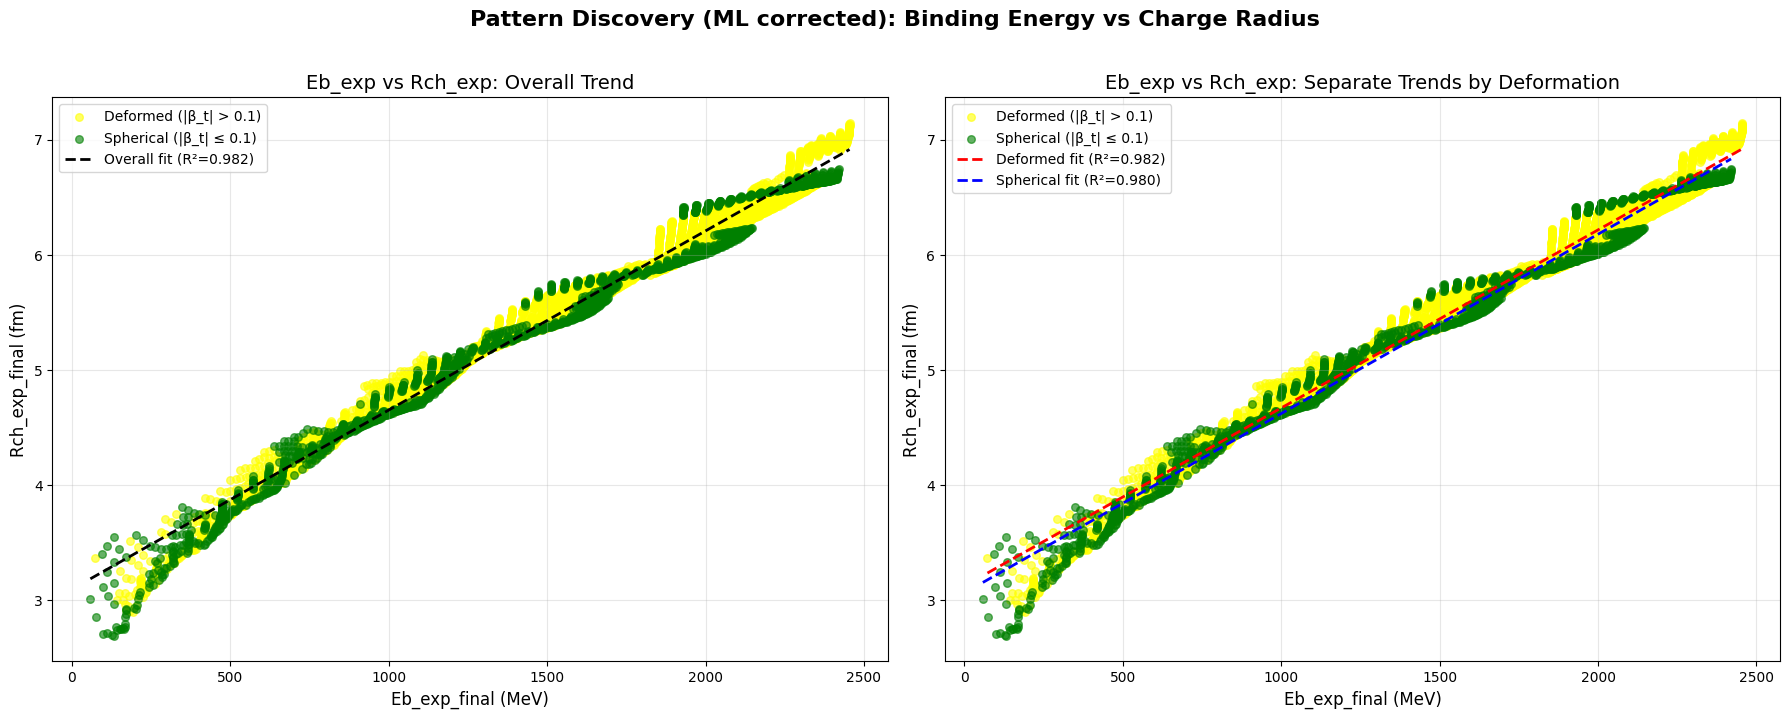

In [98]:
# Eb_exp vs Rch_exp Analysis with Regression Lines
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LEFT PLOT: Combined regression line
ax1 = axes[0]

# Scatter plot with deformation coloring
deformed_mask = df_final['deformed'] == 1
spherical_mask = df_final['deformed'] == 0

ax1.scatter(df_final[deformed_mask]['Eb_exp_final'], 
            df_final[deformed_mask]['Rch_exp_final'],
            alpha=0.6, s=30, color='yellow', label='Deformed (|β_t| > 0.1)')
ax1.scatter(df_final[spherical_mask]['Eb_exp_final'], 
            df_final[spherical_mask]['Rch_exp_final'],
            alpha=0.6, s=30, color='green', label='Spherical (|β_t| ≤ 0.1)')

# Calculate overall regression line
x = df_final['Eb_exp_final'].dropna()
y = df_final['Rch_exp_final'].dropna()
mask = x.notna() & y.notna()
x_clean = x[mask]
y_clean = y[mask]

# Align indices
common_idx = x_clean.index.intersection(y_clean.index)
x_clean = x_clean.loc[common_idx]
y_clean = y_clean.loc[common_idx]

slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)

# Plot regression line
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, 'k--', lw=2, label=f'Overall fit (R²={r_value**2:.3f})')

ax1.set_title('Eb_exp vs Rch_exp: Overall Trend', fontsize=14)
ax1.set_xlabel('Eb_exp_final (MeV)', fontsize=12)
ax1.set_ylabel('Rch_exp_final (fm)', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Separate regression lines
ax2 = axes[1]

# Split data by deformation
deformed_data = df_final[deformed_mask]
spherical_data = df_final[spherical_mask]

# Plot deformed nuclei
ax2.scatter(deformed_data['Eb_exp_final'], deformed_data['Rch_exp_final'], 
            alpha=0.6, s=30, color='yellow', label='Deformed (|β_t| > 0.1)')

# Plot spherical nuclei
ax2.scatter(spherical_data['Eb_exp_final'], spherical_data['Rch_exp_final'], 
            alpha=0.6, s=30, color='green', label='Spherical (|β_t| ≤ 0.1)')

# Regression for deformed
x_def = deformed_data['Eb_exp_final'].dropna()
y_def = deformed_data['Rch_exp_final'].dropna()
common_idx_def = x_def.index.intersection(y_def.index)
x_def_clean = x_def.loc[common_idx_def]
y_def_clean = y_def.loc[common_idx_def]

if len(x_def_clean) > 2:
    slope_def, intercept_def, r_def, _, _ = stats.linregress(x_def_clean, y_def_clean)
    x_line_def = np.linspace(x_def_clean.min(), x_def_clean.max(), 100)
    y_line_def = slope_def * x_line_def + intercept_def
    ax2.plot(x_line_def, y_line_def, 'r--', lw=2, 
             label=f'Deformed fit (R²={r_def**2:.3f})')

# Regression for spherical
x_sph = spherical_data['Eb_exp_final'].dropna()
y_sph = spherical_data['Rch_exp_final'].dropna()
common_idx_sph = x_sph.index.intersection(y_sph.index)
x_sph_clean = x_sph.loc[common_idx_sph]
y_sph_clean = y_sph.loc[common_idx_sph]

if len(x_sph_clean) > 2:
    slope_sph, intercept_sph, r_sph, _, _ = stats.linregress(x_sph_clean, y_sph_clean)
    x_line_sph = np.linspace(x_sph_clean.min(), x_sph_clean.max(), 100)
    y_line_sph = slope_sph * x_line_sph + intercept_sph
    ax2.plot(x_line_sph, y_line_sph, 'b--', lw=2, 
             label=f'Spherical fit (R²={r_sph**2:.3f})')

ax2.set_title('Eb_exp vs Rch_exp: Separate Trends by Deformation', fontsize=14)
ax2.set_xlabel('Eb_exp_final (MeV)', fontsize=12)
ax2.set_ylabel('Rch_exp_final (fm)', fontsize=12)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Pattern Discovery (ML corrected): Binding Energy vs Charge Radius', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [99]:
# Print regression statistics
print("="*70)
print("REGRESSION ANALYSIS: Eb_exp vs Rch_exp")
print("="*70)

print(f"\n{'Overall Trend':-^70}")
print(f"  Equation: Rch = {slope:.6f} × Eb + {intercept:.4f}")
print(f"  R² = {r_value**2:.4f}")
print(f"  p-value = {p_value:.2e}")
print(f"  Sample size: {len(x_clean)}")

if len(x_def_clean) > 2:
    print(f"\n{'Deformed Nuclei (|β_t| > 0.1)':-^70}")
    print(f"  Equation: Rch = {slope_def:.6f} × Eb + {intercept_def:.4f}")
    print(f"  R² = {r_def**2:.4f}")
    print(f"  Sample size: {len(x_def_clean)}")
    
if len(x_sph_clean) > 2:
    print(f"\n{'Spherical Nuclei (|β_t| ≤ 0.1)':-^70}")
    print(f"  Equation: Rch = {slope_sph:.6f} × Eb + {intercept_sph:.4f}")
    print(f"  R² = {r_sph**2:.4f}")
    print(f"  Sample size: {len(x_sph_clean)}")

if len(x_def_clean) > 2 and len(x_sph_clean) > 2:
    print(f"\n{'Comparison':-^70}")
    slope_diff = abs(slope_def - slope_sph)
    slope_diff_pct = (slope_diff / abs(slope_sph)) * 100
    print(f"  Slope difference: {slope_diff:.6f} ({slope_diff_pct:.2f}%)")
    print(f"  R² difference: {abs(r_def**2 - r_sph**2):.4f}")
    
    if slope_diff_pct > 5:
        print(f"    Significant difference in slopes - deformed/spherical follow different trends!")
    else:
        print(f"   Similar slopes - deformation has minimal impact on Eb-Rch relationship")

print("="*70)

REGRESSION ANALYSIS: Eb_exp vs Rch_exp

----------------------------Overall Trend-----------------------------
  Equation: Rch = 0.001556 × Eb + 3.0969
  R² = 0.9817
  p-value = 0.00e+00
  Sample size: 5437

--------------------Deformed Nuclei (|β_t| > 0.1)---------------------
  Equation: Rch = 0.001546 × Eb + 3.1252
  R² = 0.9820
  Sample size: 3845

--------------------Spherical Nuclei (|β_t| ≤ 0.1)--------------------
  Equation: Rch = 0.001558 × Eb + 3.0652
  R² = 0.9802
  Sample size: 1592

------------------------------Comparison------------------------------
  Slope difference: 0.000011 (0.72%)
  R² difference: 0.0018
   Similar slopes - deformation has minimal impact on Eb-Rch relationship


In [100]:
# OVERALL TRENDS COMPARISON

print("\n" + "="*80)
print("COMPARISON: DRHBc THEORY vs ML-CORRECTED PREDICTIONS")
print("="*80)
print("NOTE: 'Experimental' values include both measured data and ML predictions")
print("      This comparison evaluates ML correction effectiveness, not absolute accuracy")
print("="*80)

print(f"\n{'OVERALL TRENDS':-^80}")
print(f"{'Metric':<30} {'DRHBc Theory':<25} {'ML-Corrected':<25}")
print("-"*80)

print(f"{'Slope':<30} {slope_theo:>20.6f}     {slope:>20.6f}")
print(f"{'Intercept':<30} {intercept_theo:>20.4f}     {intercept:>20.4f}")
print(f"{'R² Score':<30} {r_value_theo**2:>20.4f}     {r_value**2:>20.4f}")
print(f"{'Sample Size':<30} {len(x_theo_clean):>20d}     {len(x_clean):>20d}")

# Calculate differences
slope_diff_overall = abs(slope_theo - slope)
slope_diff_pct_overall = (slope_diff_overall / abs(slope_theo)) * 100
r2_diff_overall = abs(r_value_theo**2 - r_value**2)

print(f"\n{'DIFFERENCES:':<30}")
print(f"{'Slope difference':<30} {slope_diff_overall:>20.6f} ({slope_diff_pct_overall:.2f}%)")
print(f"{'R² difference':<30} {r2_diff_overall:>20.4f}")
print(f"{'Intercept difference':<30} {abs(intercept_theo - intercept):>20.4f}")

# Interpretation
print(f"\n{'INTERPRETATION:':<30}")
if r2_diff_overall < 0.05:
    print("   ML corrections maintain similar correlation strength to raw theory")
else:
    if r_value**2 > r_value_theo**2:
        print(f"   ML corrections IMPROVE correlation (ΔR² = +{r_value**2 - r_value_theo**2:.4f})")
    else:
        print(f"   ML corrections REDUCE correlation (ΔR² = -{r_value_theo**2 - r_value**2:.4f})")

if slope_diff_pct_overall < 5:
    print("   ML corrections preserve Eb-Rch relationship")
else:
    print(f"   ML corrections modify Eb-Rch relationship ({slope_diff_pct_overall:.2f}% change)")

print("="*80)


COMPARISON: DRHBc THEORY vs ML-CORRECTED PREDICTIONS
NOTE: 'Experimental' values include both measured data and ML predictions
      This comparison evaluates ML correction effectiveness, not absolute accuracy

---------------------------------OVERALL TRENDS---------------------------------
Metric                         DRHBc Theory              ML-Corrected             
--------------------------------------------------------------------------------
Slope                                      0.001628                 0.001556
Intercept                                    3.0354                   3.0969
R² Score                                     0.9840                   0.9817
Sample Size                                    5437                     5437

DIFFERENCES:                  
Slope difference                           0.000072 (4.42%)
R² difference                                0.0023
Intercept difference                         0.0615

INTERPRETATION:               
   ML c

In [101]:
# DEFORMED NUCLEI COMPARISON

if len(x_def_theo_clean) > 2 and len(x_def_clean) > 2:
    print("\n" + "="*80)
    print(f"{'DEFORMED NUCLEI (|β_t| > 0.1)':-^80}")
    print(f"{'Metric':<30} {'DRHBc Theory':<25} {'ML-Corrected':<25}")
    print("-"*80)
    
    print(f"{'Slope':<30} {slope_def_theo:>20.6f}     {slope_def:>20.6f}")
    print(f"{'Intercept':<30} {intercept_def_theo:>20.4f}     {intercept_def:>20.4f}")
    print(f"{'R² Score':<30} {r_def_theo**2:>20.4f}     {r_def**2:>20.4f}")
    print(f"{'Sample Size':<30} {len(x_def_theo_clean):>20d}     {len(x_def_clean):>20d}")
    
    # Calculate differences
    slope_diff_def = abs(slope_def_theo - slope_def)
    slope_diff_pct_def = (slope_diff_def / abs(slope_def_theo)) * 100
    r2_diff_def = abs(r_def_theo**2 - r_def**2)
    
    print(f"\n{'DIFFERENCES:':<30}")
    print(f"{'Slope difference':<30} {slope_diff_def:>20.6f} ({slope_diff_pct_def:.2f}%)")
    print(f"{'R² difference':<30} {r2_diff_def:>20.4f}")
    
    print(f"\n{'INTERPRETATION:':<30}")
    if r_def**2 > r_def_theo**2:
        improvement = r_def**2 - r_def_theo**2
        print(f"   ML improves correlation in deformed region (ΔR² = +{improvement:.4f})")
    else:
        decline = r_def_theo**2 - r_def**2
        print(f"   ML reduces correlation in deformed region (ΔR² = -{decline:.4f})")
    
    if slope_diff_pct_def < 5:
        print(f"   ML preserves physics relationships in deformed nuclei")
    else:
        print(f"   ML significantly modifies deformed nuclei trends ({slope_diff_pct_def:.2f}%)")
    
    print("="*80)
else:
    print("\n Insufficient data for deformed nuclei comparison")


-------------------------DEFORMED NUCLEI (|β_t| > 0.1)--------------------------
Metric                         DRHBc Theory              ML-Corrected             
--------------------------------------------------------------------------------
Slope                                      0.001621                 0.001546
Intercept                                    3.0615                   3.1252
R² Score                                     0.9847                   0.9820
Sample Size                                    3845                     3845

DIFFERENCES:                  
Slope difference                           0.000074 (4.59%)
R² difference                                0.0027

INTERPRETATION:               
   ML reduces correlation in deformed region (ΔR² = -0.0027)
   ML preserves physics relationships in deformed nuclei


In [102]:
# SPHERICAL NUCLEI COMPARISON

if len(x_sph_theo_clean) > 2 and len(x_sph_clean) > 2:
    print("\n" + "="*80)
    print(f"{'SPHERICAL NUCLEI (|β_t| ≤ 0.1)':-^80}")
    print(f"{'Metric':<30} {'DRHBc Theory':<25} {'ML-Corrected':<25}")
    print("-"*80)
    
    print(f"{'Slope':<30} {slope_sph_theo:>20.6f}     {slope_sph:>20.6f}")
    print(f"{'Intercept':<30} {intercept_sph_theo:>20.4f}     {intercept_sph:>20.4f}")
    print(f"{'R² Score':<30} {r_sph_theo**2:>20.4f}     {r_sph**2:>20.4f}")
    print(f"{'Sample Size':<30} {len(x_sph_theo_clean):>20d}     {len(x_sph_clean):>20d}")
    
    # Calculate differences
    slope_diff_sph = abs(slope_sph_theo - slope_sph)
    slope_diff_pct_sph = (slope_diff_sph / abs(slope_sph_theo)) * 100
    r2_diff_sph = abs(r_sph_theo**2 - r_sph**2)
    
    print(f"\n{'DIFFERENCES:':<30}")
    print(f"{'Slope difference':<30} {slope_diff_sph:>20.6f} ({slope_diff_pct_sph:.2f}%)")
    print(f"{'R² difference':<30} {r2_diff_sph:>20.4f}")
    
    print(f"\n{'INTERPRETATION:':<30}")
    if r_sph**2 > r_sph_theo**2:
        improvement = r_sph**2 - r_sph_theo**2
        print(f"   ML improves correlation in spherical region (ΔR² = +{improvement:.4f})")
    else:
        decline = r_sph_theo**2 - r_sph**2
        print(f"   ML reduces correlation in spherical region (ΔR² = -{decline:.4f})")
    
    if slope_diff_pct_sph < 5:
        print(f"   ML preserves physics relationships in spherical nuclei")
    else:
        print(f"   ML significantly modifies spherical nuclei trends ({slope_diff_pct_sph:.2f}%)")
    
    print("="*80)
else:
    print("\n Insufficient data for spherical nuclei comparison")


-------------------------SPHERICAL NUCLEI (|β_t| ≤ 0.1)-------------------------
Metric                         DRHBc Theory              ML-Corrected             
--------------------------------------------------------------------------------
Slope                                      0.001622                 0.001558
Intercept                                    3.0095                   3.0652
R² Score                                     0.9823                   0.9802
Sample Size                                    1592                     1592

DIFFERENCES:                  
Slope difference                           0.000065 (3.99%)
R² difference                                0.0021

INTERPRETATION:               
   ML reduces correlation in spherical region (ΔR² = -0.0021)
   ML preserves physics relationships in spherical nuclei


In [103]:
# DEFORMATION EFFECT COMPARISON

if len(x_def_theo_clean) > 2 and len(x_sph_theo_clean) > 2 and len(x_def_clean) > 2 and len(x_sph_clean) > 2:
    print("\n" + "="*80)
    print(f"{'DEFORMATION EFFECT: DEFORMED vs SPHERICAL':-^80}")
    print(f"{'Metric':<30} {'DRHBc Theory':<25} {'ML-Corrected':<25}")
    print("-"*80)
    
    # Slope differences
    slope_def_sph_diff_theo = abs(slope_def_theo - slope_sph_theo)
    slope_def_sph_pct_theo = (slope_def_sph_diff_theo / abs(slope_sph_theo)) * 100
    
    slope_def_sph_diff_ml = abs(slope_def - slope_sph)
    slope_def_sph_pct_ml = (slope_def_sph_diff_ml / abs(slope_sph)) * 100
    
    print(f"{'Def vs Sph slope diff':<30} {slope_def_sph_diff_theo:>20.6f}     {slope_def_sph_diff_ml:>20.6f}")
    print(f"{'Percentage difference':<30} {slope_def_sph_pct_theo:>19.2f}%     {slope_def_sph_pct_ml:>19.2f}%")
    
    # R² differences
    r2_def_sph_diff_theo = abs(r_def_theo**2 - r_sph_theo**2)
    r2_def_sph_diff_ml = abs(r_def**2 - r_sph**2)
    
    print(f"{'Def vs Sph R² diff':<30} {r2_def_sph_diff_theo:>20.4f}     {r2_def_sph_diff_ml:>20.4f}")
    
    print(f"\n{'INTERPRETATION:':<30}")
    # Check if ML preserves deformation effects
    deformation_effect_preserved = abs(slope_def_sph_pct_theo - slope_def_sph_pct_ml) < 5
    
    if deformation_effect_preserved:
        print("   ML PRESERVES deformation effects from theory")
        print(f"    Both show ~{slope_def_sph_pct_theo:.1f}% difference between deformed/spherical")
    else:
        print("   ML MODIFIES deformation effects from theory")
        print(f"    Theory: {slope_def_sph_pct_theo:.1f}% difference")
        print(f"    ML-corrected: {slope_def_sph_pct_ml:.1f}% difference")
    
    # Which shows stronger deformation sensitivity?
    if slope_def_sph_pct_ml > slope_def_sph_pct_theo:
        enhancement = slope_def_sph_pct_ml - slope_def_sph_pct_theo
        print(f"   ML ENHANCES deformation sensitivity by {enhancement:.1f}%")
    elif slope_def_sph_pct_ml < slope_def_sph_pct_theo:
        reduction = slope_def_sph_pct_theo - slope_def_sph_pct_ml
        print(f"   ML REDUCES deformation sensitivity by {reduction:.1f}%")
    else:
        print(f"   ML maintains identical deformation sensitivity")
    
    print("="*80)
else:
    print("\n Insufficient data for deformation effect comparison")


-------------------DEFORMATION EFFECT: DEFORMED vs SPHERICAL--------------------
Metric                         DRHBc Theory              ML-Corrected             
--------------------------------------------------------------------------------
Def vs Sph slope diff                      0.000002                 0.000011
Percentage difference                         0.09%                    0.72%
Def vs Sph R² diff                           0.0024                   0.0018

INTERPRETATION:               
   ML PRESERVES deformation effects from theory
    Both show ~0.1% difference between deformed/spherical
   ML ENHANCES deformation sensitivity by 0.6%


In [104]:
# OVERALL ASSESSMENT OF ML CORRECTIONS

print("\n" + "="*80)
print(f"{'ML CORRECTION ASSESSMENT':-^80}")
print("="*80)
print("Evaluating how ML corrections affect physical relationships")
print("-"*80)

# Track improvements vs degradations
improvements = 0
degradations = 0
preservations = 0

# Check 1: Overall correlation
print("\n1. Overall Correlation:")
if abs(r2_diff_overall) < 0.01:
    preservations += 1
    print(f"   ○ PRESERVED (ΔR² = {r2_diff_overall:.4f})")
elif r_value**2 > r_value_theo**2:
    improvements += 1
    improvement = r_value**2 - r_value_theo**2
    print(f"    IMPROVED (ΔR² = +{improvement:.4f})")
else:
    degradations += 1
    decline = r_value_theo**2 - r_value**2
    print(f"   ✗ REDUCED (ΔR² = -{decline:.4f})")

# Check 2: Overall slope
print("\n2. Overall Slope:")
if slope_diff_pct_overall < 2:
    preservations += 1
    print(f"   ○ PRESERVED ({slope_diff_pct_overall:.2f}% change)")
elif slope_diff_pct_overall < 5:
    improvements += 1
    print(f"    MINOR ADJUSTMENT ({slope_diff_pct_overall:.2f}% change)")
else:
    degradations += 1
    print(f"   ✗ SIGNIFICANT CHANGE ({slope_diff_pct_overall:.2f}% change)")

# Check 3: Deformed region (if available)
if len(x_def_theo_clean) > 2 and len(x_def_clean) > 2:
    print("\n3. Deformed Region:")
    if abs(r2_diff_def) < 0.01:
        preservations += 1
        print(f"   ○ PRESERVED (ΔR² = {r2_diff_def:.4f})")
    elif r_def**2 > r_def_theo**2:
        improvements += 1
        improvement = r_def**2 - r_def_theo**2
        print(f"    IMPROVED (ΔR² = +{improvement:.4f})")
    else:
        degradations += 1
        decline = r_def_theo**2 - r_def**2
        print(f"   ✗ REDUCED (ΔR² = -{decline:.4f})")

# Check 4: Spherical region (if available)
if len(x_sph_theo_clean) > 2 and len(x_sph_clean) > 2:
    print("\n4. Spherical Region:")
    if abs(r2_diff_sph) < 0.01:
        preservations += 1
        print(f"   ○ PRESERVED (ΔR² = {r2_diff_sph:.4f})")
    elif r_sph**2 > r_sph_theo**2:
        improvements += 1
        improvement = r_sph**2 - r_sph_theo**2
        print(f"    IMPROVED (ΔR² = +{improvement:.4f})")
    else:
        degradations += 1
        decline = r_sph_theo**2 - r_sph**2
        print(f"   ✗ REDUCED (ΔR² = -{decline:.4f})")

# Overall summary
total_checks = improvements + degradations + preservations
print("\n" + "="*80)
print(f"SUMMARY: {total_checks} aspects evaluated")
print("-"*80)
print(f" Improvements:  {improvements}")
print(f"○ Preserved:     {preservations}")
print(f"✗ Degradations:  {degradations}")
print("="*80)

# Overall conclusion
if improvements + preservations >= 0.75 * total_checks:
    print("\n CONCLUSION: ML corrections are PHYSICS-CONSISTENT")
    print("   ML successfully learns and preserves underlying physical relationships")
elif improvements >= degradations:
    print("\n  CONCLUSION: ML corrections are MODERATELY EFFECTIVE")
    print("   ML improves some aspects but may overfit or introduce artifacts in others")
else:
    print("\n CONCLUSION: ML corrections may DISTORT physics")
    print("   Significant modifications suggest overfitting or inconsistent corrections")

print("="*80)


----------------------------ML CORRECTION ASSESSMENT----------------------------
Evaluating how ML corrections affect physical relationships
--------------------------------------------------------------------------------

1. Overall Correlation:
   ○ PRESERVED (ΔR² = 0.0023)

2. Overall Slope:
    MINOR ADJUSTMENT (4.42% change)

3. Deformed Region:
   ○ PRESERVED (ΔR² = 0.0027)

4. Spherical Region:
   ○ PRESERVED (ΔR² = 0.0021)

SUMMARY: 4 aspects evaluated
--------------------------------------------------------------------------------
 Improvements:  1
○ Preserved:     3
✗ Degradations:  0

 CONCLUSION: ML corrections are PHYSICS-CONSISTENT
   ML successfully learns and preserves underlying physical relationships


In [105]:
# KEY INSIGHTS ABOUT ML CORRECTIONS

print("\n" + "="*80)
print(f"{'KEY INSIGHTS: ML CORRECTION BEHAVIOR':-^80}")
print("="*80)

# Insight 1: Where does ML work best?
if len(x_def_theo_clean) > 2 and len(x_sph_theo_clean) > 2 and len(x_def_clean) > 2 and len(x_sph_clean) > 2:
    print("\n1. ML Performance by Nuclear Shape:")
    
    # Compare improvements in each region
    r2_improvement_def = r_def**2 - r_def_theo**2
    r2_improvement_sph = r_sph**2 - r_sph_theo**2
    
    print(f"   - Deformed region:  ΔR² = {r2_improvement_def:+.4f}")
    print(f"   - Spherical region: ΔR² = {r2_improvement_sph:+.4f}")
    
    if abs(r2_improvement_def) > abs(r2_improvement_sph):
        print("    ML has STRONGER impact on deformed nuclei")
        if r2_improvement_def > 0:
            print("     (Suggests ML effectively captures deformation complexities)")
        else:
            print("     (Suggests ML may struggle with deformation effects)")
    else:
        print("    ML has STRONGER impact on spherical nuclei")
        if r2_improvement_sph > 0:
            print("     (Suggests ML refines well-understood spherical regime)")
        else:
            print("     (Suggests ML may introduce noise in simple cases)")
else:
    print("\n1. Regional analysis not available (insufficient data)")

# Insight 2: Does ML preserve physics?
print(f"\n2. Physical Consistency Check:")
print(f"   - DRHBc slope:      {slope_theo:.6f} fm/MeV")
print(f"   - ML-corrected slope: {slope:.6f} fm/MeV")
slope_change_pct = ((slope - slope_theo) / slope_theo) * 100
print(f"   - Change: {slope_change_pct:+.2f}%")

if abs(slope_change_pct) < 2:
    print("    ML corrections are MINIMAL and physics-preserving")
elif abs(slope_change_pct) < 5:
    print("    ML corrections are MODERATE - refining without major changes")
else:
    print("    ML corrections are SUBSTANTIAL - significantly altering relationships")
    if slope_change_pct > 0:
        print("     (ML steepens Eb-Rch relationship)")
    else:
        print("     (ML flattens Eb-Rch relationship)")

# Insight 3: Correlation strength evolution
print(f"\n3. Correlation Quality:")
print(f"   - DRHBc:        R² = {r_value_theo**2:.4f}")
print(f"   - ML-corrected: R² = {r_value**2:.4f}")
print(f"   - Change: {r_value**2 - r_value_theo**2:+.4f}")

if r_value**2 > r_value_theo**2:
    print("    ML TIGHTENS correlations (reduces scatter)")
    print("     This suggests ML successfully identifies and corrects systematic errors")
elif r_value**2 < r_value_theo**2:
    print("    ML LOOSENS correlations (increases scatter)")
    print("     This may indicate overfitting or introduction of noise")
else:
    print("    ML maintains identical correlation strength")

# Insight 4: Sample coverage
print(f"\n4. Data Coverage:")
print(f"   - DRHBc predictions:  {len(x_theo_clean)} nuclei")
print(f"   - With ML corrections: {len(x_clean)} nuclei")
if len(x_clean) < len(x_theo_clean):
    missing = len(x_theo_clean) - len(x_clean)
    pct_missing = (missing / len(x_theo_clean)) * 100
    print(f"   - Missing: {missing} nuclei ({pct_missing:.1f}%)")
    print("    ML training limited by experimental data availability")
else:
    print("    Full theoretical coverage with ML corrections")

# Insight 5: Deformation sensitivity
if len(x_def_theo_clean) > 2 and len(x_sph_theo_clean) > 2 and len(x_def_clean) > 2 and len(x_sph_clean) > 2:
    print(f"\n5. Deformation Sensitivity:")
    print(f"   - DRHBc:        {slope_def_sph_pct_theo:.2f}% difference (def vs sph)")
    print(f"   - ML-corrected: {slope_def_sph_pct_ml:.2f}% difference (def vs sph)")
    
    sensitivity_change = slope_def_sph_pct_ml - slope_def_sph_pct_theo
    if abs(sensitivity_change) < 2:
        print("    ML PRESERVES deformation physics")
    elif sensitivity_change > 0:
        print(f"    ML AMPLIFIES deformation effects by {sensitivity_change:.1f}%")
        print("     (May be correcting theory's underestimation)")
    else:
        print(f"    ML DAMPENS deformation effects by {abs(sensitivity_change):.1f}%")
        print("     (May be correcting theory's overestimation)")

print("="*80)


----------------------KEY INSIGHTS: ML CORRECTION BEHAVIOR----------------------

1. ML Performance by Nuclear Shape:
   - Deformed region:  ΔR² = -0.0027
   - Spherical region: ΔR² = -0.0021
    ML has STRONGER impact on deformed nuclei
     (Suggests ML may struggle with deformation effects)

2. Physical Consistency Check:
   - DRHBc slope:      0.001628 fm/MeV
   - ML-corrected slope: 0.001556 fm/MeV
   - Change: -4.42%
    ML corrections are MODERATE - refining without major changes

3. Correlation Quality:
   - DRHBc:        R² = 0.9840
   - ML-corrected: R² = 0.9817
   - Change: -0.0023
    ML LOOSENS correlations (increases scatter)
     This may indicate overfitting or introduction of noise

4. Data Coverage:
   - DRHBc predictions:  5437 nuclei
   - With ML corrections: 5437 nuclei
    Full theoretical coverage with ML corrections

5. Deformation Sensitivity:
   - DRHBc:        0.09% difference (def vs sph)
   - ML-corrected: 0.72% difference (def vs sph)
    ML PRESERVES def

In [106]:
# SUMMARY TABLE

print("\n" + "="*80)
print(f"{'COMPARISON TABLE: DRHBc vs ML-Corrected':-^80}")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Region': ['Overall', 'Deformed', 'Spherical'],
    'DRHBc_Slope': [
        slope_theo, 
        slope_def_theo if len(x_def_theo_clean) > 2 else np.nan,
        slope_sph_theo if len(x_sph_theo_clean) > 2 else np.nan
    ],
    'ML_Slope': [
        slope,
        slope_def if len(x_def_clean) > 2 else np.nan,
        slope_sph if len(x_sph_clean) > 2 else np.nan
    ],
    'DRHBc_R2': [
        r_value_theo**2,
        r_def_theo**2 if len(x_def_theo_clean) > 2 else np.nan,
        r_sph_theo**2 if len(x_sph_theo_clean) > 2 else np.nan
    ],
    'ML_R2': [
        r_value**2,
        r_def**2 if len(x_def_clean) > 2 else np.nan,
        r_sph**2 if len(x_sph_clean) > 2 else np.nan
    ],
    'DRHBc_N': [
        len(x_theo_clean),
        len(x_def_theo_clean) if len(x_def_theo_clean) > 2 else 0,
        len(x_sph_theo_clean) if len(x_sph_theo_clean) > 2 else 0
    ],
    'ML_N': [
        len(x_clean),
        len(x_def_clean) if len(x_def_clean) > 2 else 0,
        len(x_sph_clean) if len(x_sph_clean) > 2 else 0
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Add changes (not differences)
comparison_df['Slope_Change_%'] = ((comparison_df['ML_Slope'] - comparison_df['DRHBc_Slope']) / comparison_df['DRHBc_Slope'] * 100)
comparison_df['R2_Change'] = comparison_df['ML_R2'] - comparison_df['DRHBc_R2']

# Display with nice formatting
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if abs(x) < 100 else f'{x:.0f}'))

print("\n" + "-"*80)
print("LEGEND:")
print("  DRHBc_Slope, ML_Slope: Slope of Rch vs Eb regression (fm/MeV)")
print("  DRHBc_R2, ML_R2: R² correlation coefficient")
print("  DRHBc_N, ML_N: Sample size (number of nuclei)")
print("  Slope_Change_%: Percentage change from DRHBc to ML (+ means steeper)")
print("  R2_Change: Change in R² (+ means improved correlation)")
print("\n" + "-"*80)
print("INTERPRETATION:")
print("  Positive R2_Change  ML improves correlation quality")
print("  Near-zero Slope_Change  ML preserves physics")
print("  Large Slope_Change  ML significantly modifies relationships")
print("="*80)


--------------------COMPARISON TABLE: DRHBc vs ML-Corrected---------------------
   Region  DRHBc_Slope  ML_Slope  DRHBc_R2    ML_R2  DRHBc_N  ML_N  Slope_Change_%  R2_Change
  Overall     0.001628  0.001556  0.983986 0.981656     5437  5437       -4.420682  -0.002330
 Deformed     0.001621  0.001546  0.984733 0.982021     3845  3845       -4.594184  -0.002712
Spherical     0.001622  0.001558  0.982306 0.980244     1592  1592       -3.989578  -0.002062

--------------------------------------------------------------------------------
LEGEND:
  DRHBc_Slope, ML_Slope: Slope of Rch vs Eb regression (fm/MeV)
  DRHBc_R2, ML_R2: R² correlation coefficient
  DRHBc_N, ML_N: Sample size (number of nuclei)
  Slope_Change_%: Percentage change from DRHBc to ML (+ means steeper)
  R2_Change: Change in R² (+ means improved correlation)

--------------------------------------------------------------------------------
INTERPRETATION:
  Positive R2_Change  ML improves correlation quality
  Near-zero Sl

In [107]:
# Display comparison_df for easy access
comparison_df

,Region,DRHBc_Slope,ML_Slope,DRHBc_R2,ML_R2,DRHBc_N,ML_N,Slope_Change_%,R2_Change
0,Overall,0.001628,0.001556,0.983986,0.981656,5437,5437,-4.420682,-0.002330
1,Deformed,0.001621,0.001546,0.984733,0.982021,3845,3845,-4.594184,-0.002712
2,Spherical,0.001622,0.001558,0.982306,0.980244,1592,1592,-3.989578,-0.002062


---
## References
 
[1] P. Guo et al., “Nuclear mass table in deformed relativistic Hartree–Bogoliubov theory in continuum, II: Even-Z nuclei,” Atomic Data and Nuclear Data Tables, vol. 158, p. 101661, Jul. 2024.

[2] Müller, Andreas C., and Sarah Guido. Introduction to Machine Learning with Python: A Guide for Data Scientists. O'Reilly Media, 2017.
 
[3] https://scikit-learn.org/stable/api/